# Importando a base

In [1]:
import pandas as pd

import urllib.request

url_education_level = "https://raw.githubusercontent.com/luizamb2306/hr_analytics/refs/heads/main/EducationLevel.csv"
url_employee = "https://raw.githubusercontent.com/luizamb2306/hr_analytics/refs/heads/main/Employee.csv"
url_performance_rating = "https://raw.githubusercontent.com/luizamb2306/hr_analytics/refs/heads/main/PerformanceRating.csv"
url_rating_level = "https://raw.githubusercontent.com/luizamb2306/hr_analytics/refs/heads/main/RatingLevel.csv"
url_satisfied_level = "https://raw.githubusercontent.com/luizamb2306/hr_analytics/refs/heads/main/SatisfiedLevel.csv"

urllib.request.urlretrieve(url_education_level, "EducationLevel.csv")
education_level = pd.read_csv("EducationLevel.csv")

urllib.request.urlretrieve(url_employee, "Employee.csv")
employee = pd.read_csv("Employee.csv")

urllib.request.urlretrieve(url_performance_rating, "PerformanceRating.csv")
performance_rating = pd.read_csv("PerformanceRating.csv")

urllib.request.urlretrieve(url_rating_level, "RatingLevel.csv")
rating_level = pd.read_csv("RatingLevel.csv")

urllib.request.urlretrieve(url_satisfied_level, "SatisfiedLevel.csv")
satisfied_level = pd.read_csv("SatisfiedLevel.csv")


# Conhecendo os dados

**Validação dos dados - SatisfiedLevel**

In [2]:
df = satisfied_level

def resumo(df, coluna):

    nulos = df[coluna].isna().sum()
    unicos = df[coluna].nunique()
    tipo = df[coluna].dtype

    if tipo != "object":

        max = df[coluna].max()
        min = df[coluna].min()

        q1 = df[coluna].quantile(0.25)
        q3 = df[coluna].quantile(0.75)

        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        outliers_inferiores = (df[coluna] < limite_inferior).sum()
        outliers_superiores = (df[coluna] > limite_superior).sum()

    else:
        max = None
        min = None
        q1 = None
        q3 = None
        limite_inferior = None
        limite_superior = None
        outliers_inferiores = None
        outliers_superiores = None

    # colocando resultados em um dict
    resumo = {
        "coluna": [coluna],
        "unicos": [unicos],
        "nulos": [nulos],
        "max": [max],
        "min": [min],
        "Q1": [q1],
        "Q3": [q3],
        "lim_inf": [limite_inferior],
        "lim_sup": [limite_superior],
        "outliers_inf": [outliers_inferiores],
        "outliers_sup": [outliers_superiores],
        "tipo": [tipo]
    }

    resumo_df = pd.DataFrame(resumo)

    return resumo_df

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

# VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

print("\n" + "="*70)
print("VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS")
print("="*70)

for coluna in df.select_dtypes(include="object").columns:

    valores_unicos = df[coluna].dropna().unique()

    print(f"\n{coluna} ({len(valores_unicos)} valores únicos):")
    print(valores_unicos)


╒════╤═══════════════════╤══════════╤═════════╤═══════╤═══════╤══════╤══════╤═══════════╤═══════════╤════════════════╤════════════════╤════════╕
│    │ coluna            │   unicos │   nulos │   max │   min │   Q1 │   Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo   │
╞════╪═══════════════════╪══════════╪═════════╪═══════╪═══════╪══════╪══════╪═══════════╪═══════════╪════════════════╪════════════════╪════════╡
│  0 │ SatisfactionID    │        5 │       0 │     5 │     1 │    2 │    4 │        -1 │         7 │              0 │              0 │ int64  │
├────┼───────────────────┼──────────┼─────────┼───────┼───────┼──────┼──────┼───────────┼───────────┼────────────────┼────────────────┼────────┤
│  1 │ SatisfactionLevel │        5 │       0 │       │       │  nan │  nan │       nan │       nan │                │                │ object │
╘════╧═══════════════════╧══════════╧═════════╧═══════╧═══════╧══════╧══════╧═══════════╧═══════════╧════════════════╧════════════

/tmp/ipykernel_2130/3646737755.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


**Validação dos dados - RatingLevel**

In [3]:
df = rating_level

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

# VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

print("\n" + "="*70)
print("VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS")
print("="*70)

for coluna in df.select_dtypes(include="object").columns:

    valores_unicos = df[coluna].dropna().unique()

    print(f"\n{coluna} ({len(valores_unicos)} valores únicos):")
    print(valores_unicos)

╒════╤═════════════╤══════════╤═════════╤═══════╤═══════╤══════╤══════╤═══════════╤═══════════╤════════════════╤════════════════╤════════╕
│    │ coluna      │   unicos │   nulos │   max │   min │   Q1 │   Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo   │
╞════╪═════════════╪══════════╪═════════╪═══════╪═══════╪══════╪══════╪═══════════╪═══════════╪════════════════╪════════════════╪════════╡
│  0 │ RatingID    │        5 │       0 │     5 │     1 │    2 │    4 │        -1 │         7 │              0 │              0 │ int64  │
├────┼─────────────┼──────────┼─────────┼───────┼───────┼──────┼──────┼───────────┼───────────┼────────────────┼────────────────┼────────┤
│  1 │ RatingLevel │        5 │       0 │       │       │  nan │  nan │       nan │       nan │                │                │ object │
╘════╧═════════════╧══════════╧═════════╧═══════╧═══════╧══════╧══════╧═══════════╧═══════════╧════════════════╧════════════════╧════════╛
Quantidade de linhas: 5
Qua

/tmp/ipykernel_2130/504579728.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


**Validação dos dados - EducationLevel**

In [4]:
df = education_level

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

# VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

print("\n" + "="*70)
print("VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS")
print("="*70)

for coluna in df.select_dtypes(include="object").columns:

    valores_unicos = df[coluna].dropna().unique()

    print(f"\n{coluna} ({len(valores_unicos)} valores únicos):")
    print(valores_unicos)

╒════╤══════════════════╤══════════╤═════════╤═══════╤═══════╤══════╤══════╤═══════════╤═══════════╤════════════════╤════════════════╤════════╕
│    │ coluna           │   unicos │   nulos │   max │   min │   Q1 │   Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo   │
╞════╪══════════════════╪══════════╪═════════╪═══════╪═══════╪══════╪══════╪═══════════╪═══════════╪════════════════╪════════════════╪════════╡
│  0 │ EducationLevelID │        5 │       0 │     5 │     1 │    2 │    4 │        -1 │         7 │              0 │              0 │ int64  │
├────┼──────────────────┼──────────┼─────────┼───────┼───────┼──────┼──────┼───────────┼───────────┼────────────────┼────────────────┼────────┤
│  1 │ EducationLevel   │        5 │       0 │       │       │  nan │  nan │       nan │       nan │                │                │ object │
╘════╧══════════════════╧══════════╧═════════╧═══════╧═══════╧══════╧══════╧═══════════╧═══════════╧════════════════╧════════════════╧══

/tmp/ipykernel_2130/3625566087.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


**Validação dos dados - Employee**

In [5]:
df = employee

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

# VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

print("\n" + "="*70)
print("VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS")
print("="*70)

for coluna in df.select_dtypes(include="object").columns:

    valores_unicos = df[coluna].dropna().unique()

    print(f"\n{coluna} ({len(valores_unicos)} valores únicos):")
    print(valores_unicos)

╒════╤═════════════════════════╤══════════╤═════════╤════════╤═══════╤═════════╤════════╤═══════════╤═══════════╤════════════════╤════════════════╤════════╕
│    │ coluna                  │   unicos │   nulos │    max │   min │      Q1 │     Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo   │
╞════╪═════════════════════════╪══════════╪═════════╪════════╪═══════╪═════════╪════════╪═══════════╪═══════════╪════════════════╪════════════════╪════════╡
│  0 │ EmployeeID              │     1470 │       0 │        │       │   nan   │    nan │     nan   │     nan   │                │                │ object │
├────┼─────────────────────────┼──────────┼─────────┼────────┼───────┼─────────┼────────┼───────────┼───────────┼────────────────┼────────────────┼────────┤
│  1 │ FirstName               │     1334 │       0 │        │       │   nan   │    nan │     nan   │     nan   │                │                │ object │
├────┼─────────────────────────┼──────────┼─────────┼─────

/tmp/ipykernel_2130/2721277271.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


**Validação dos dados - Performance Rating**

In [6]:
df = performance_rating

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

# VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

print("\n" + "="*70)
print("VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS")
print("="*70)

for coluna in df.select_dtypes(include="object").columns:

    valores_unicos = df[coluna].dropna().unique()

    print(f"\n{coluna} ({len(valores_unicos)} valores únicos):")
    print(valores_unicos)

╒════╤═════════════════════════════════╤══════════╤═════════╤═══════╤═══════╤══════╤══════╤═══════════╤═══════════╤════════════════╤════════════════╤════════╕
│    │ coluna                          │   unicos │   nulos │   max │   min │   Q1 │   Q3 │   lim_inf │   lim_sup │   outliers_inf │   outliers_sup │ tipo   │
╞════╪═════════════════════════════════╪══════════╪═════════╪═══════╪═══════╪══════╪══════╪═══════════╪═══════════╪════════════════╪════════════════╪════════╡
│  0 │ PerformanceID                   │     6709 │       0 │       │       │  nan │  nan │     nan   │     nan   │                │                │ object │
├────┼─────────────────────────────────┼──────────┼─────────┼───────┼───────┼──────┼──────┼───────────┼───────────┼────────────────┼────────────────┼────────┤
│  1 │ EmployeeID                      │     1280 │       0 │       │       │  nan │  nan │     nan   │     nan   │                │                │ object │
├────┼─────────────────────────────────┼──────

/tmp/ipykernel_2130/1423028315.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat(resultados, ignore_index=True)


# Preparação dos dados para a EDA

In [7]:
#transformações de número para texto
satisfied_level['SatisfactionID'] = satisfied_level['SatisfactionID'].astype(str)
rating_level['RatingID'] = rating_level['RatingID'].astype(str)
education_level['EducationLevelID'] = education_level['EducationLevelID'].astype(str)
employee['Education'] = employee['Education'].astype(str)
employee['StockOptionLevel'] = employee['StockOptionLevel'].astype(str)
employee['EducationField'] = employee['EducationField'].str.strip()
performance_rating['EnvironmentSatisfaction'] = performance_rating['EnvironmentSatisfaction'].astype(str)
performance_rating['JobSatisfaction'] = performance_rating['JobSatisfaction'].astype(str)
performance_rating['RelationshipSatisfaction'] = performance_rating['RelationshipSatisfaction'].astype(str)
performance_rating['WorkLifeBalance'] = performance_rating['WorkLifeBalance'].astype(str)
performance_rating['SelfRating'] = performance_rating['SelfRating'].astype(str)
performance_rating['ManagerRating'] = performance_rating['ManagerRating'].astype(str)

#transformar review date em data
performance_rating['ReviewDate'] = pd.to_datetime(performance_rating['ReviewDate'])

#selecionar apenas ultima data de cada
performance_rating_ultima_review =  performance_rating.sort_values('ReviewDate').drop_duplicates('EmployeeID', keep='last')

#juntar com employees
employee_review = employee.merge(
    performance_rating_ultima_review,
    on='EmployeeID',
    how='left'
)

#filtrar somente funcionarios atuais
employee_review_base_atual = employee_review[employee_review['Attrition'] == 'No']
print(employee_review_base_atual)


     EmployeeID    FirstName     LastName      Gender  Age BusinessTravel  \
0     3012-1A41     Leonelle        Simco      Female   30    Some Travel   
1     CBCB-9C9D      Leonerd        Aland        Male   38    Some Travel   
2     95D7-1CE9        Ahmed        Sykes        Male   43    Some Travel   
3     47A0-559B   Ermentrude       Berrie  Non-Binary   39    Some Travel   
5     C219-6C2E  Clerkclaude      Hinkins        Male   34    Some Travel   
...         ...          ...          ...         ...  ...            ...   
1465  467E-977A          Jud    Melanaphy        Male   20    Some Travel   
1466  6FB9-A624         Marc       Calver  Non-Binary   27    Some Travel   
1467  EBF4-5928      Rudolph  MacDearmont        Male   21    Some Travel   
1468  60E6-B1D9       Merill          Agg        Male   21    Some Travel   
1469  84D4-D4C3        Naoma      Hebbard      Female   20     No Travel    

           Department  DistanceFromHome (KM) State  \
0               Sales

In [8]:
#rodando novamente o mapeamento na employee, dado que adicionamos colunas novas

df = employee_review

#armazenaremos os resultados nessa lista. Sera uma lista de DFs
resultados = []

for coluna in df.columns:
  resultado_coluna = resumo(df, coluna)
  resultados.append(resultado_coluna)

output = pd.concat(resultados, ignore_index=True)

from tabulate import tabulate

print(tabulate(output, headers='keys', tablefmt='fancy_grid'))
print(f'Quantidade de linhas: {len(df)}')
print(f'Quantidade de colunas: {len(df.columns)}')

# VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS

print("\n" + "="*70)
print("VALORES ÚNICOS DAS VARIÁVEIS CATEGÓRICAS")
print("="*70)

for coluna in df.select_dtypes(include="object").columns:

    valores_unicos = df[coluna].dropna().unique()

    print(f"\n{coluna} ({len(valores_unicos)} valores únicos):")
    print(valores_unicos)

╒════╤═════════════════════════════════╤══════════╤═════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤═════════════════════╤════════════════╤════════════════╤════════════════╕
│    │ coluna                          │   unicos │   nulos │ max                 │ min                 │ Q1                  │ Q3                  │ lim_inf             │ lim_sup             │   outliers_inf │   outliers_sup │ tipo           │
╞════╪═════════════════════════════════╪══════════╪═════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪═════════════════════╪════════════════╪════════════════╪════════════════╡
│  0 │ EmployeeID                      │     1470 │       0 │                     │                     │                     │                     │                     │                     │                │                │ object         │
├────┼──────────────

# EDA - Univariada

**Tabela PerformanceRating**

Considera toda a base histórica de funcionários

In [9]:
print(performance_rating.columns)
print(employee.columns)


Index(['PerformanceID', 'EmployeeID', 'ReviewDate', 'EnvironmentSatisfaction',
       'JobSatisfaction', 'RelationshipSatisfaction',
       'TrainingOpportunitiesWithinYear', 'TrainingOpportunitiesTaken',
       'WorkLifeBalance', 'SelfRating', 'ManagerRating'],
      dtype='object')
Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


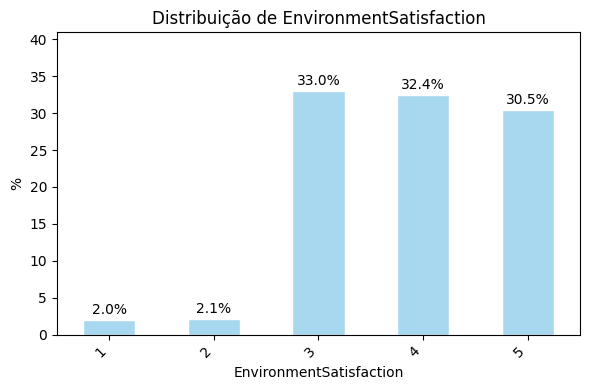

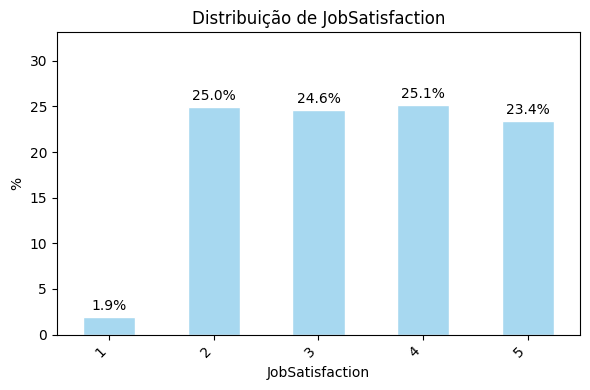

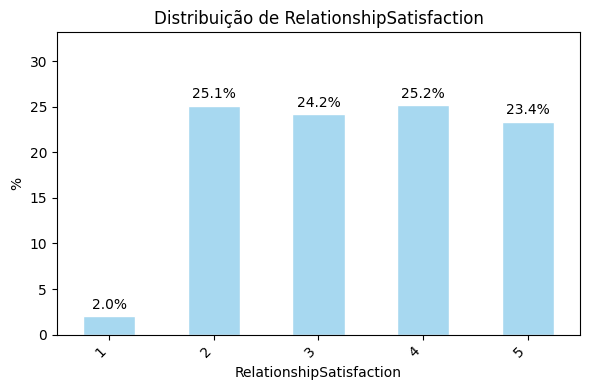

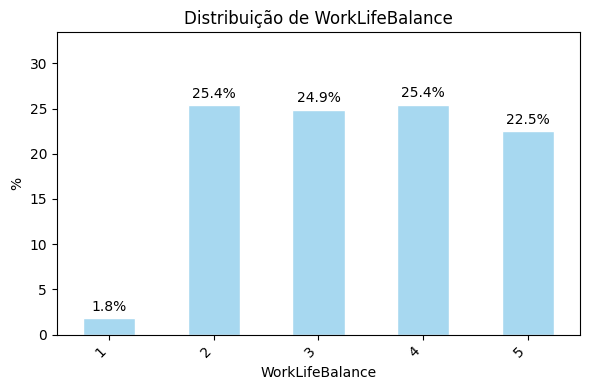

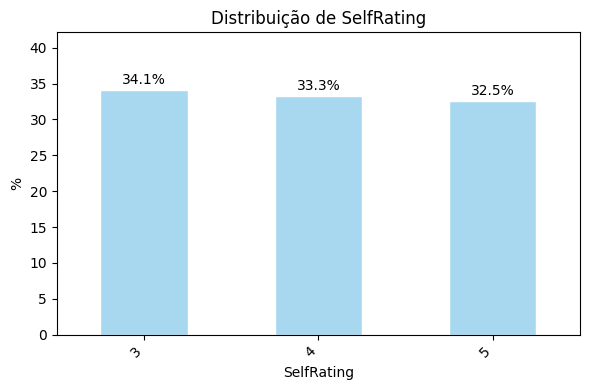

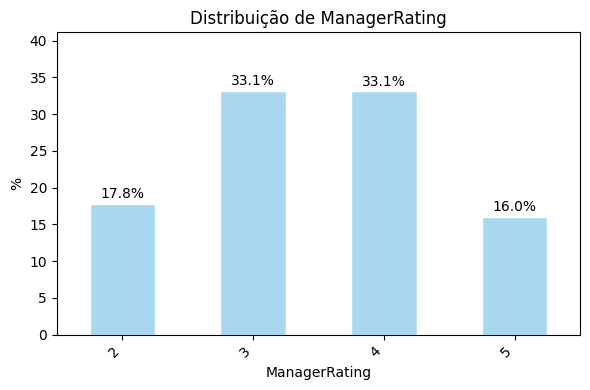

In [10]:
#ANALISE DOS DADOS QUALITATIVOS
import matplotlib.pyplot as plt

df = performance_rating
quali = ['EnvironmentSatisfaction','JobSatisfaction', 'RelationshipSatisfaction','WorkLifeBalance', 'SelfRating', 'ManagerRating' ]

def eda_qualitativos(df, coluna):
    freq = df[coluna].value_counts()
    freq.index = freq.index.astype(int)
    freq = freq.sort_index() / len(df) * 100
    return freq

for coluna in quali:

    analise = eda_qualitativos(df, coluna)

    plt.figure(figsize=(6,4))

    ax = analise.plot(
        kind='bar',
        color='#A7D8F0',
        edgecolor='white'
    )

    plt.title(f'Distribuição de {coluna}')

    plt.ylabel('%')

    plt.ylim(0, analise.max() + 8)

    for i, valor in enumerate(analise):

        plt.text(
            i,
            valor + 0.8,
            f'{valor:.1f}%',
            ha='center')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()

    plt.show()

    plt.close()


**Employee Review Base Atual**

Considera a base atual de funcionários e somente a última avaliação realizada

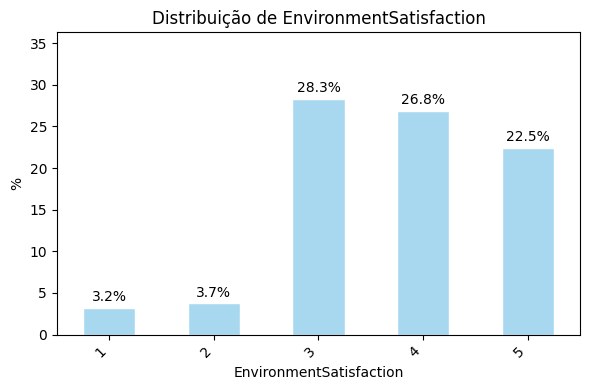

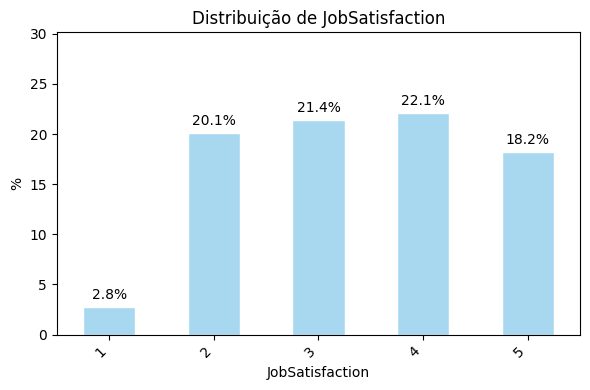

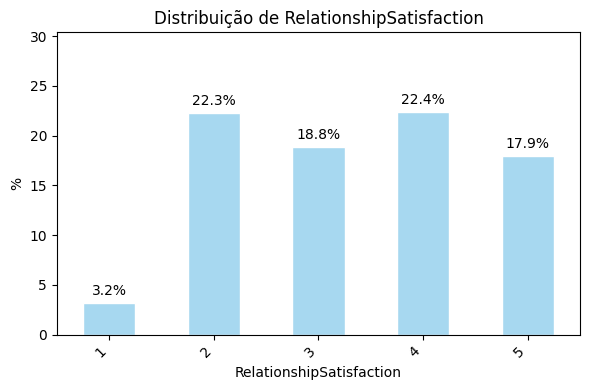

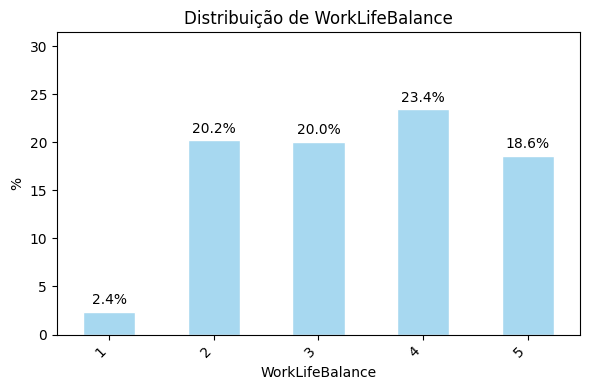

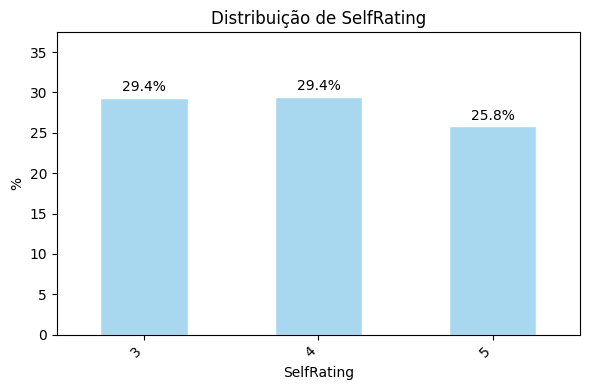

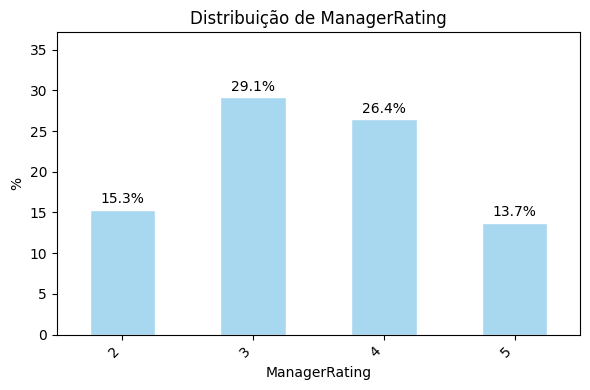

In [11]:
#ANALISE DOS DADOS QUALITATIVOS
import matplotlib.pyplot as plt

df = employee_review_base_atual
quali = ['EnvironmentSatisfaction','JobSatisfaction', 'RelationshipSatisfaction','WorkLifeBalance', 'SelfRating', 'ManagerRating' ]

for coluna in quali:

    analise = eda_qualitativos(df, coluna)

    plt.figure(figsize=(6,4))

    ax = analise.plot(
        kind='bar',
        color='#A7D8F0',
        edgecolor='white'
    )

    plt.title(f'Distribuição de {coluna}')

    plt.ylabel('%')

    plt.ylim(0, analise.max() + 8)

    for i, valor in enumerate(analise):

        plt.text(
            i,
            valor + 0.8,
            f'{valor:.1f}%',
            ha='center')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()

    plt.show()

    plt.close()


**Tabela Employee Review Base Atual**

Analisar os dados cadastrais da base atual

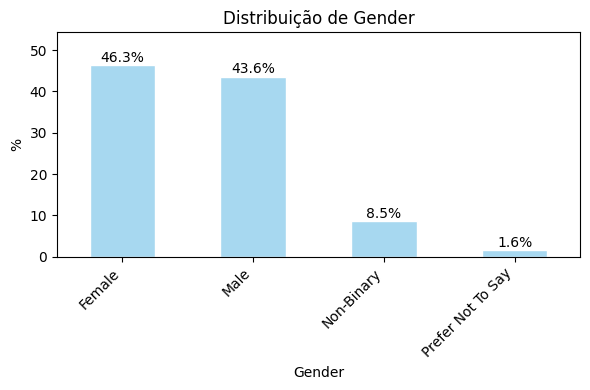

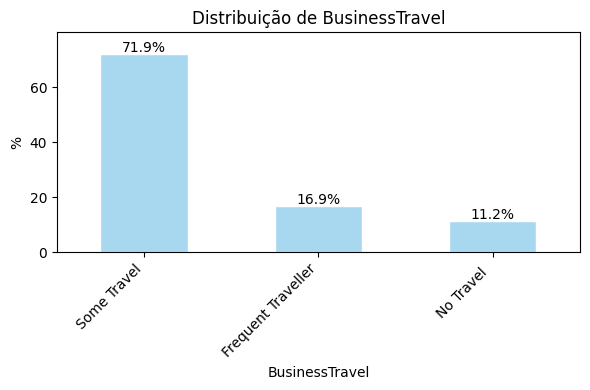

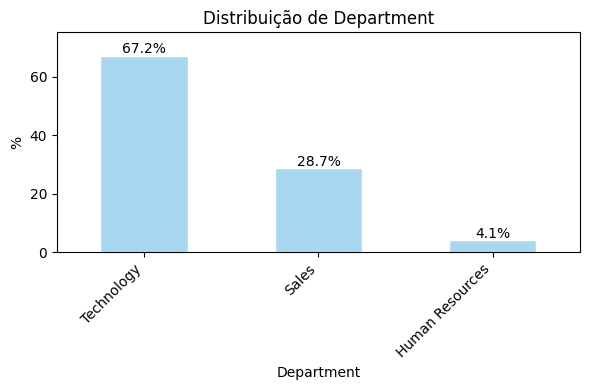

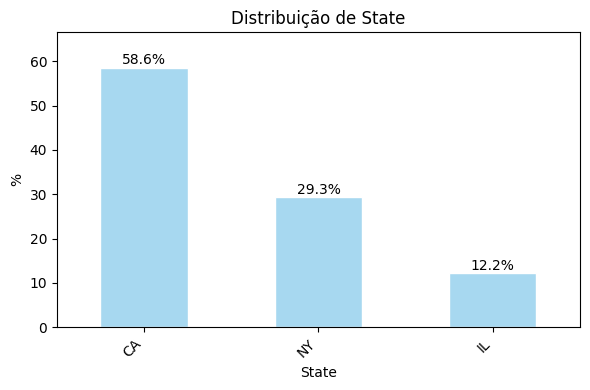

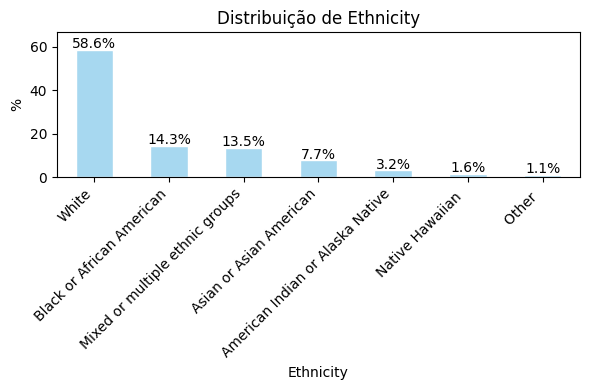

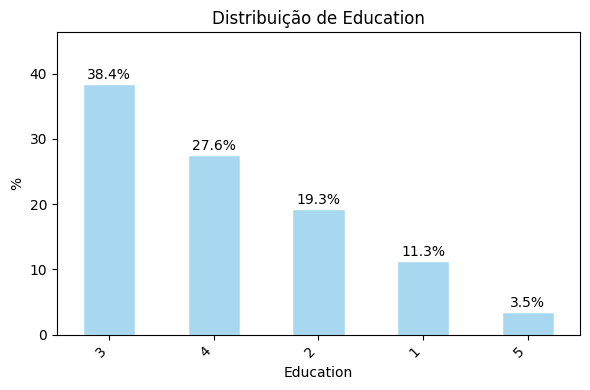

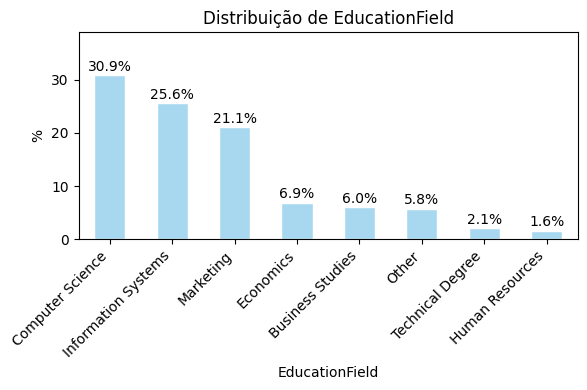

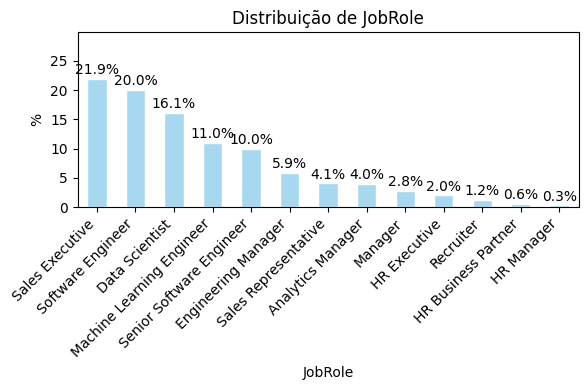

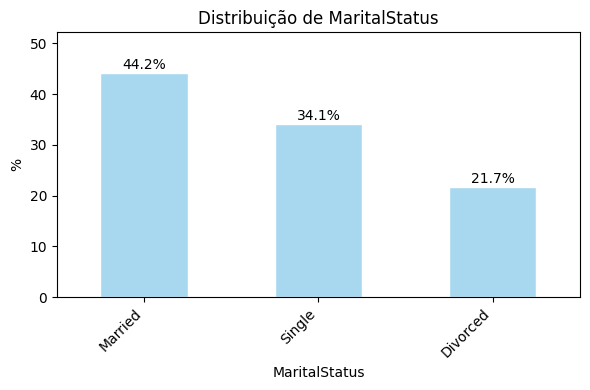

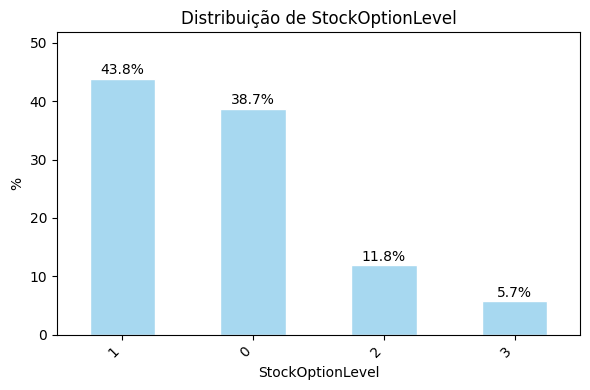

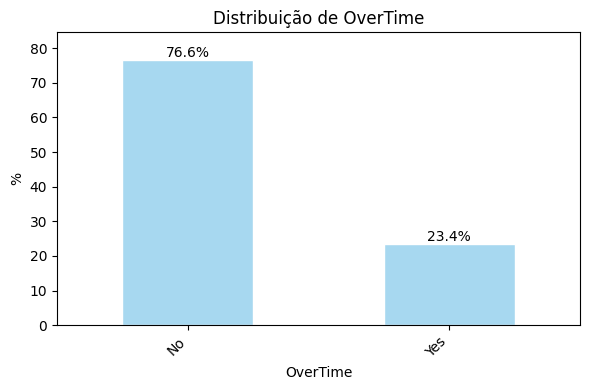

In [12]:
#ANALISE DOS DADOS QUALITATIVOS
import matplotlib.pyplot as plt

df = employee_review_base_atual
quali = ['Gender','BusinessTravel', 'Department','State', 'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus' ,'StockOptionLevel', 'OverTime']

def eda_qualitativos (df,coluna):
  freq = df[coluna].value_counts()/len(df)*100
  return freq

for coluna in quali:

    analise = eda_qualitativos(df, coluna)

    plt.figure(figsize=(6,4))

    ax = analise.plot(
        kind='bar',
        color='#A7D8F0',
        edgecolor='white'
    )

    plt.title(f'Distribuição de {coluna}')

    plt.ylabel('%')

    plt.ylim(0, analise.max() + 8)

    for i, valor in enumerate(analise):

        plt.text(
            i,
            valor + 0.8,
            f'{valor:.1f}%',
            ha='center')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()

    plt.show()

    plt.close()

**Tabela Employee Review**

Analisar os dados cadastrais de toda a base, incluindo funcionarios que ja sairam

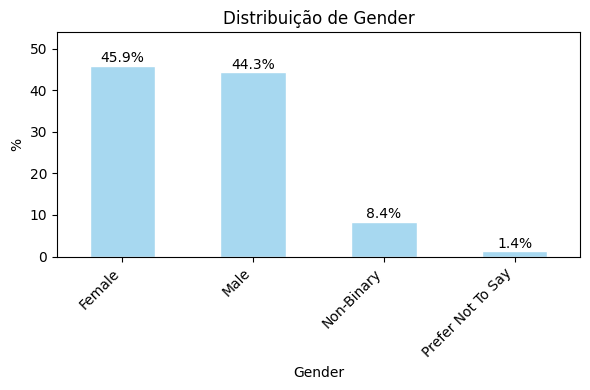

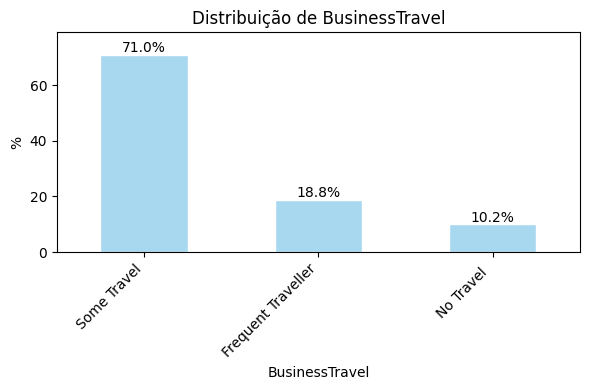

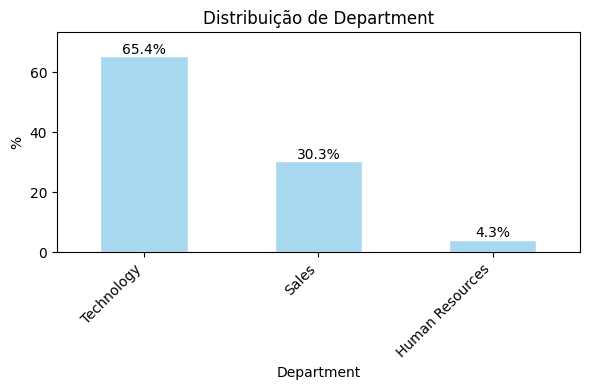

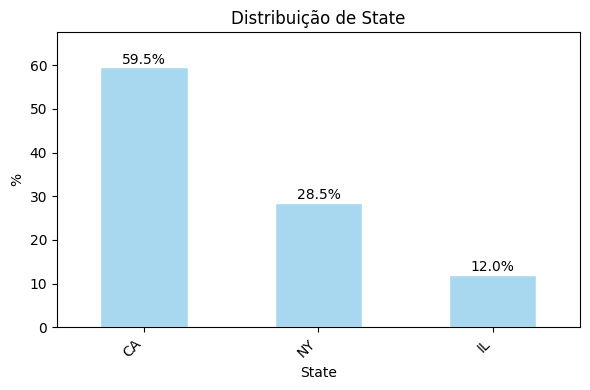

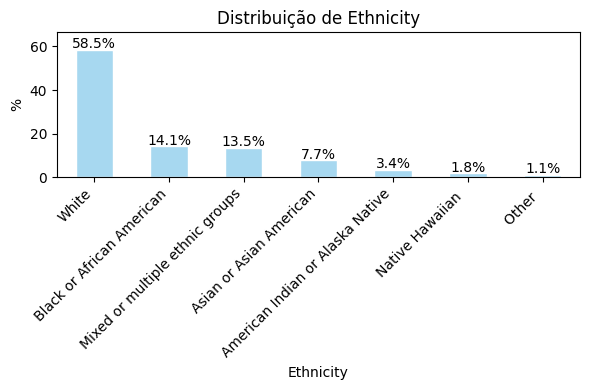

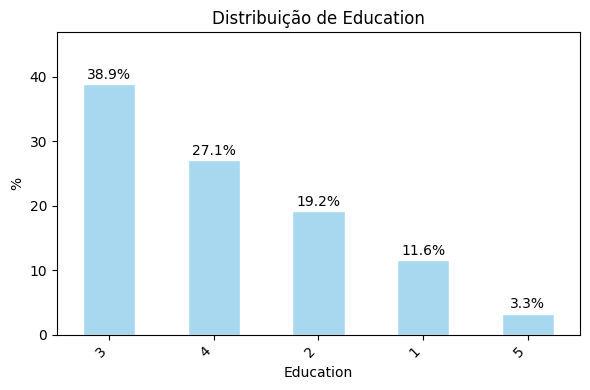

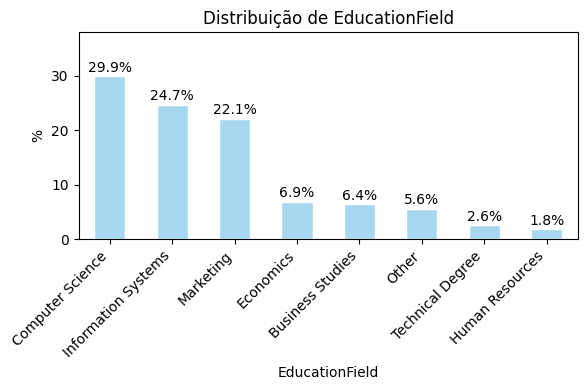

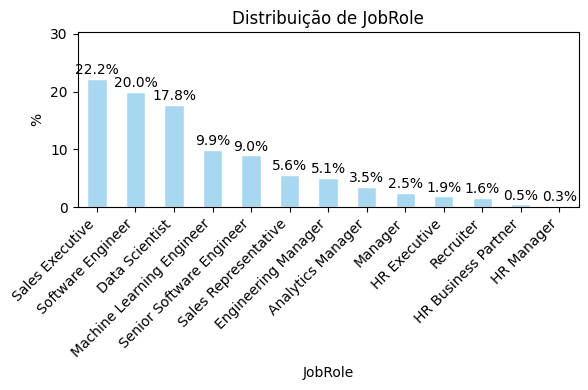

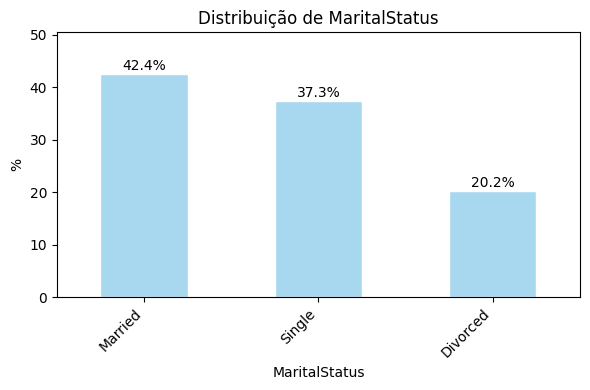

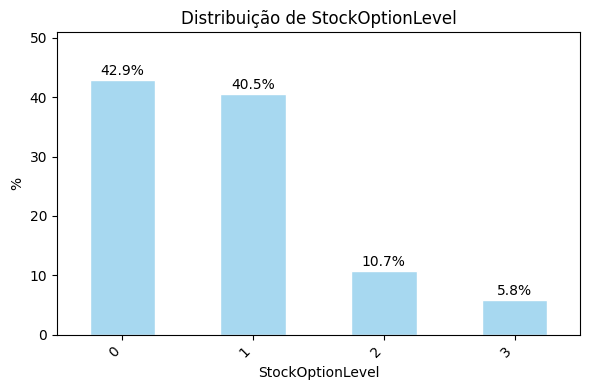

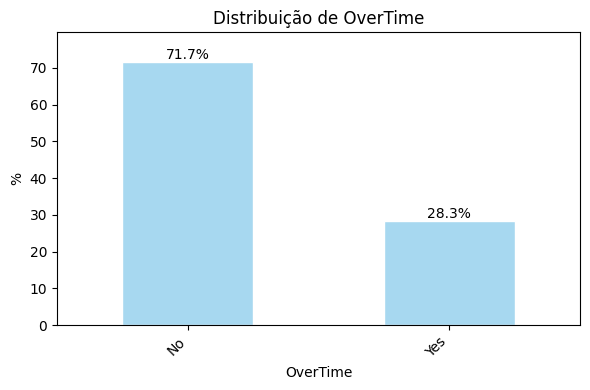

In [13]:
#ANALISE DOS DADOS QUALITATIVOS
import matplotlib.pyplot as plt

df = employee_review
quali = ['Gender','BusinessTravel', 'Department','State', 'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus' ,'StockOptionLevel', 'OverTime']

def eda_qualitativos (df,coluna):
  freq = df[coluna].value_counts()/len(df)*100
  return freq

for coluna in quali:

    analise = eda_qualitativos(df, coluna)

    plt.figure(figsize=(6,4))

    ax = analise.plot(
        kind='bar',
        color='#A7D8F0',
        edgecolor='white'
    )

    plt.title(f'Distribuição de {coluna}')

    plt.ylabel('%')

    plt.ylim(0, analise.max() + 8)

    for i, valor in enumerate(analise):

        plt.text(
            i,
            valor + 0.8,
            f'{valor:.1f}%',
            ha='center')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()

    plt.show()

    plt.close()

**Tabela Employee Base total**

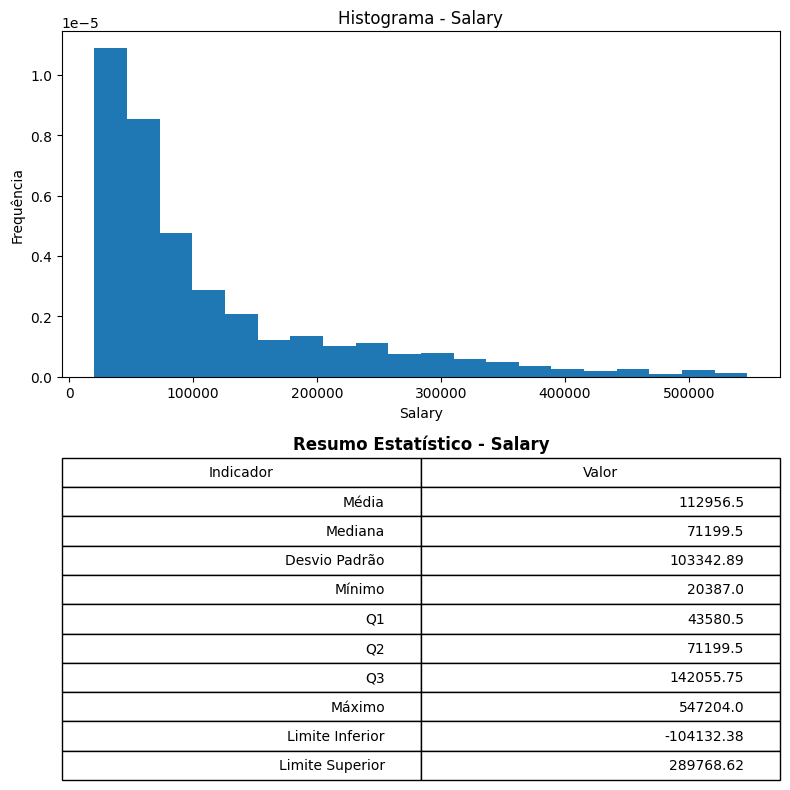

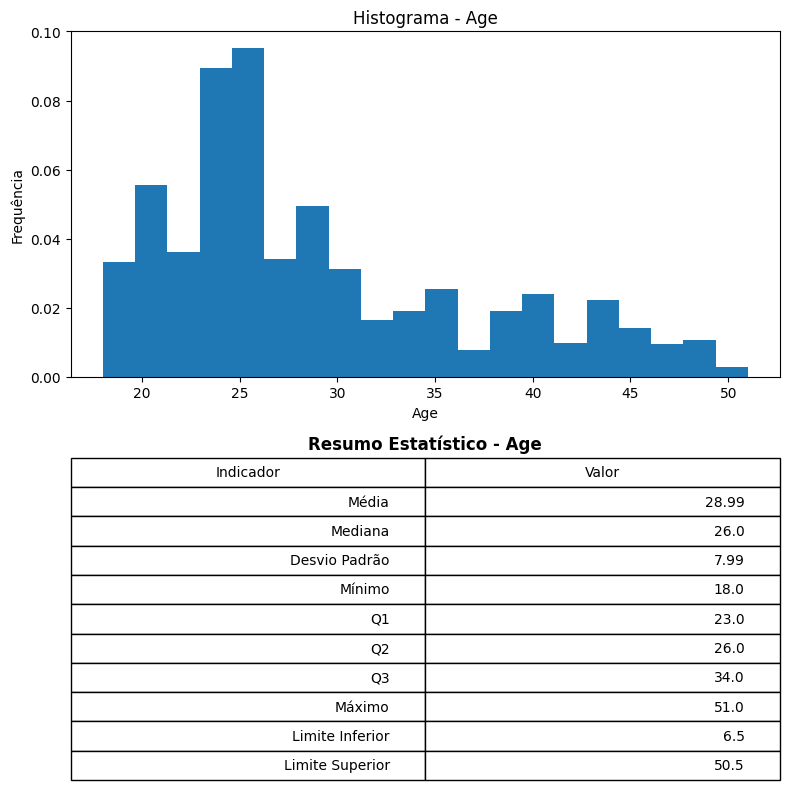

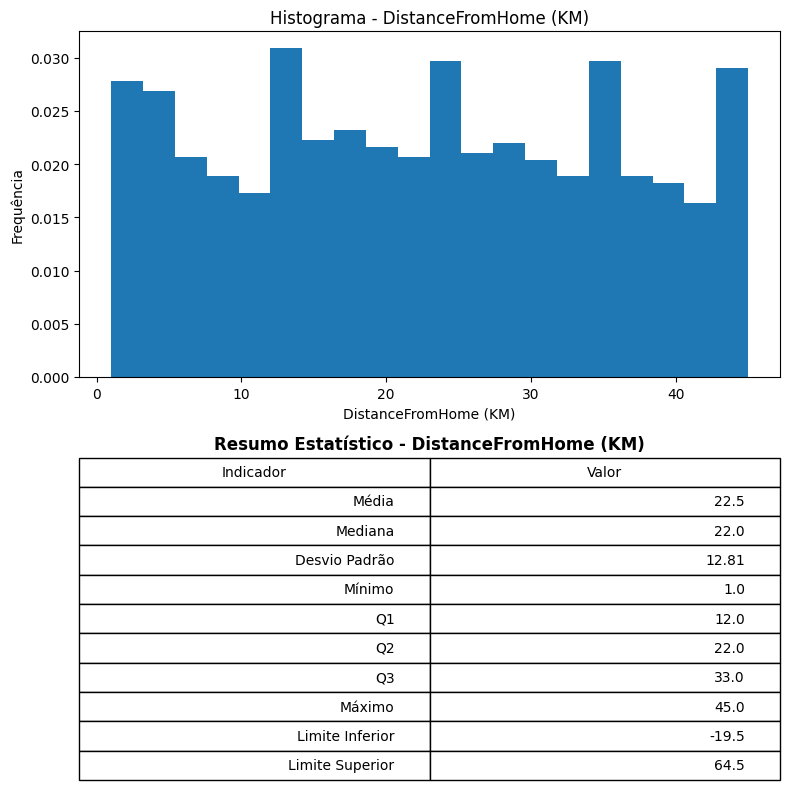

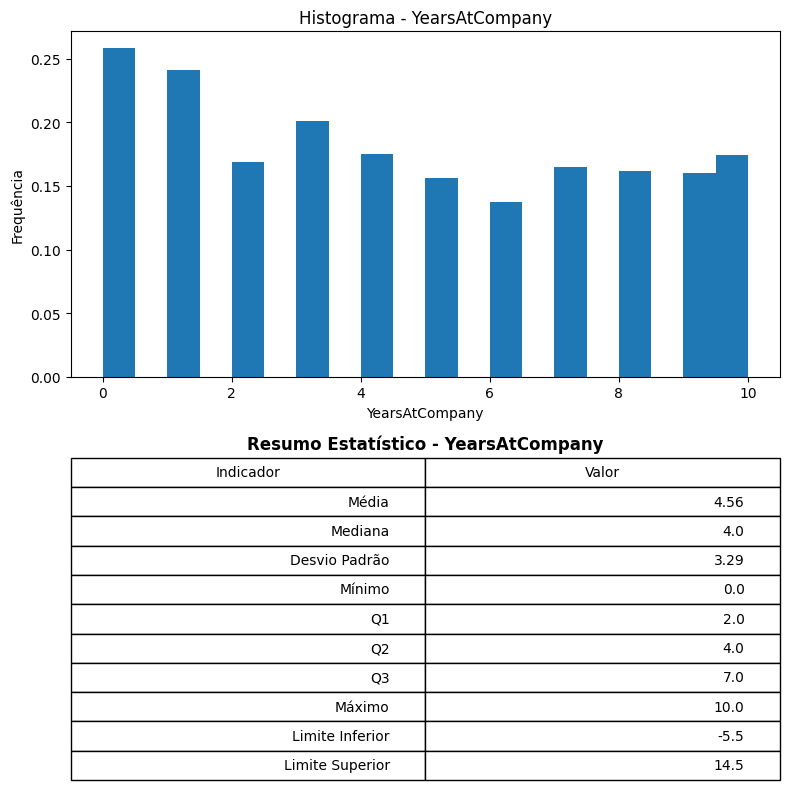

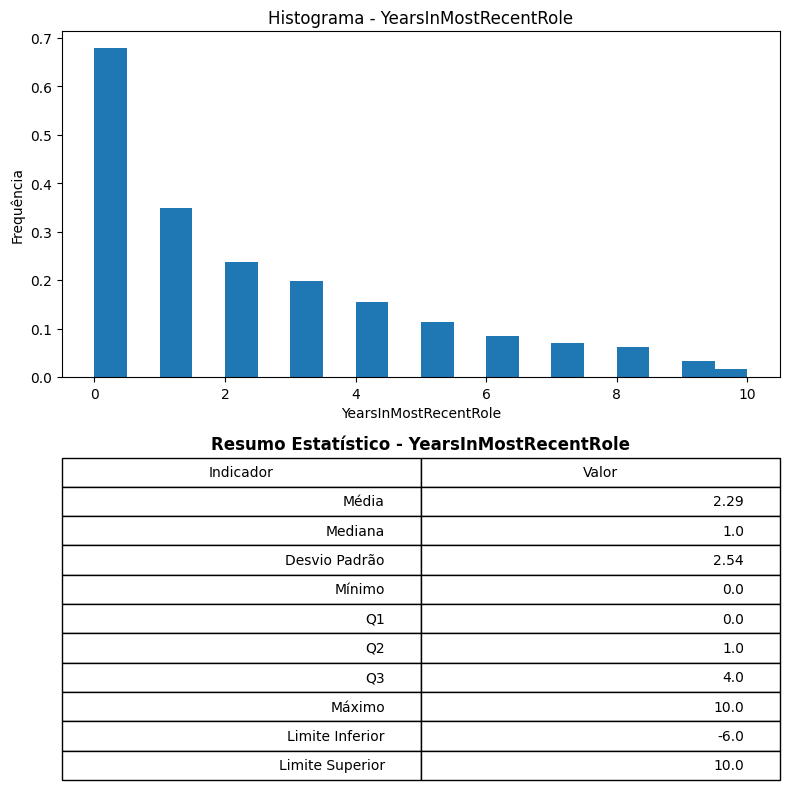

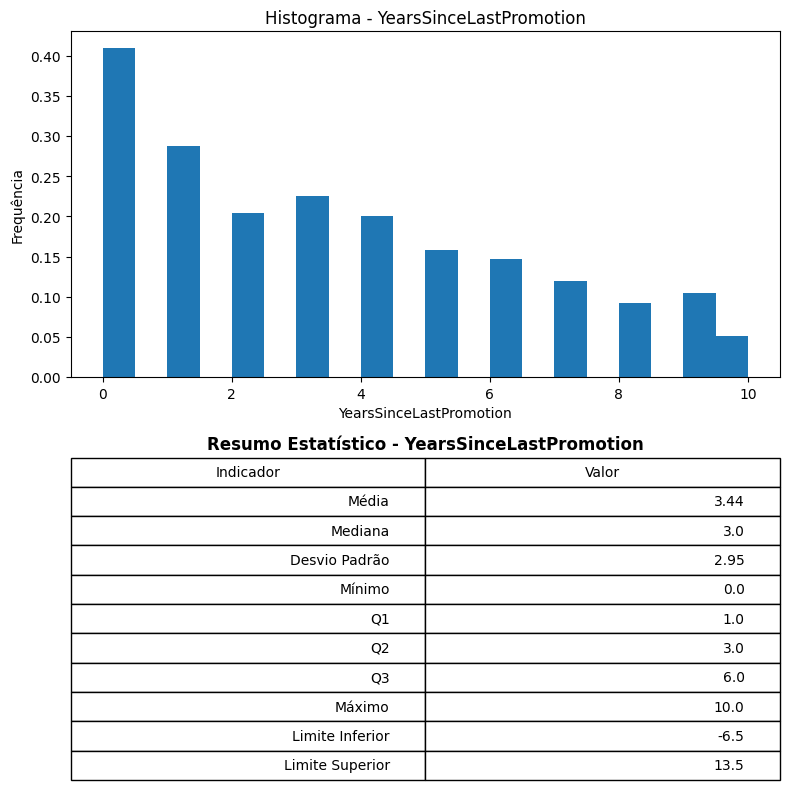

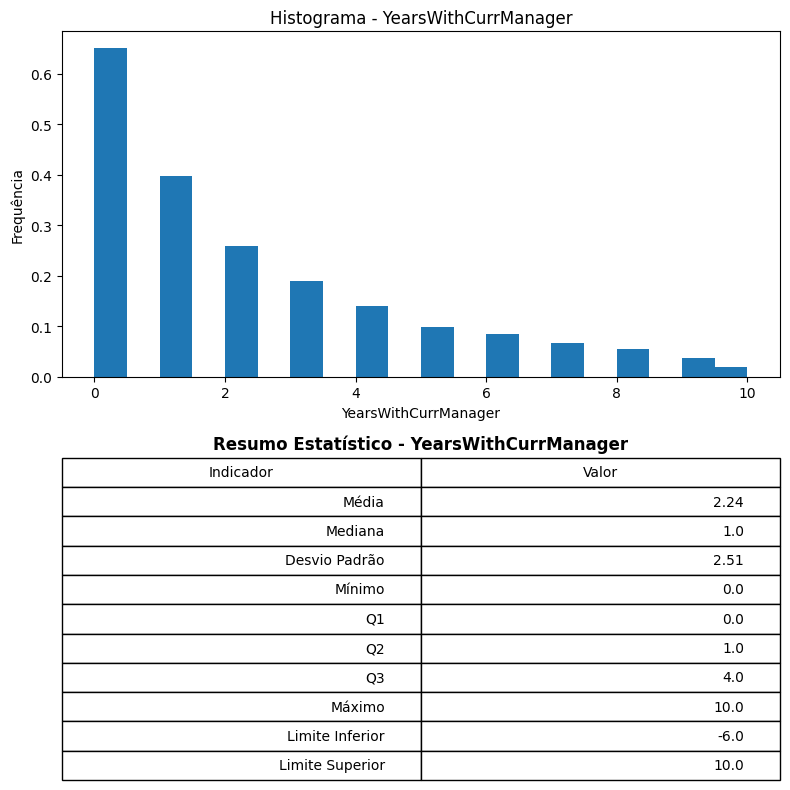

In [14]:
#DADOS QUANTITATIVOS

df = employee_review
quanti = ['Salary','Age', 'DistanceFromHome (KM)', 'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']

def eda_quanti(df, coluna):

    media = df[coluna].mean()
    mediana = df[coluna].median()
    desvio = df[coluna].std()

    minimo = df[coluna].min()
    maximo = df[coluna].max()

    q1 = df[coluna].quantile(0.25)
    q2 = df[coluna].quantile(0.5)
    q3 = df[coluna].quantile(0.75)

    # IQR
    iqr = q3 - q1

    # limites
    limite_inferior = q1 - (1.5 * iqr)
    limite_superior = q3 + (1.5 * iqr)

    # dicionário com resultados
    resumo = {
        'Média': media,
        'Mediana': mediana,
        'Desvio Padrão': desvio,
        'Mínimo': minimo,
        'Q1': q1,
        'Q2': q2,
        'Q3': q3,
        'Máximo': maximo,
        'Limite Inferior': limite_inferior,
        'Limite Superior': limite_superior
    }

    return resumo

for coluna in quanti:

  resumo = eda_quanti(df, coluna)

  fig, ax = plt.subplots(
      2, 1,
      figsize=(8,8),
      gridspec_kw={'height_ratios': [2,1.8]}
  )


  ax[0].hist(
      df[coluna].dropna(),
      bins=20,
      density = True
  )

  ax[0].set_title(f'Histograma - {coluna}')
  ax[0].set_xlabel(coluna)
  ax[0].set_ylabel('Frequência')

  ax[0].ticklabel_format(style='plain', axis='x')


  tabela_resumo = pd.DataFrame(
      resumo.items(),
      columns=['Indicador', 'Valor']
  )

  tabela_resumo['Valor'] = tabela_resumo['Valor'].round(2)

  ax[1].axis('off')

  ax[1].set_title(
      f'Resumo Estatístico - {coluna}',
      fontsize=12,
      fontweight='bold',
      pad=10
  )

  tabela = ax[1].table(
      cellText=tabela_resumo.values,
      colLabels=tabela_resumo.columns,
      loc='center'
  )

  tabela.auto_set_font_size(False)
  tabela.set_fontsize(10)
  tabela.scale(1, 1.5)


  plt.tight_layout()

  plt.show()

  plt.close()

**Tabela Employee Base Atual**

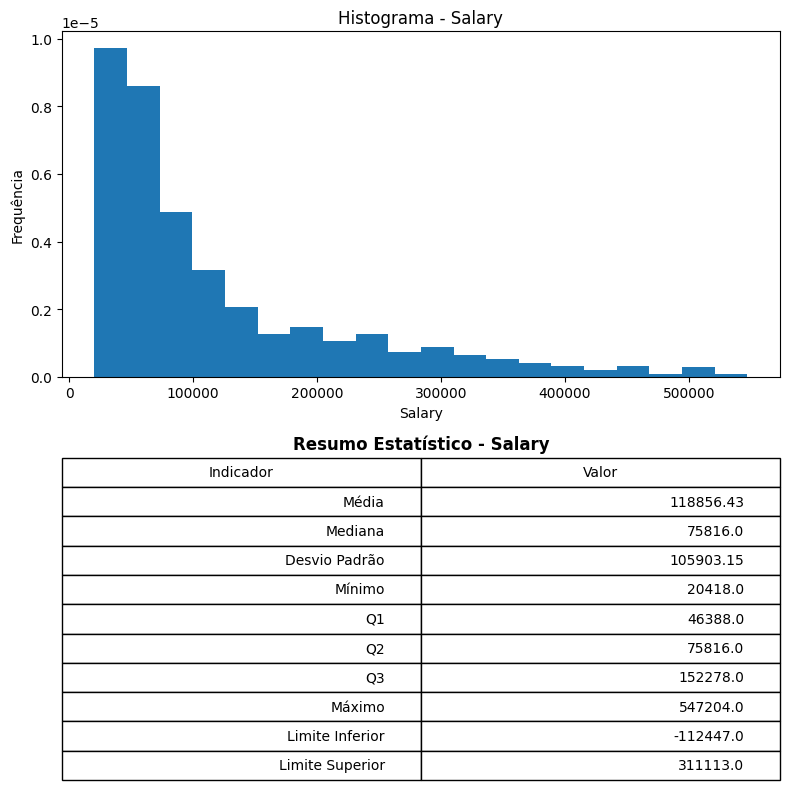

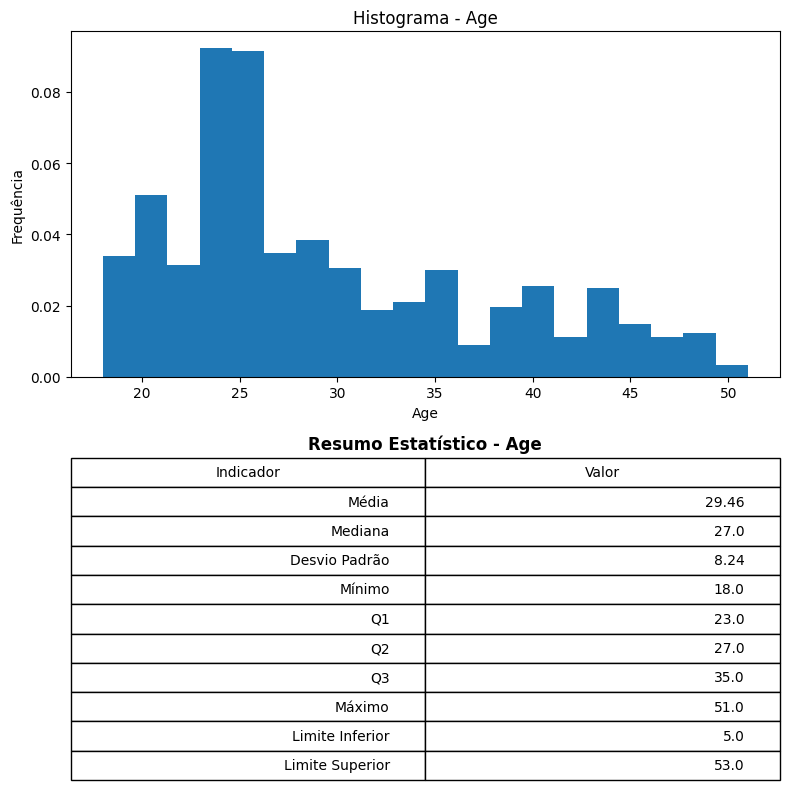

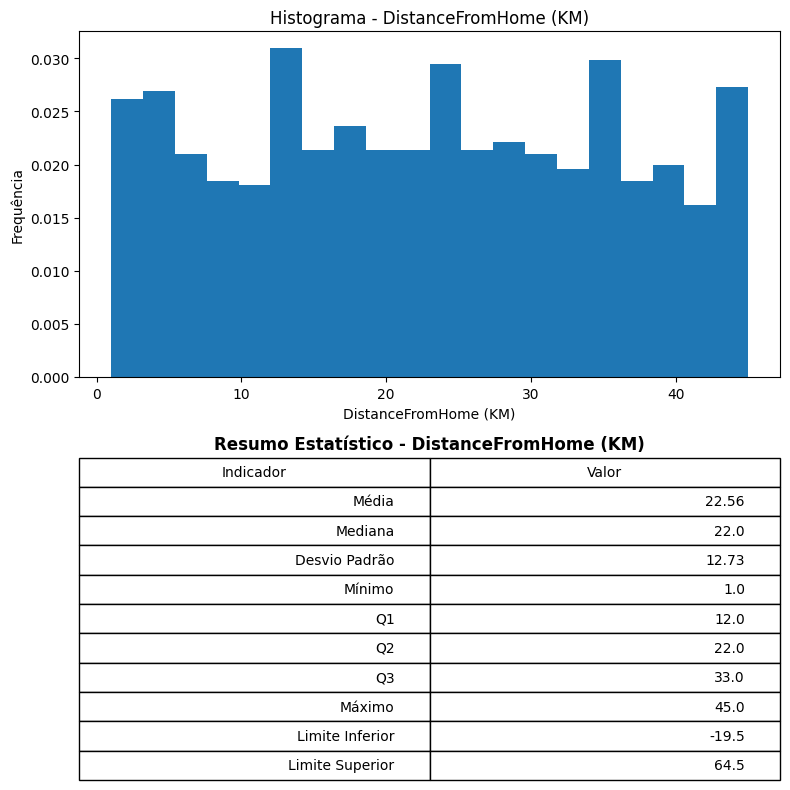

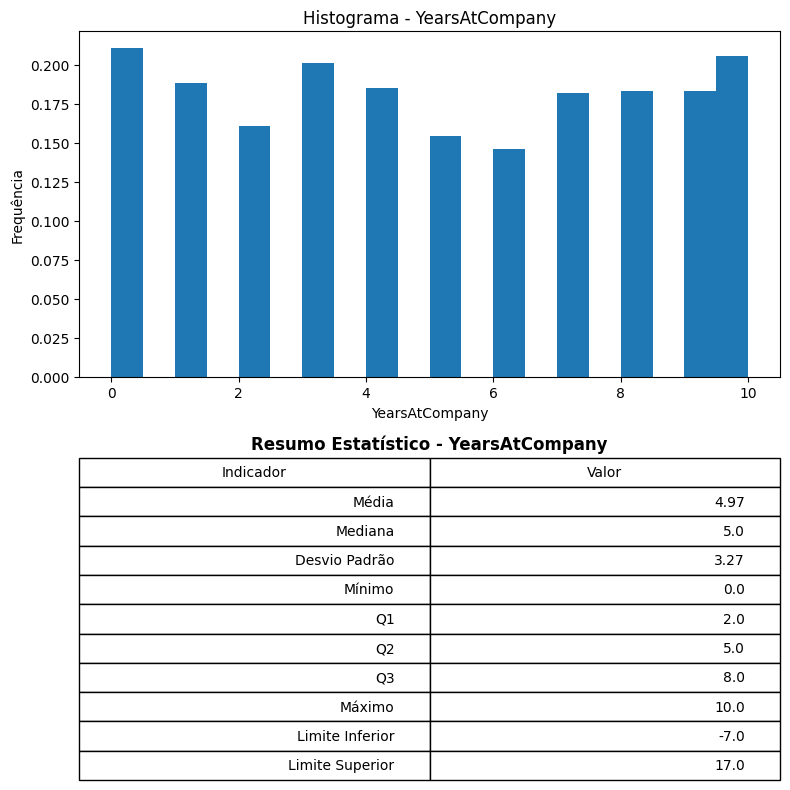

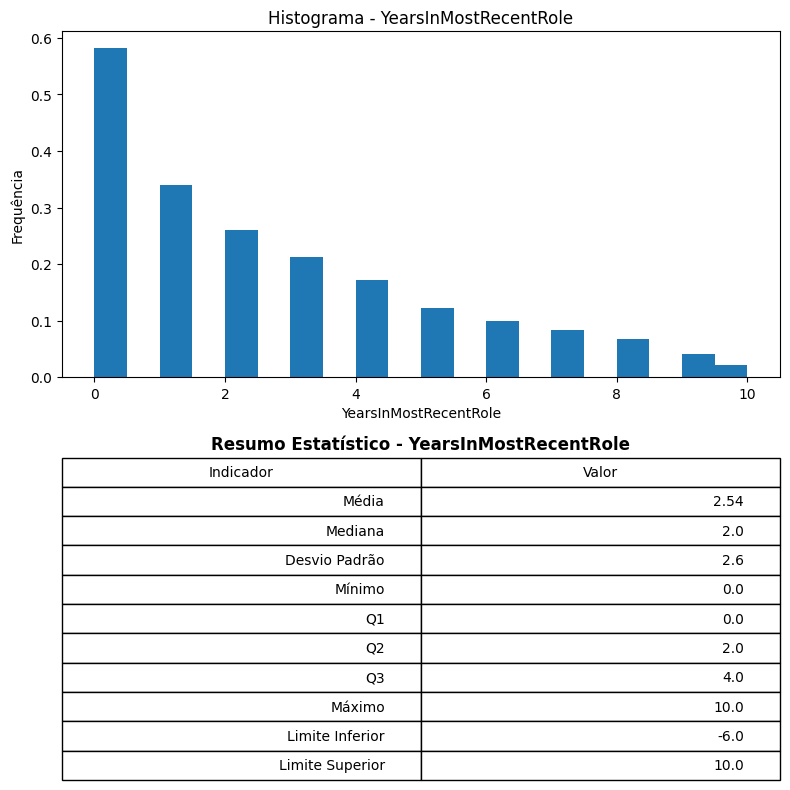

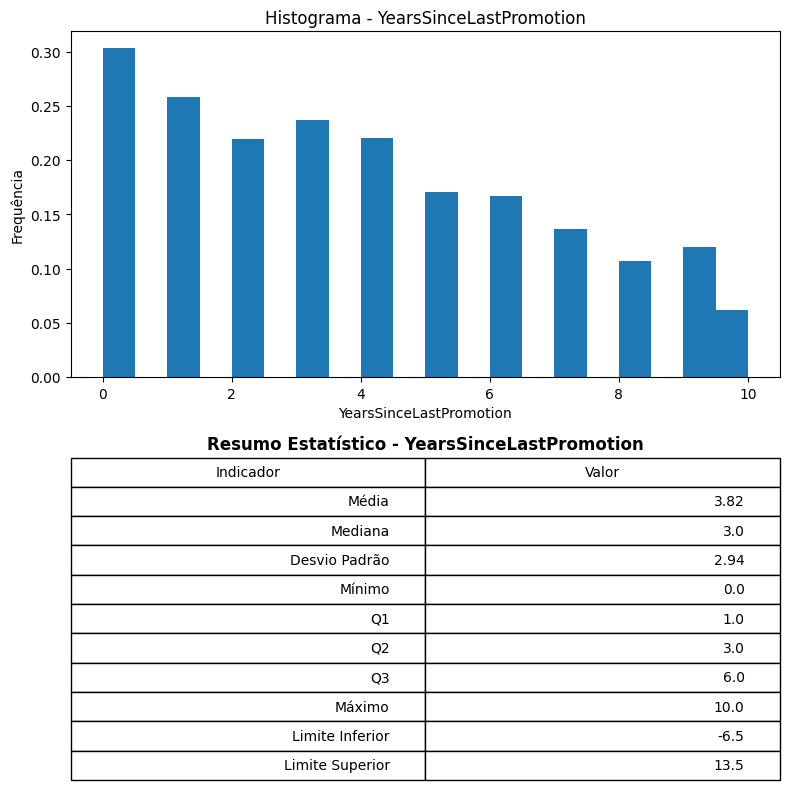

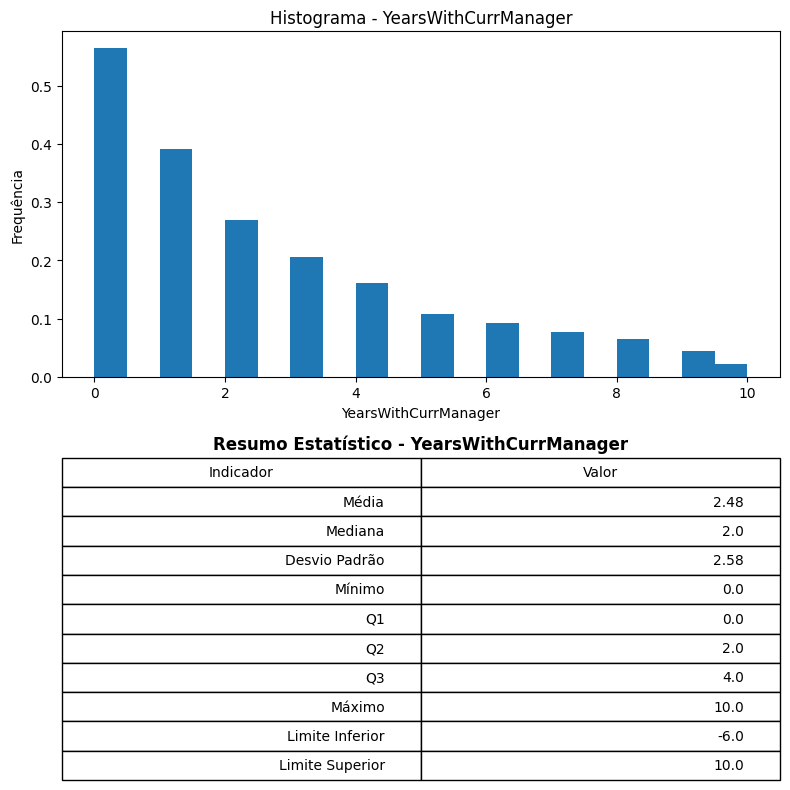

In [15]:
#DADOS QUANTITATIVOS

df = employee_review_base_atual
quanti = ['Salary', 'Age', 'DistanceFromHome (KM)', 'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion','YearsWithCurrManager']

for coluna in quanti:

  resumo = eda_quanti(df, coluna)

  fig, ax = plt.subplots(
      2, 1,
      figsize=(8,8),
      gridspec_kw={'height_ratios': [2,1.8]}
  )


  ax[0].hist(
      df[coluna].dropna(),
      bins=20,
      density = True
  )

  ax[0].set_title(f'Histograma - {coluna}')
  ax[0].set_xlabel(coluna)
  ax[0].set_ylabel('Frequência')

  ax[0].ticklabel_format(style='plain', axis='x')


  tabela_resumo = pd.DataFrame(
      resumo.items(),
      columns=['Indicador', 'Valor']
  )

  tabela_resumo['Valor'] = tabela_resumo['Valor'].round(2)

  ax[1].axis('off')

  ax[1].set_title(
      f'Resumo Estatístico - {coluna}',
      fontsize=12,
      fontweight='bold',
      pad=10
  )

  tabela = ax[1].table(
      cellText=tabela_resumo.values,
      colLabels=tabela_resumo.columns,
      loc='center'
  )

  tabela.auto_set_font_size(False)
  tabela.set_fontsize(10)
  tabela.scale(1, 1.5)


  plt.tight_layout()

  plt.show()

  plt.close()

# **EDA Bivariada**

# **Salário**

In [16]:
print(employee_review_base_atual.columns)


Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceID', 'ReviewDate',
       'EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating'],
      dtype='object')


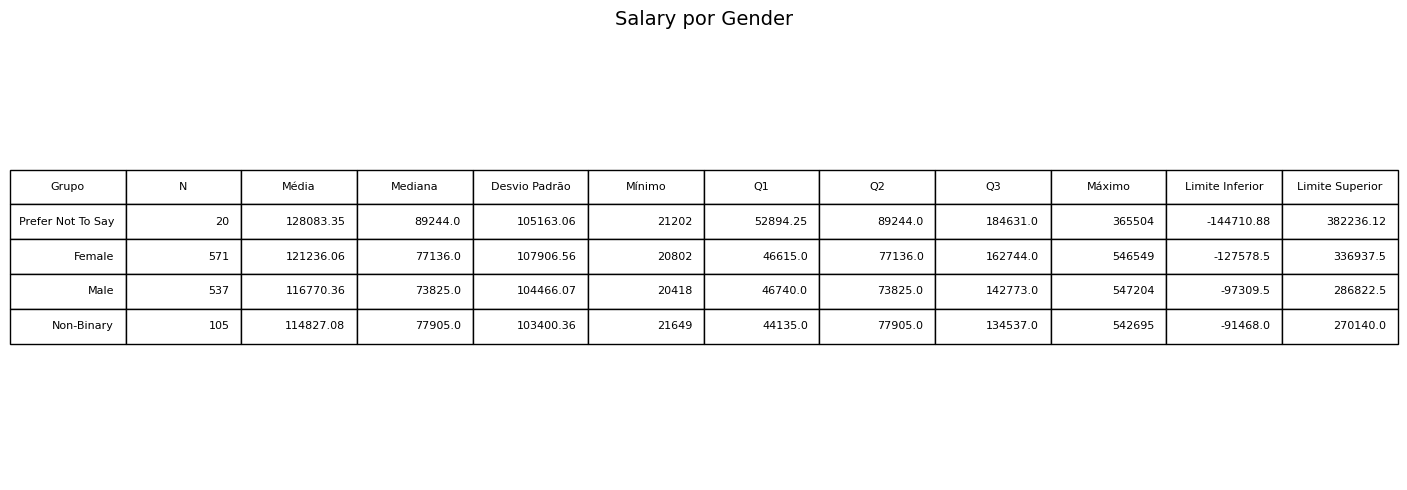

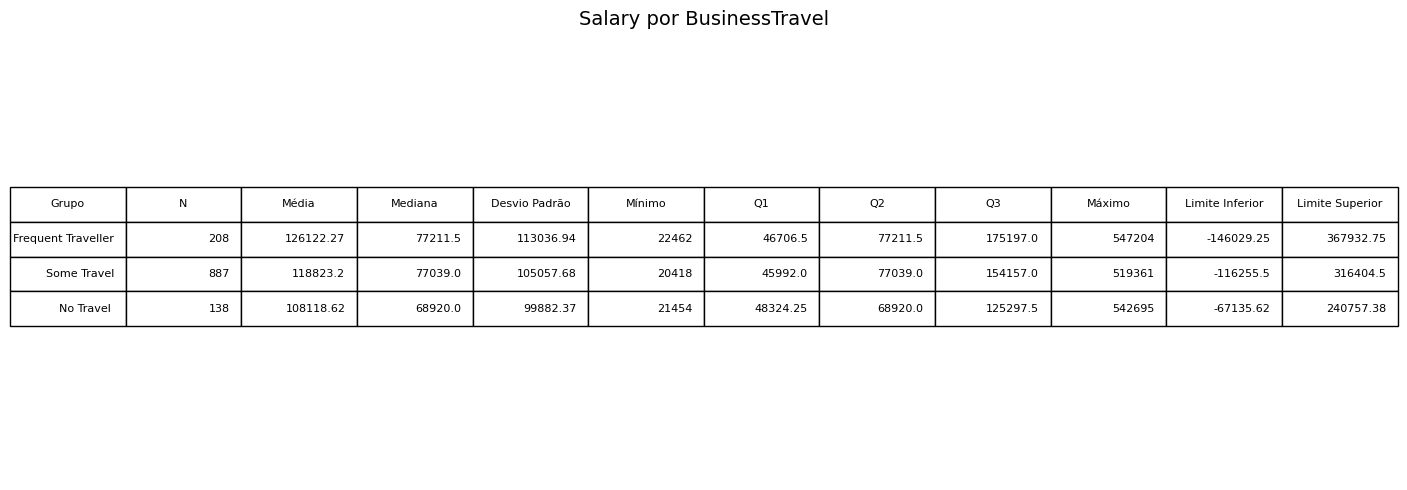

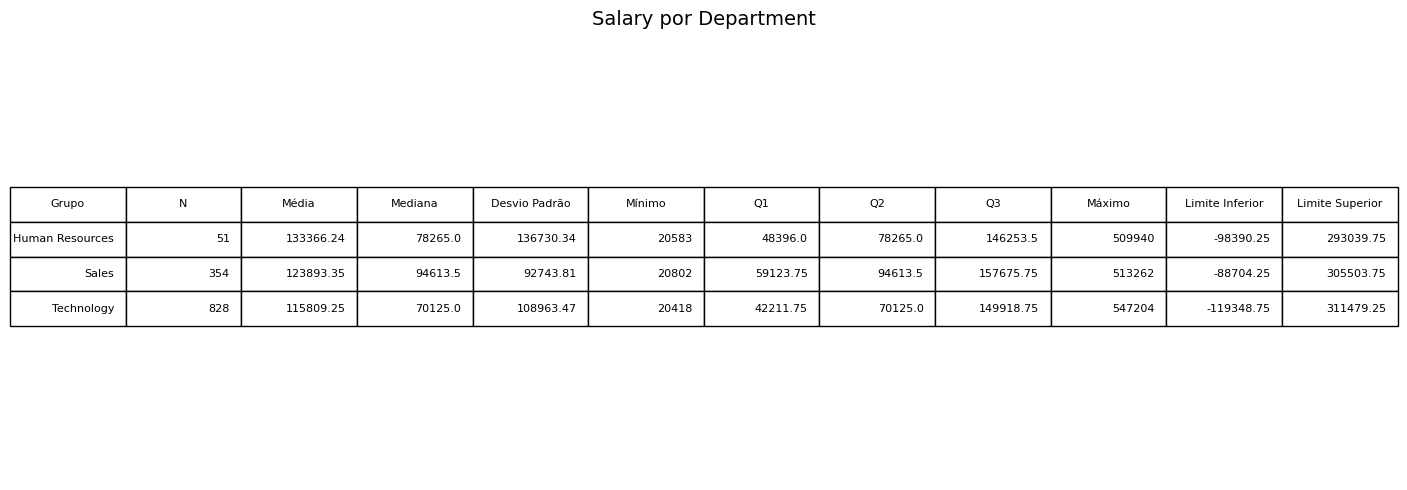

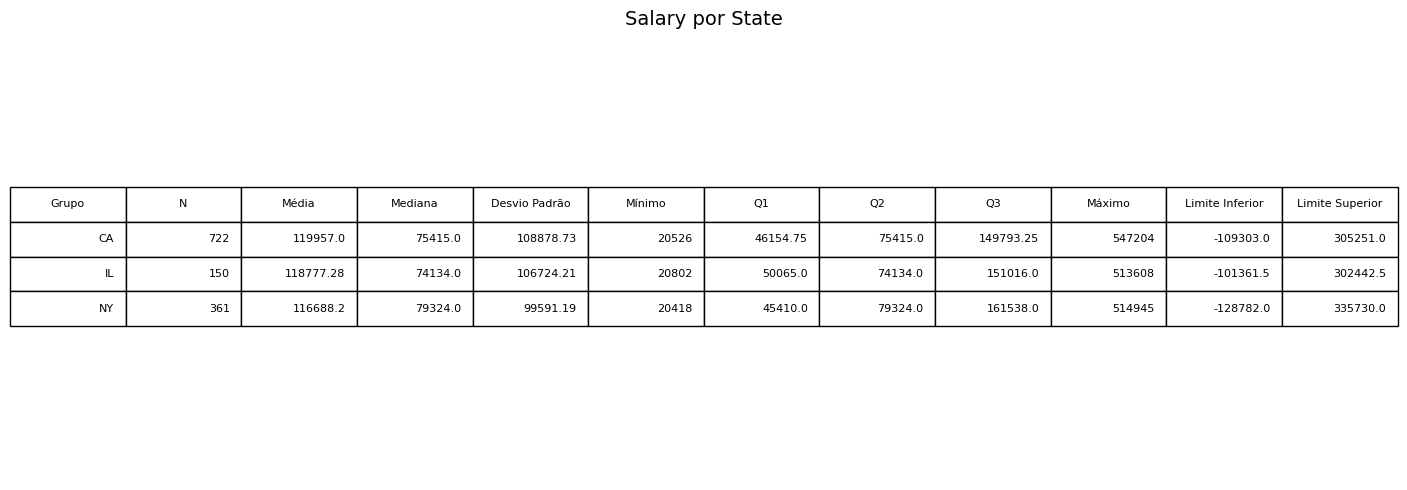

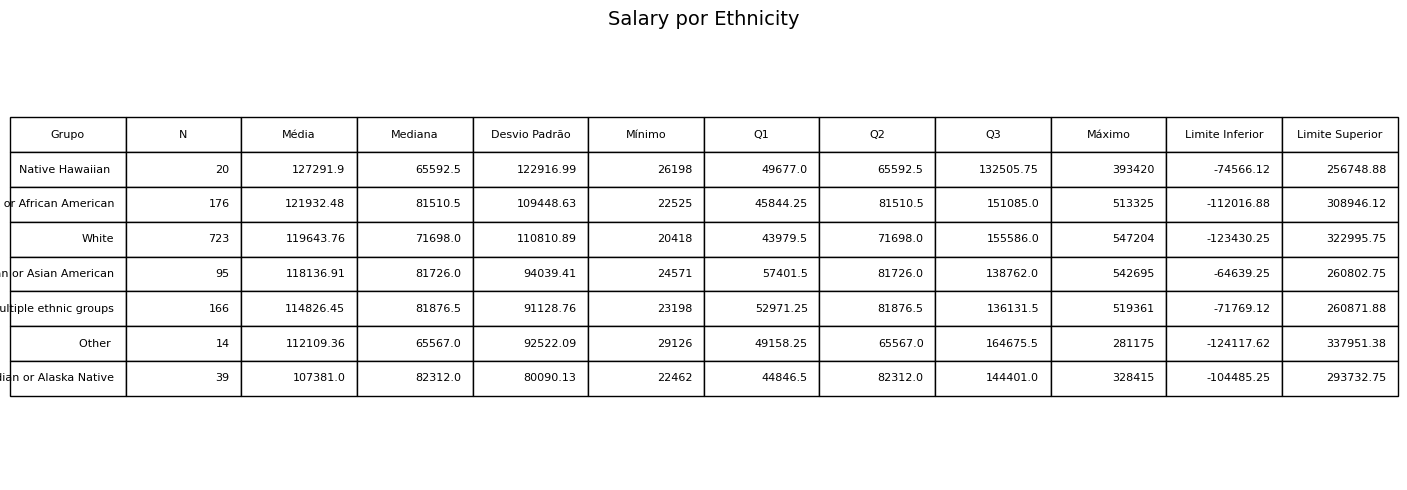

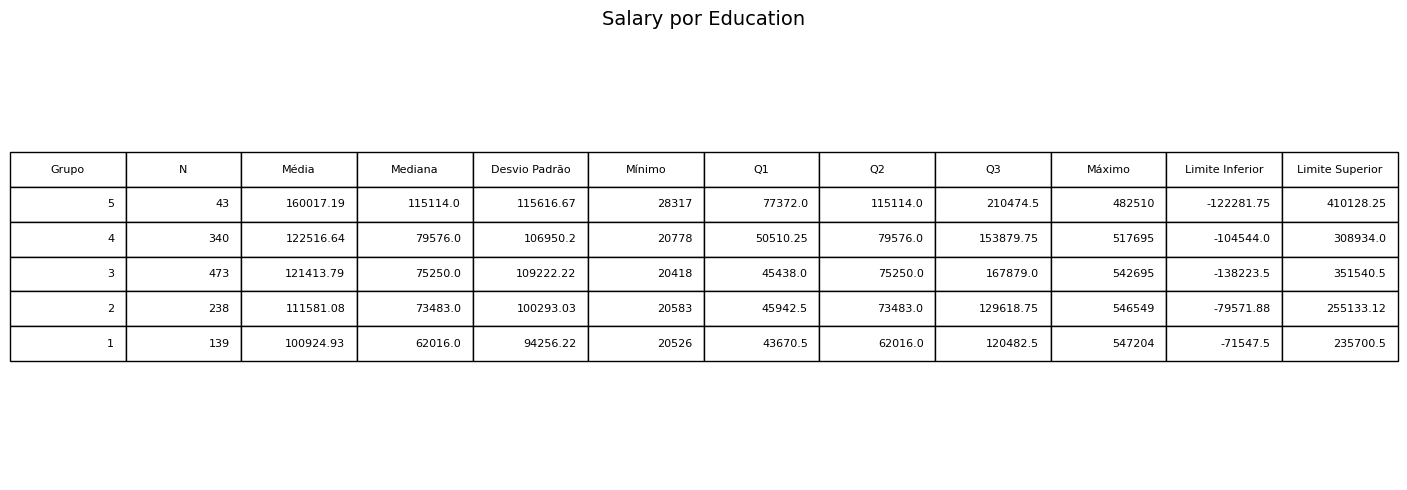

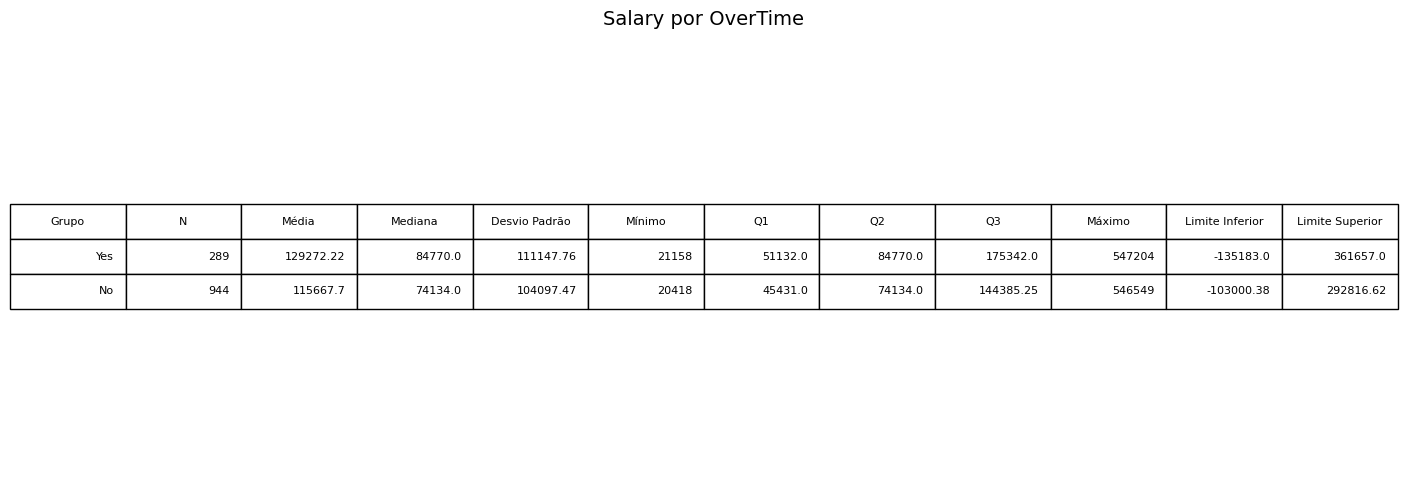

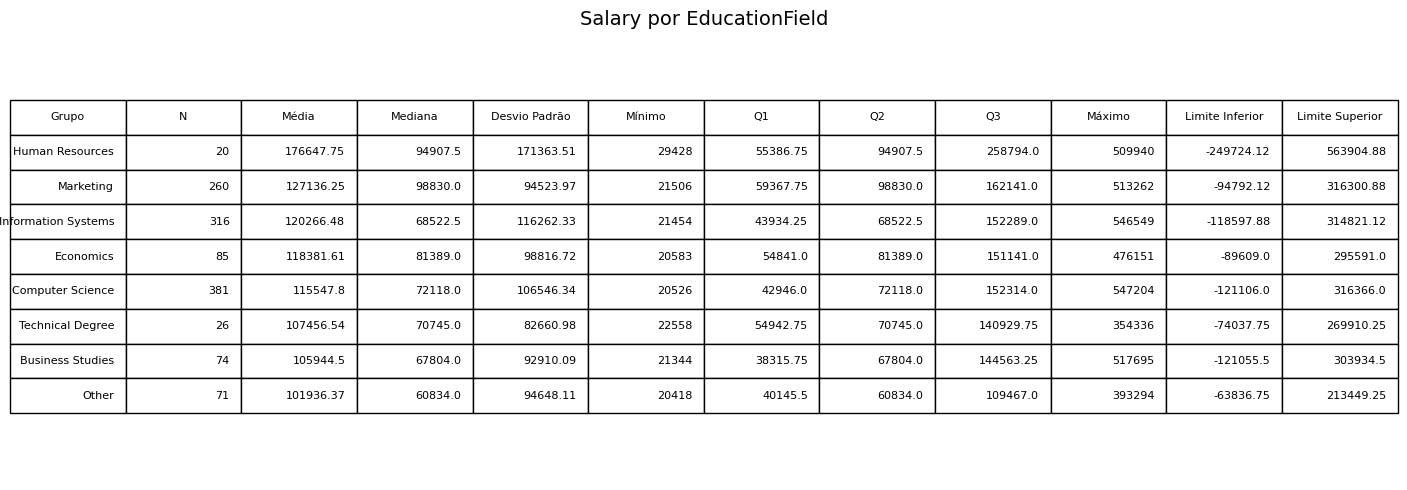

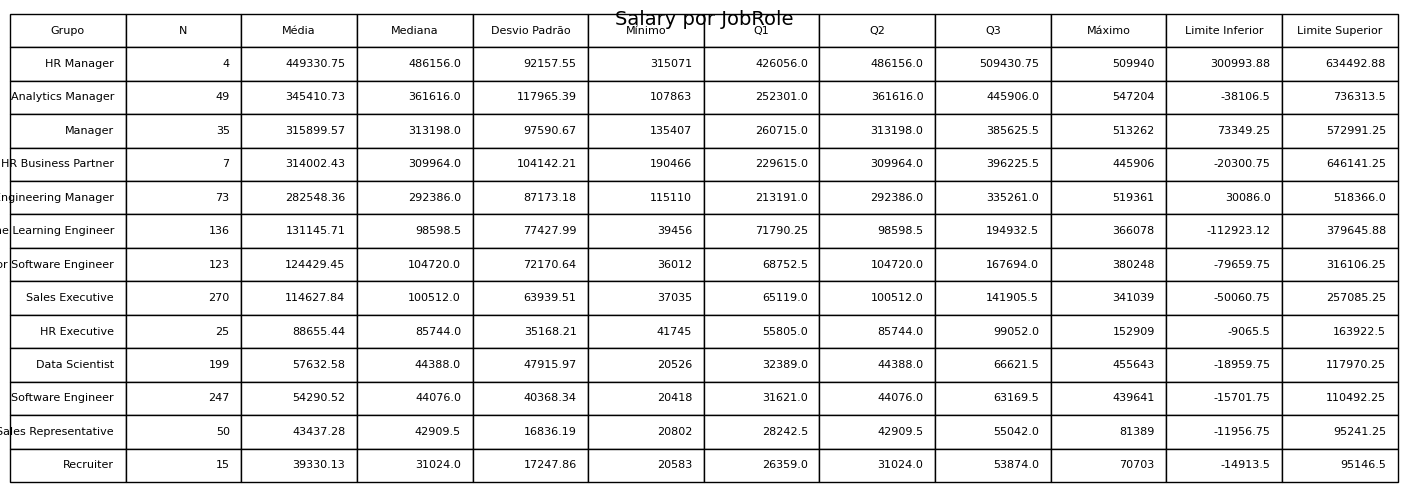

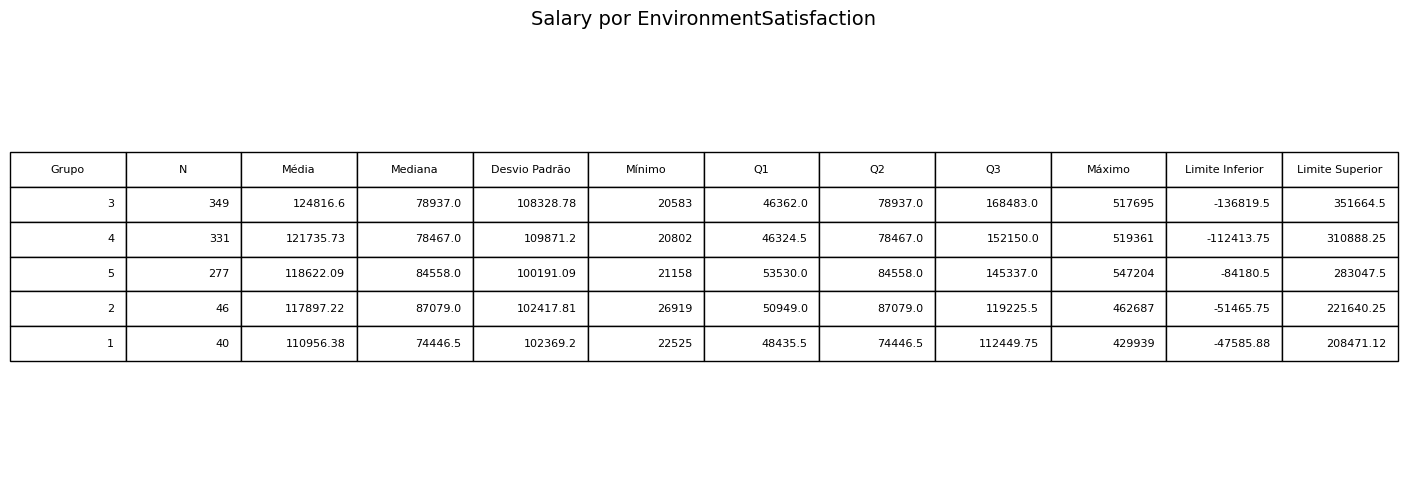

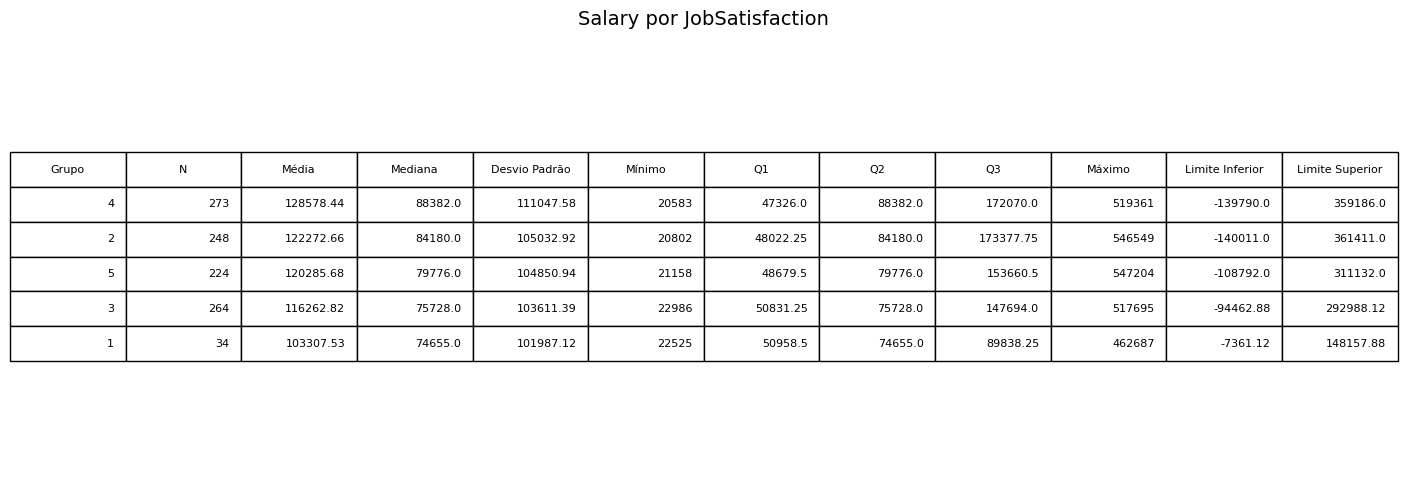

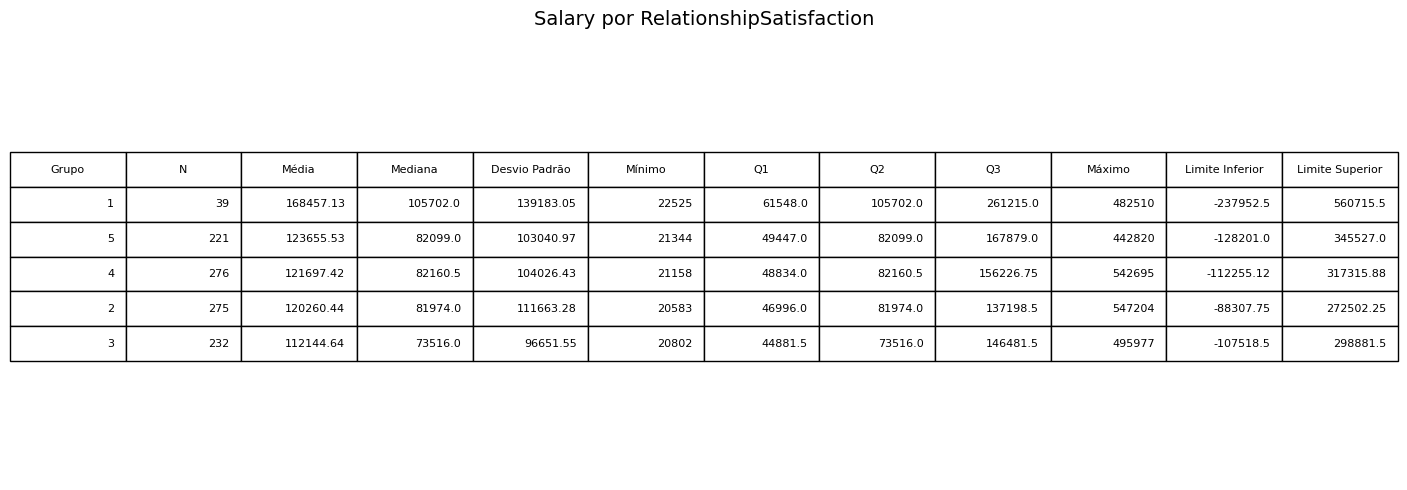

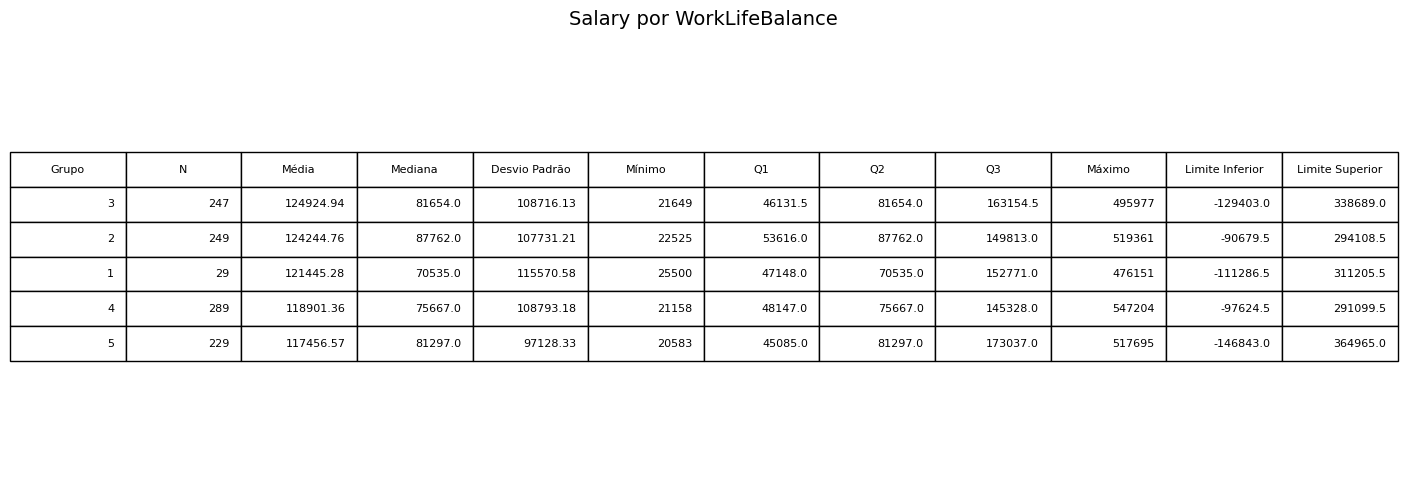

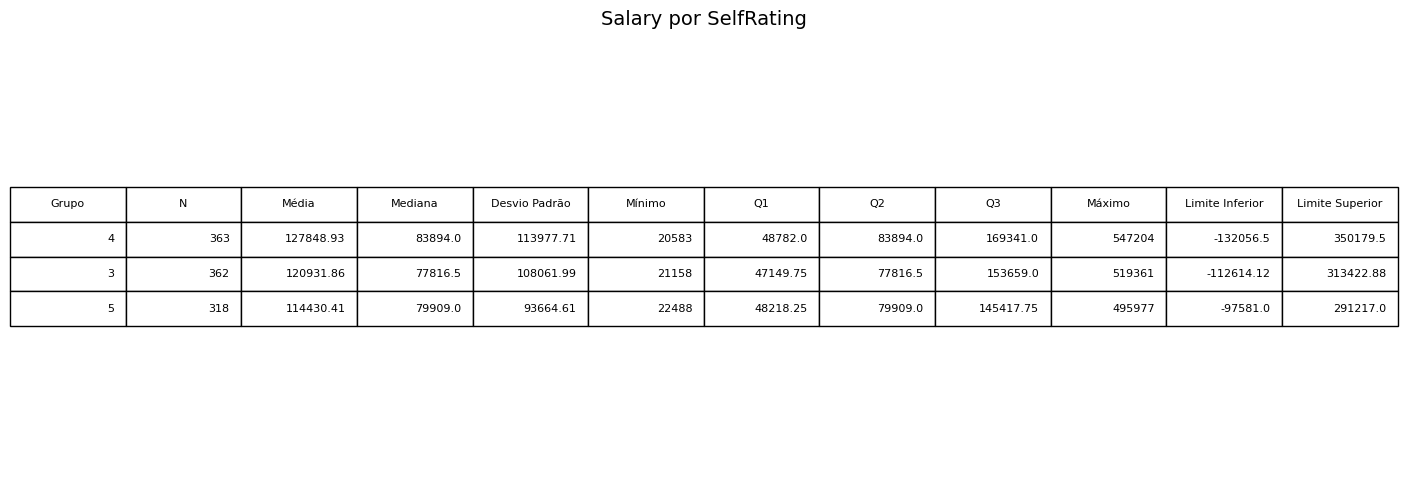

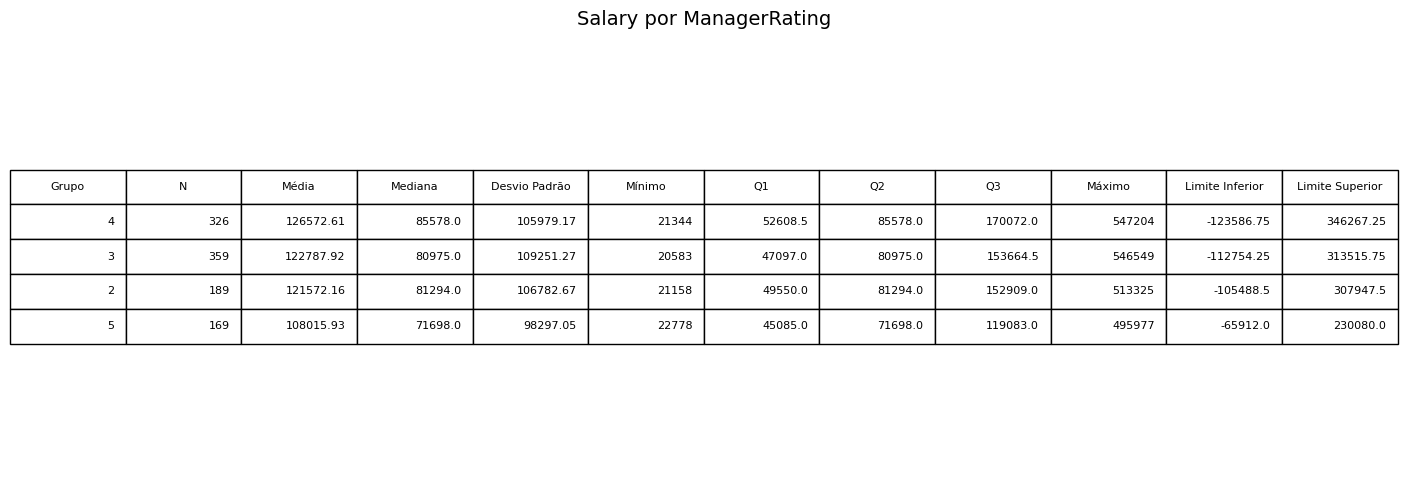

In [38]:
df = employee_review_base_atual

# variável quantitativa
quanti = 'Salary'

# variáveis qualitativas
quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'OverTime',
    'EducationField',
    'JobRole',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
     'WorkLifeBalance',
    'SelfRating',
       'ManagerRating'
]

for coluna_quali in quali:

    resultados = []

    for grupo in df[coluna_quali].dropna().unique():

        df_filtrado = df[df[coluna_quali] == grupo]

        resumo = eda_quanti(df_filtrado, quanti)

        resumo['Grupo'] = grupo

        resumo['N'] = len(df_filtrado)

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'N',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.sort_values(
        'Média',
        ascending=False
    )

    tabela_final = tabela_final.round(2)


    fig, ax = plt.subplots(figsize=(14, 5))

    ax.axis('off')

    plt.title(
        f'{quanti} por {coluna_quali}',
        fontsize=14
    )

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.scale(1.1, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()



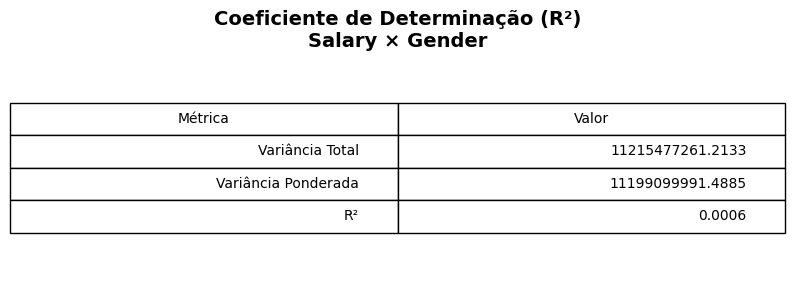

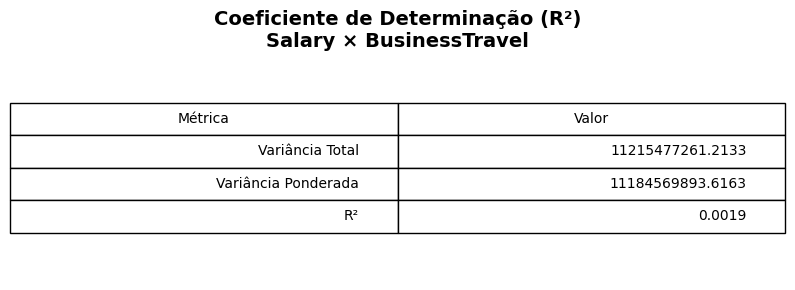

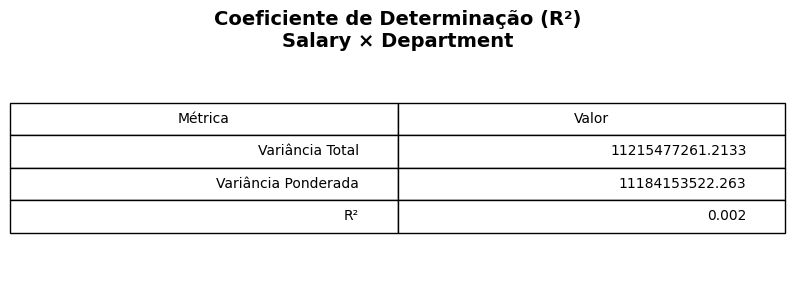

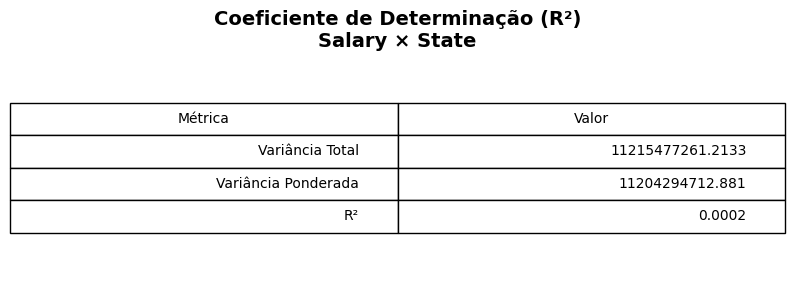

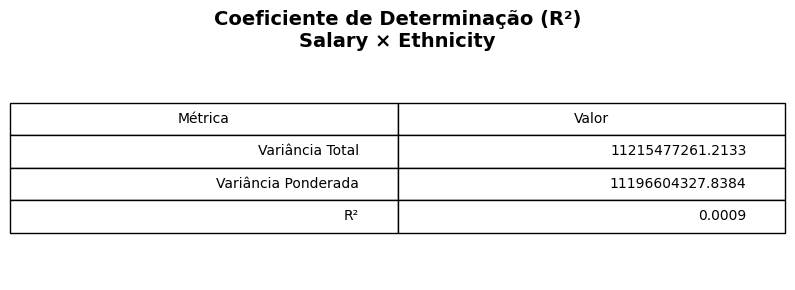

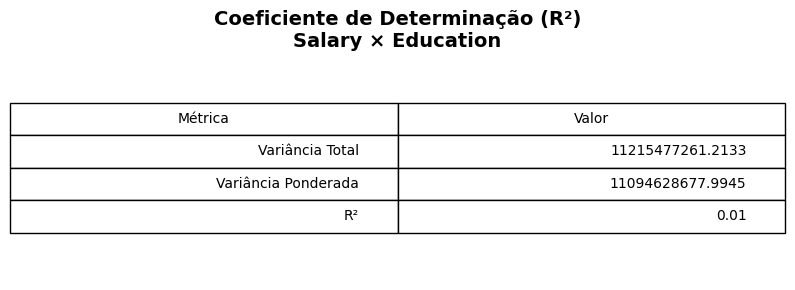

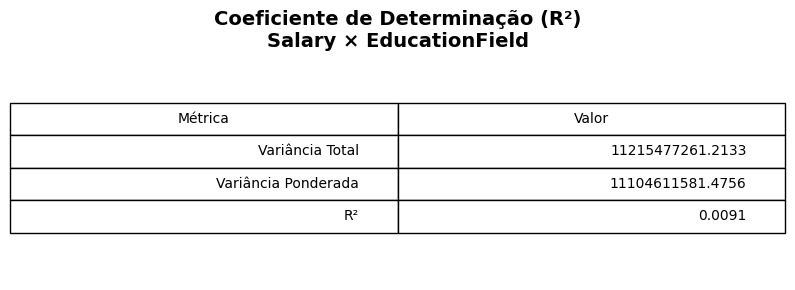

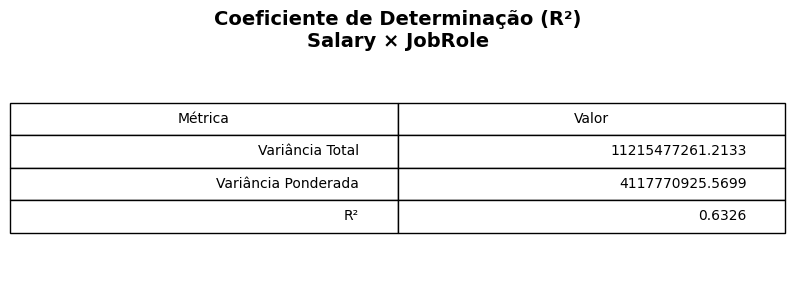

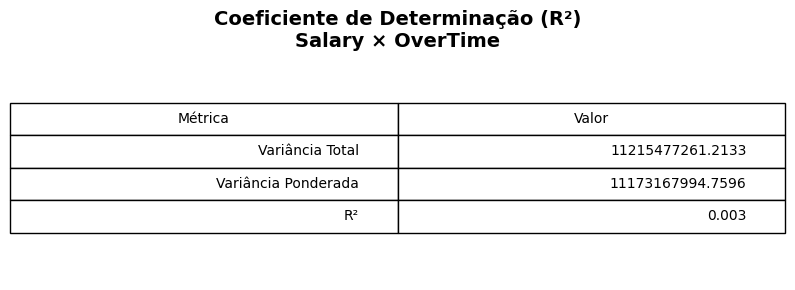

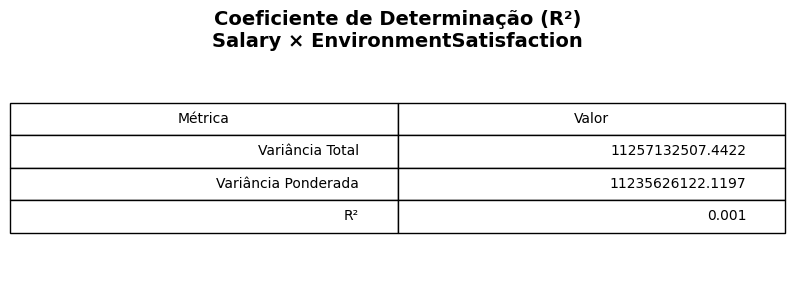

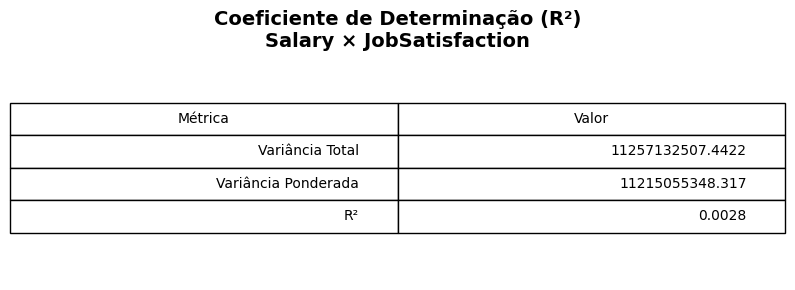

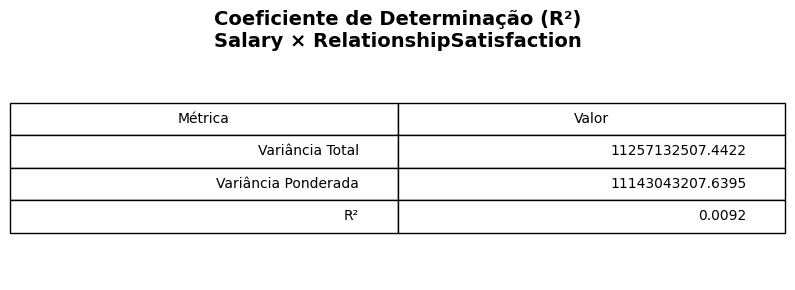

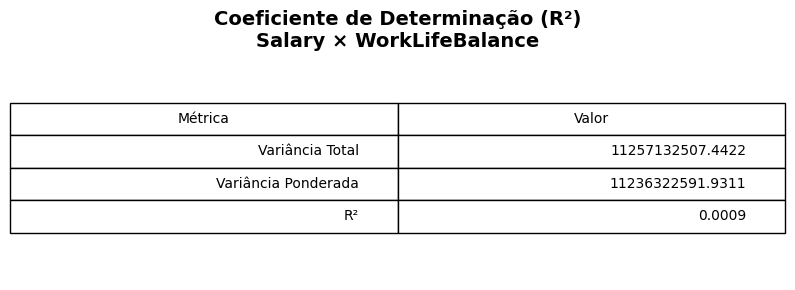

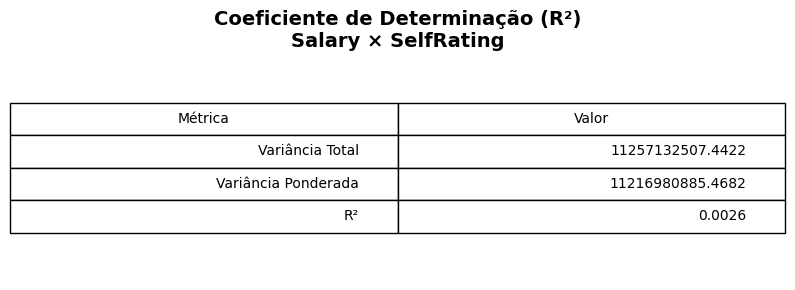

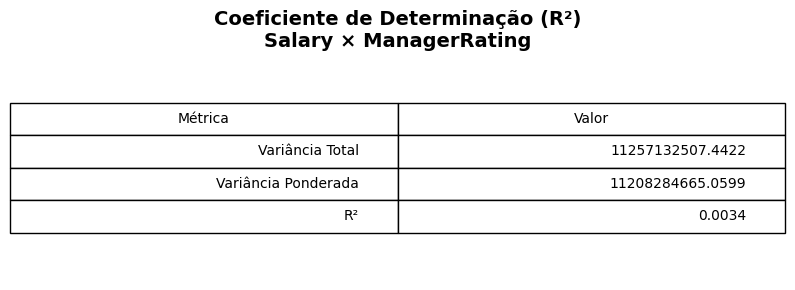

In [18]:
import pandas as pd
import numpy as np

df = employee_review_base_atual

# variável quantitativa
quanti = 'Salary'

# variáveis qualitativas
quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'JobRole',
    'OverTime',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
     'WorkLifeBalance',
    'SelfRating',
       'ManagerRating'
]



def coef_determinacao(df, qualitativa, quantitativa):

    dados = df[[qualitativa, quantitativa]].dropna()

    media_geral = dados[quantitativa].mean()

    SST = (
        (dados[quantitativa] - media_geral) ** 2
    ).sum()

    medias_grupos = (
        dados.groupby(qualitativa)[quantitativa]
        .transform('mean')
    )

    SSW = (
        (dados[quantitativa] - medias_grupos) ** 2
    ).sum()

    r2 = 1 - (SSW / SST)

    var_total = dados[quantitativa].var()

    var_ponderada = SSW / len(dados)

    return r2, var_total, var_ponderada

for x in quali:

    # calcular métricas
    resultado = coef_determinacao(
        df,
        x,
        quanti
    )

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })


    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n'
        f'{quanti} × {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.tight_layout()
    plt.show()

    plt.close()

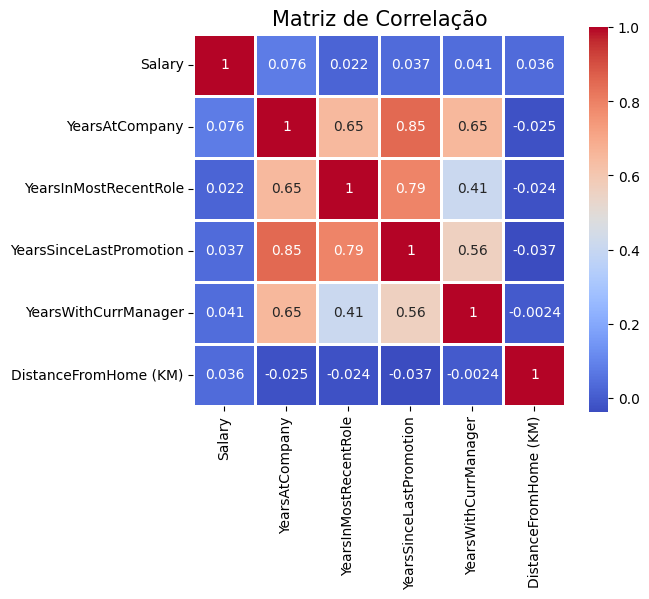

In [19]:
# Biblioteca para exibir os gráficos.
import matplotlib.pyplot as plt

# Biblioteca para visualizações estatísticas.
import seaborn as sns

# Biblioteca para criar PDF.
from matplotlib.backends.backend_pdf import PdfPages

#### ---- ATUALIZAR AQUI COLUNAS DE INTERESSE---------------####################
#É possivel colocar mais de 2 variaveis na matriz de correlação
dado_1 = 'Salary'
dado_2 = 'YearsAtCompany'
dado_3 = 'YearsInMostRecentRole'
dado_4 = 'YearsSinceLastPromotion'
dado_5 = 'YearsWithCurrManager'
dado_6 = 'DistanceFromHome (KM)'

df = employee_review_base_atual

data =  df[[dado_1, dado_2, dado_3, dado_4, dado_5, dado_6]]

correlacao = data.corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    correlacao,          # matriz de correlação
    annot=True,          # escreve os valores nas células
    cmap="coolwarm",     # paleta de cores
    linewidths=1,        # linhas entre as células
    square=True          # células quadradas
)

plt.title("Matriz de Correlação", fontsize=15)

plt.show()

plt.close()


# **Tempo de empresa**

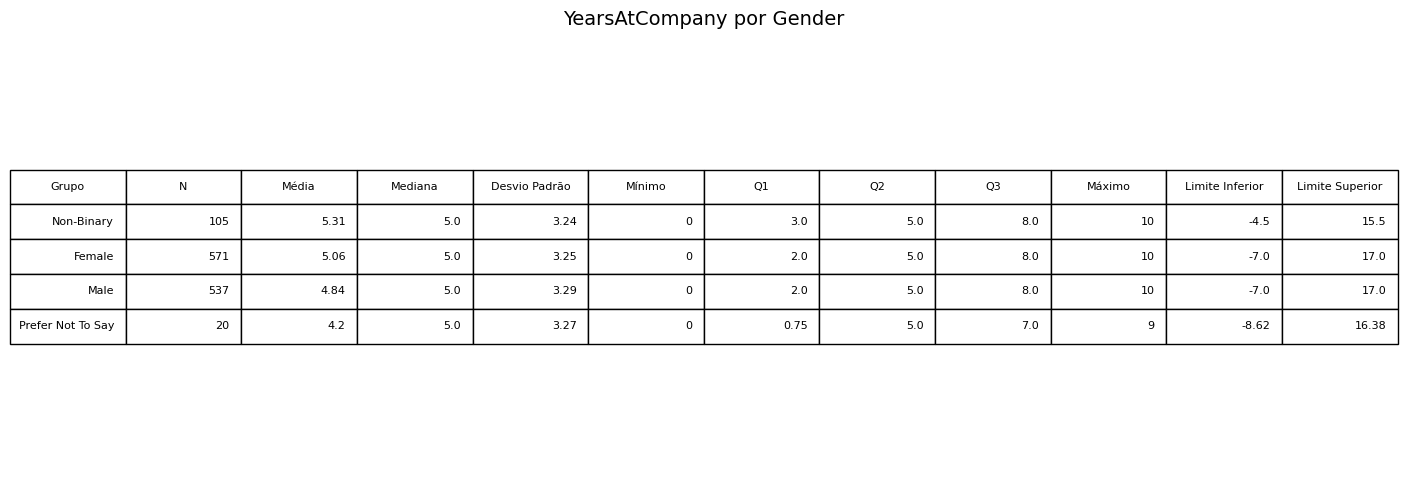

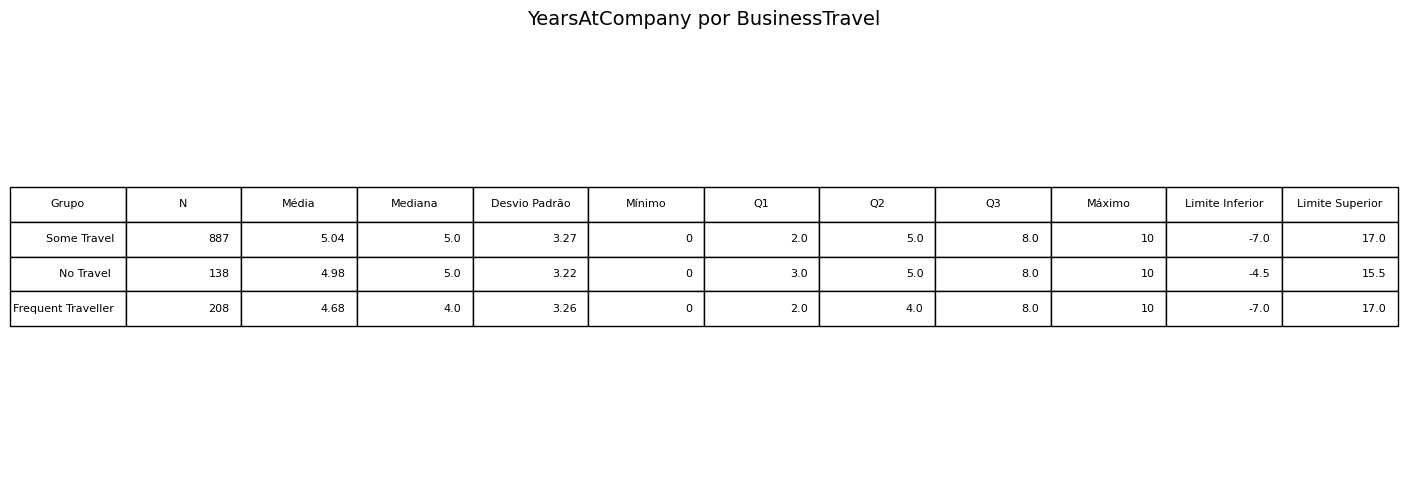

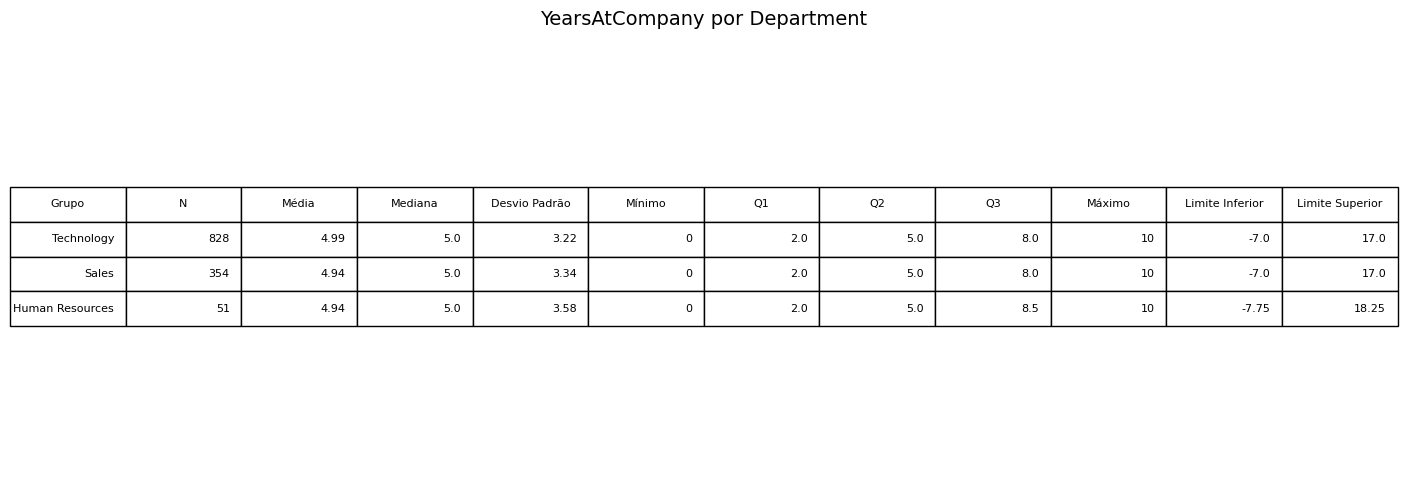

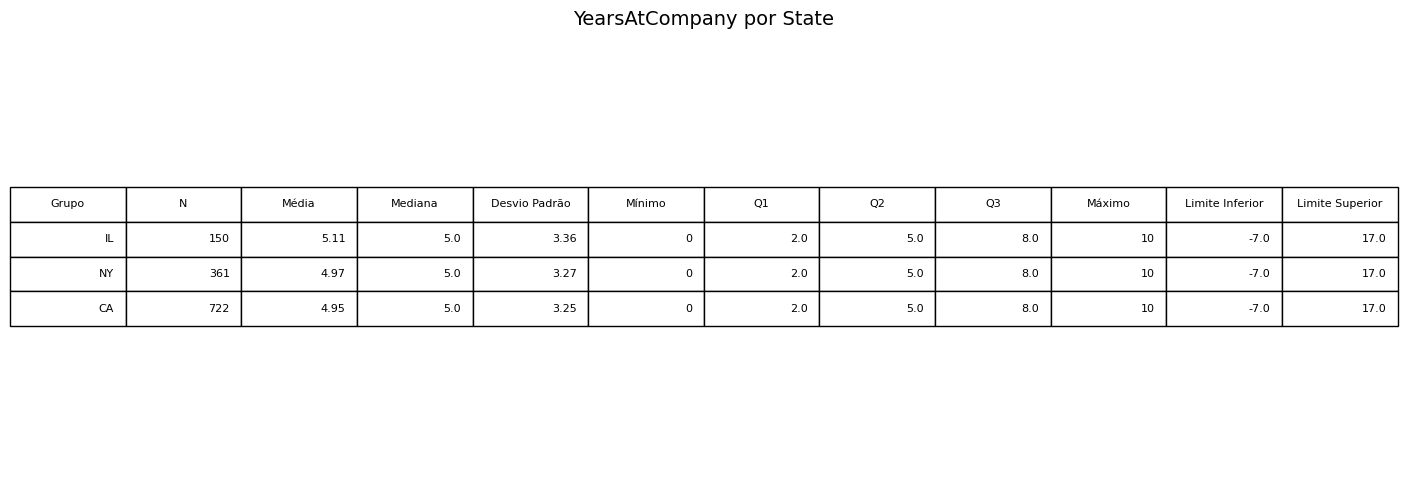

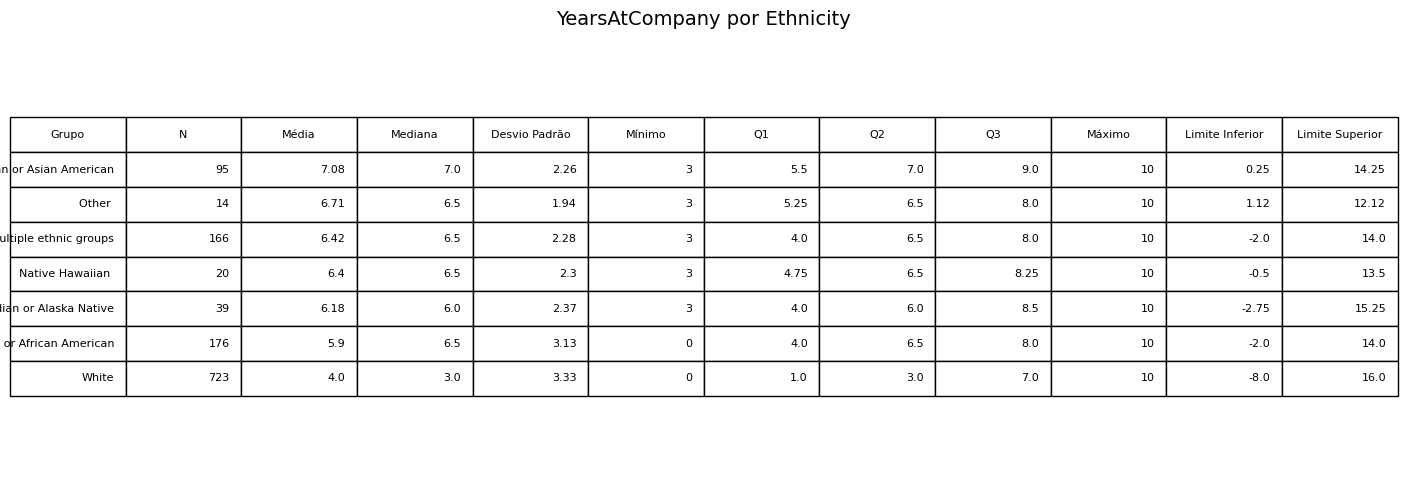

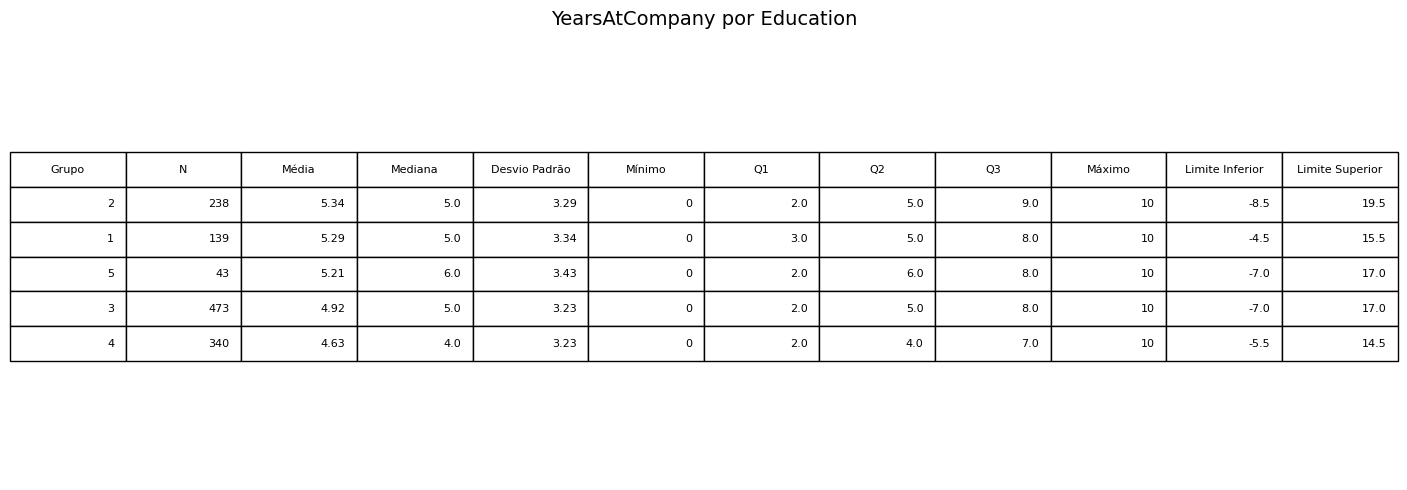

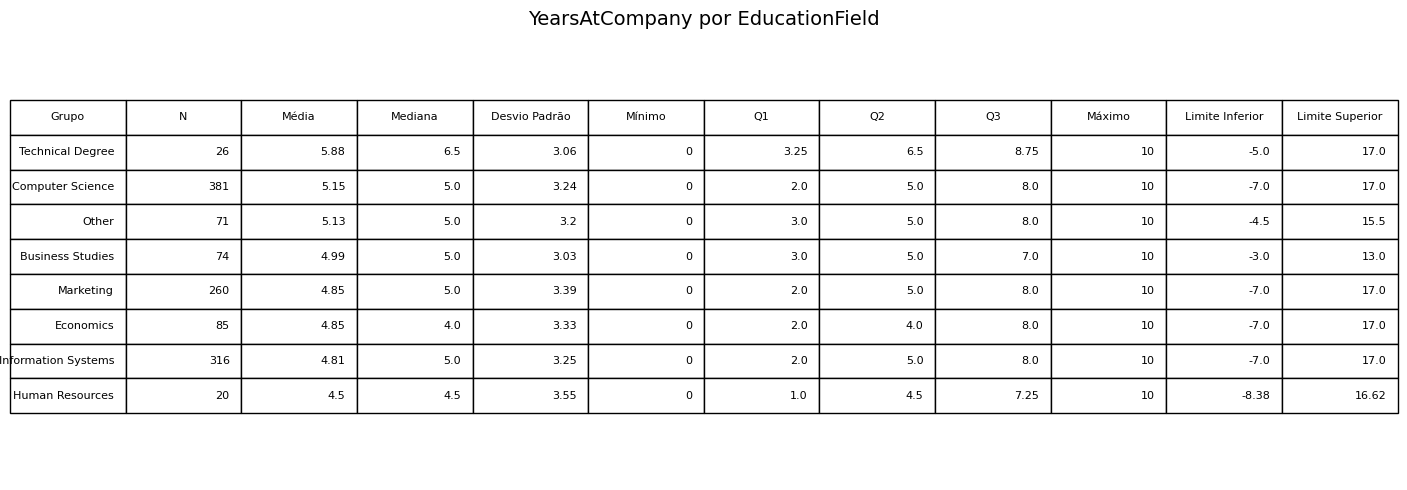

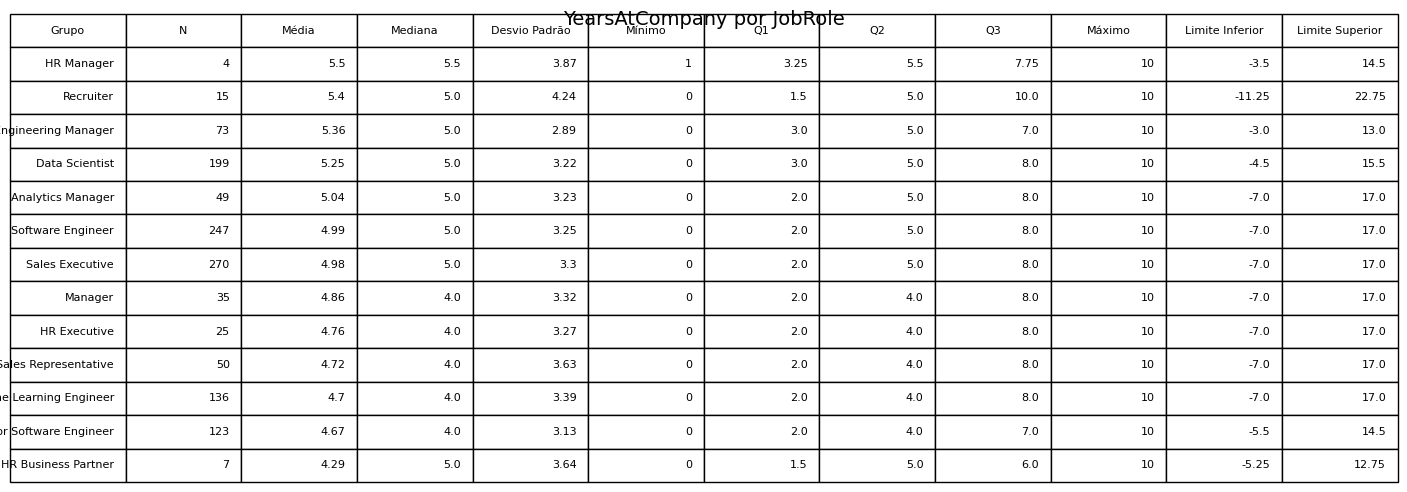

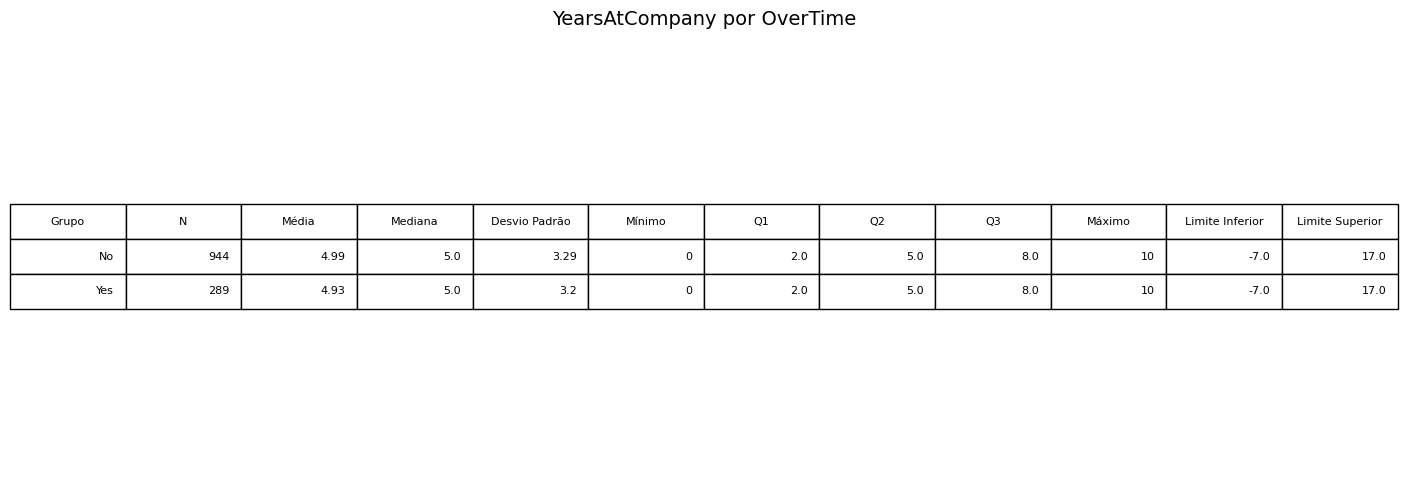

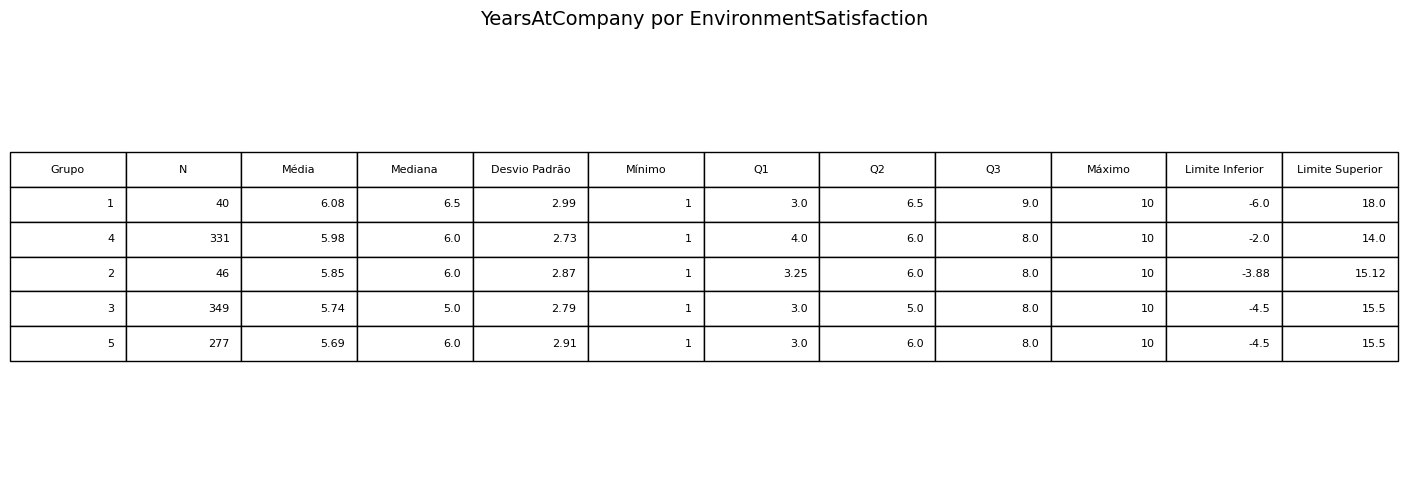

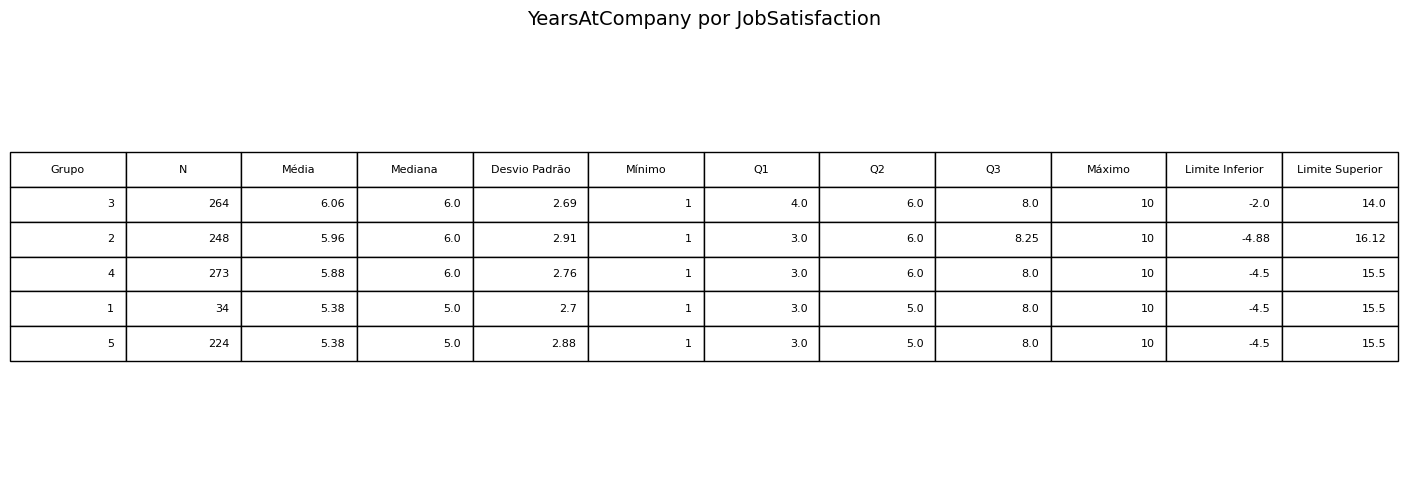

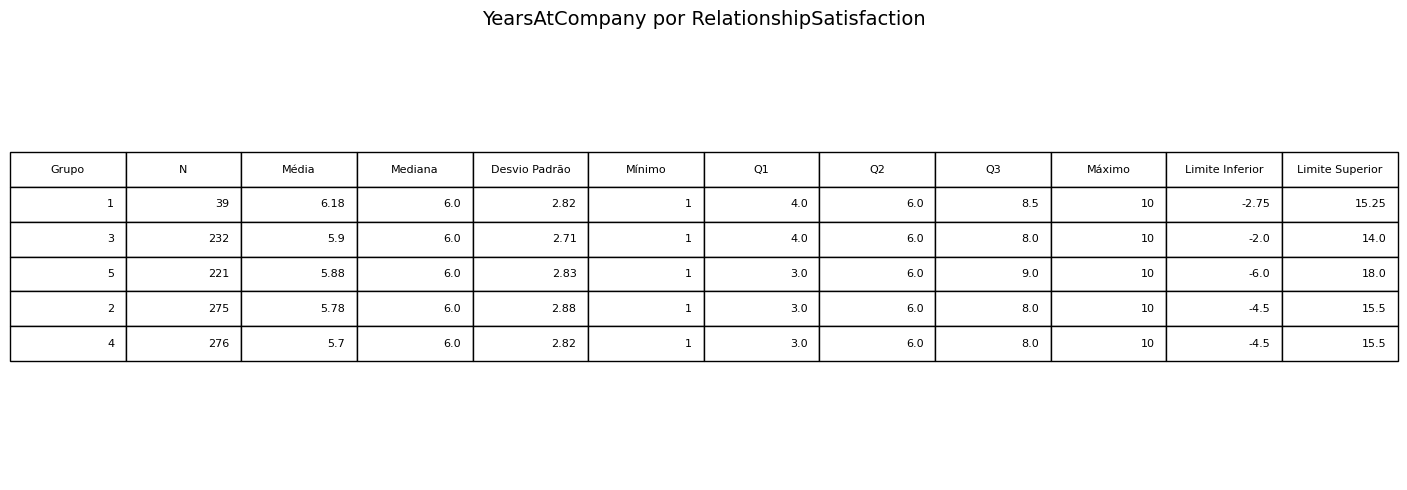

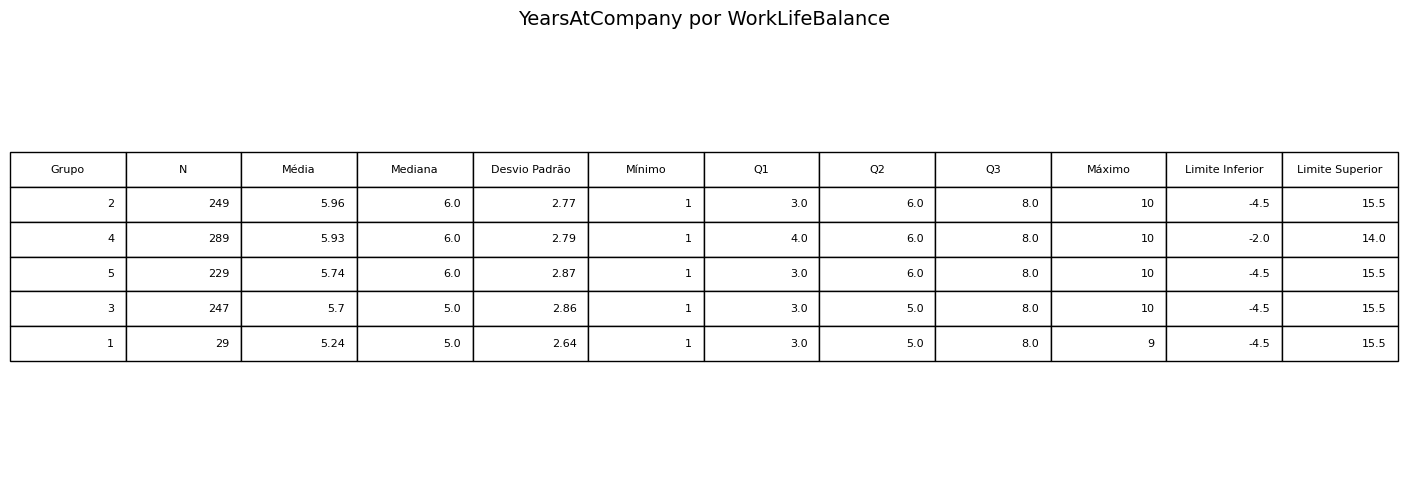

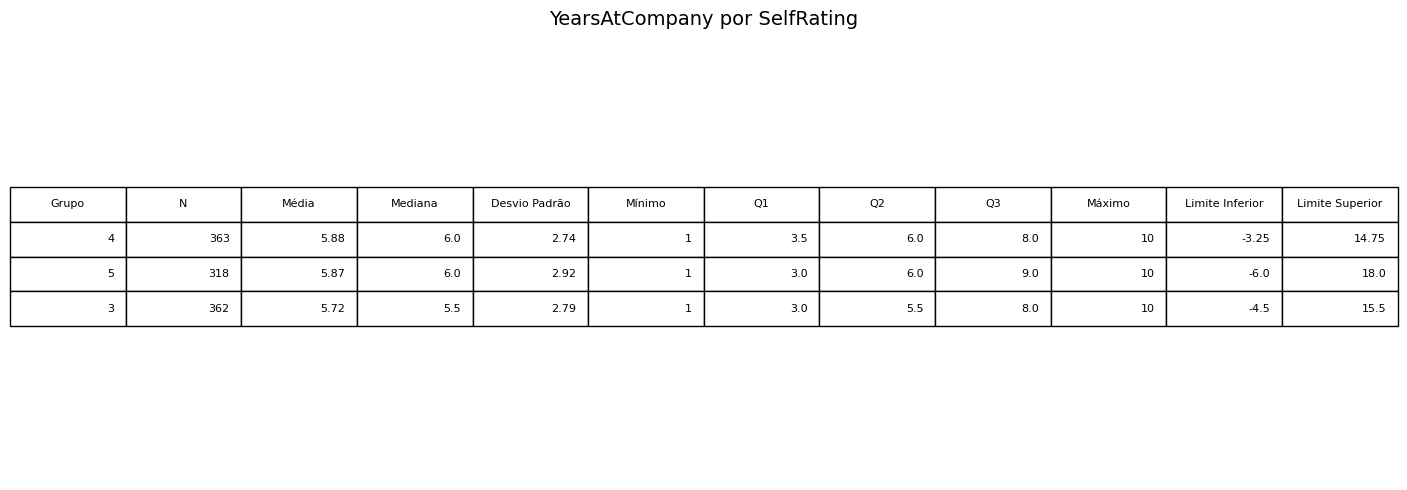

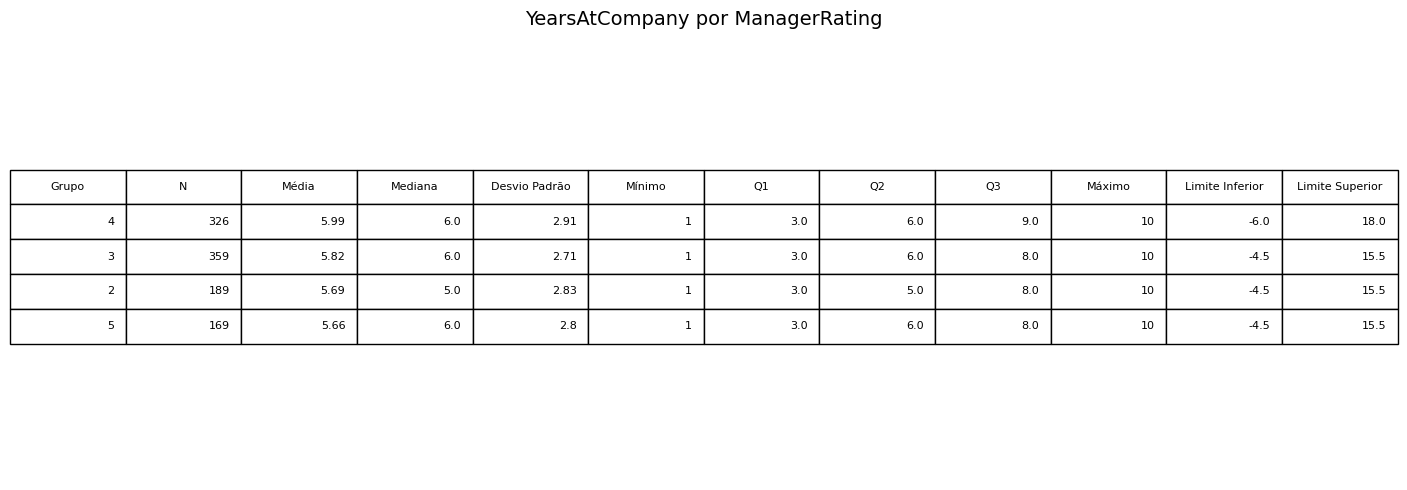

In [39]:
df = employee_review_base_atual

# variável quantitativa
quanti = 'YearsAtCompany'

# variáveis qualitativas
quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'JobRole',
    'OverTime',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
     'WorkLifeBalance',
    'SelfRating',
       'ManagerRating'
]


for coluna_quali in quali:

    resultados = []

    for grupo in df[coluna_quali].dropna().unique():

        df_filtrado = df[df[coluna_quali] == grupo]

        resumo = eda_quanti(df_filtrado, quanti)

        resumo['Grupo'] = grupo

        resumo['N'] = len(df_filtrado)

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'N',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.sort_values(
        'Média',
        ascending=False
    )

    tabela_final = tabela_final.round(2)


    fig, ax = plt.subplots(figsize=(14, 5))

    ax.axis('off')

    plt.title(
        f'{quanti} por {coluna_quali}',
        fontsize=14
    )

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.scale(1.1, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()



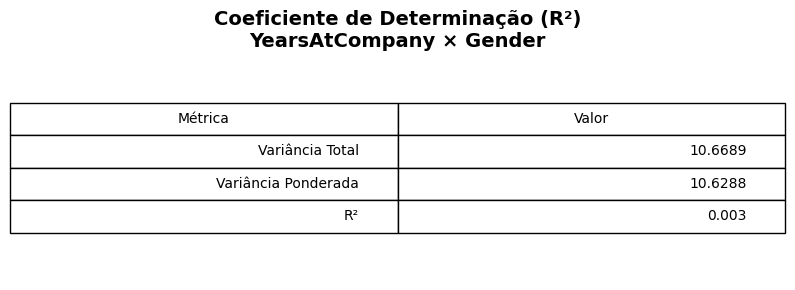

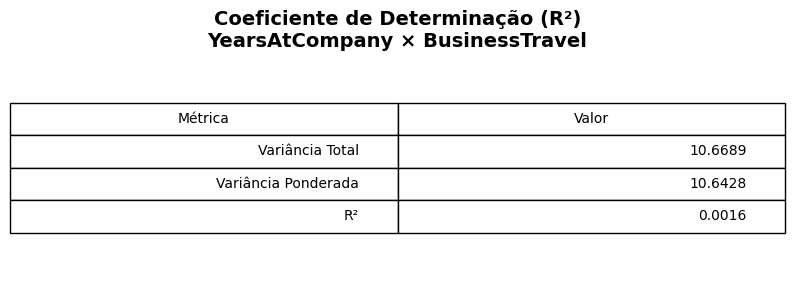

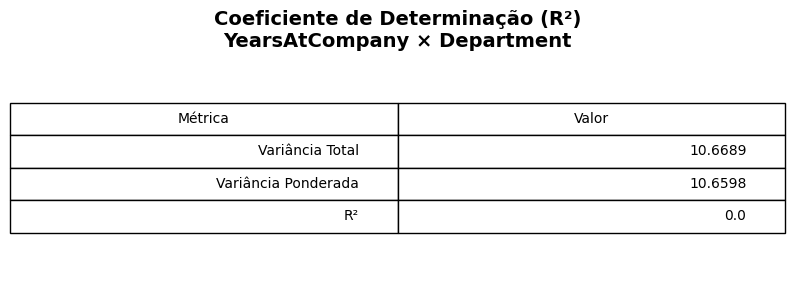

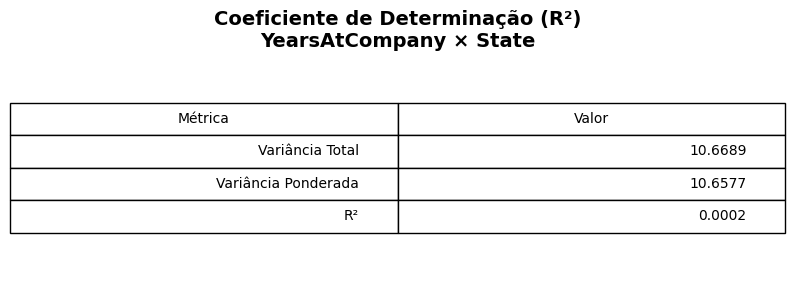

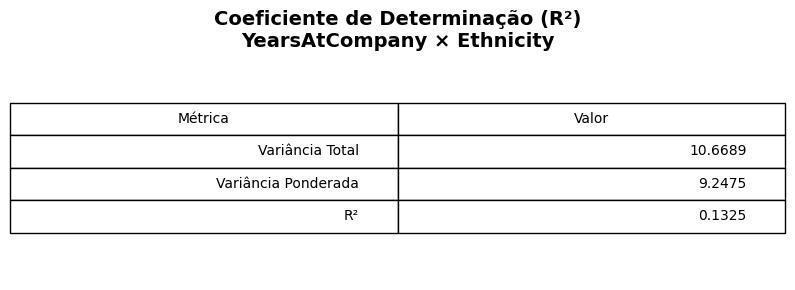

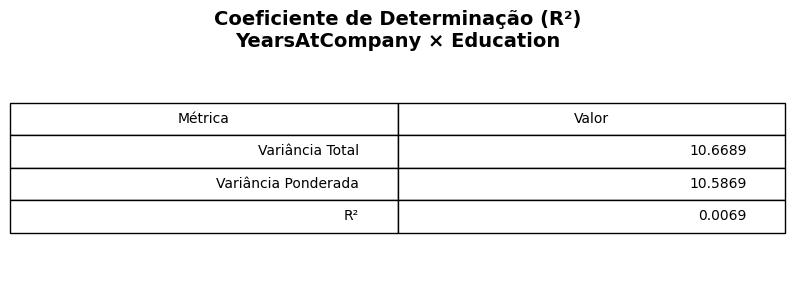

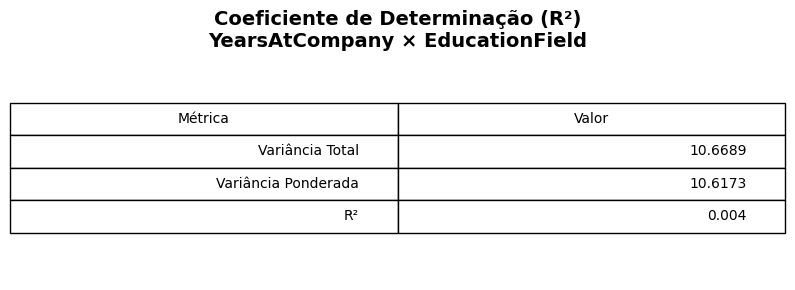

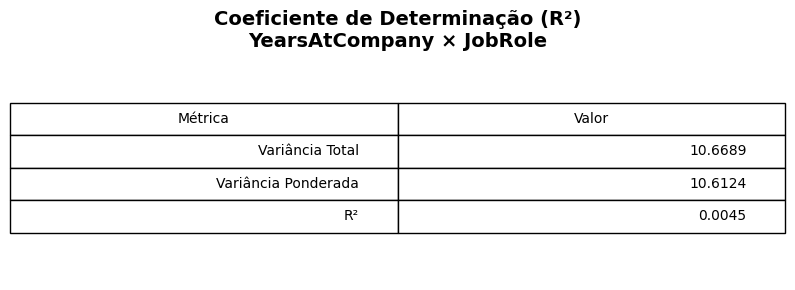

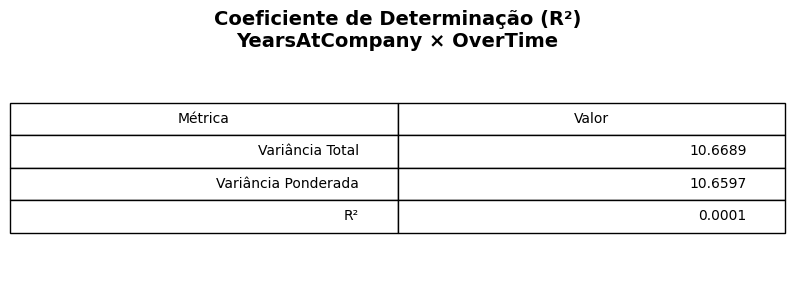

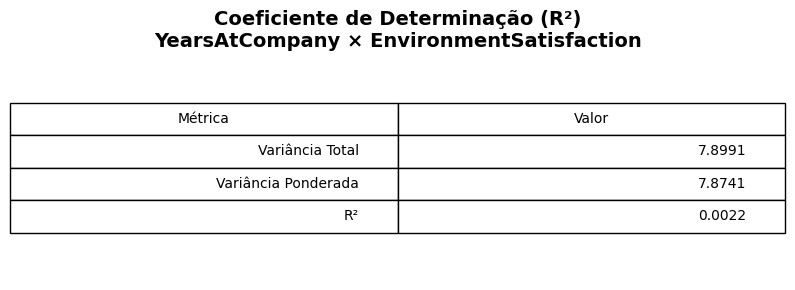

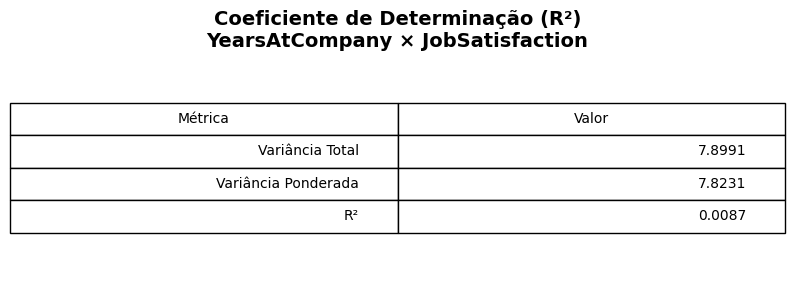

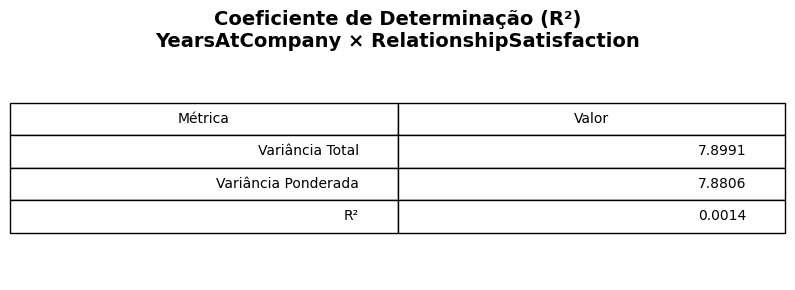

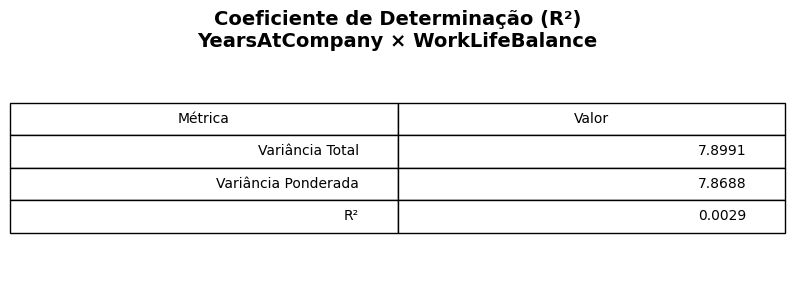

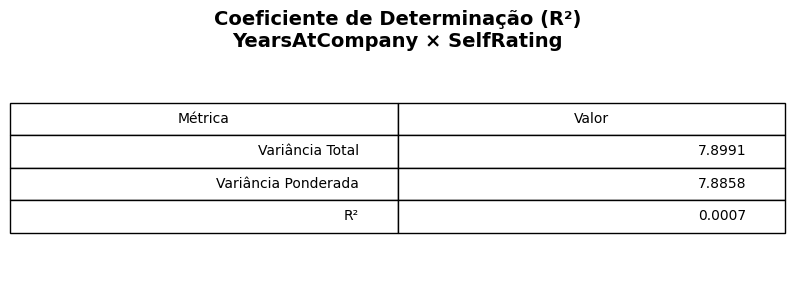

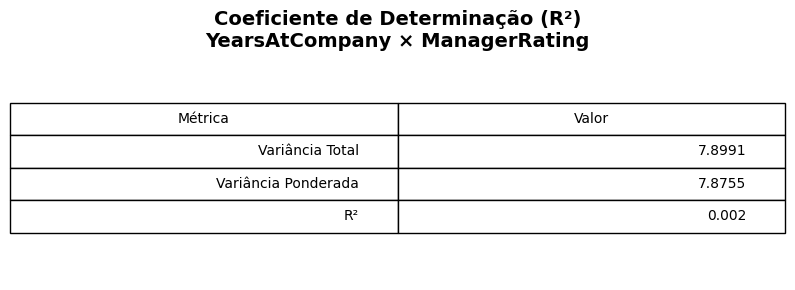

In [40]:
import pandas as pd
import numpy as np

df = employee_review_base_atual

# variável quantitativa
quanti = 'YearsAtCompany'

# variáveis qualitativas
quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'JobRole',
    'OverTime',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
     'WorkLifeBalance',
    'SelfRating',
       'ManagerRating'
]

for x in quali:

    # calcular métricas
    resultado = coef_determinacao(
        df,
        x,
        quanti
    )

    r2 = resultado[0]
    var_total = resultado[1]
    var_ponderada = resultado[2]

    tabela = pd.DataFrame({
        'Métrica': [
            'Variância Total',
            'Variância Ponderada',
            'R²'
        ],
        'Valor': [
            round(var_total, 4),
            round(var_ponderada, 4),
            round(r2, 4)
        ]
    })


    fig, ax = plt.subplots(figsize=(8, 3))

    ax.axis('off')

    ax.set_title(
        f'Coeficiente de Determinação (R²)\n'
        f'{quanti} × {x}',
        fontsize=14,
        fontweight='bold'
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 2)

    plt.tight_layout()
    plt.show()

    plt.close()

# **Satisfaction**

In [22]:
print(employee_review.columns)

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceID', 'ReviewDate',
       'EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating'],
      dtype='object')


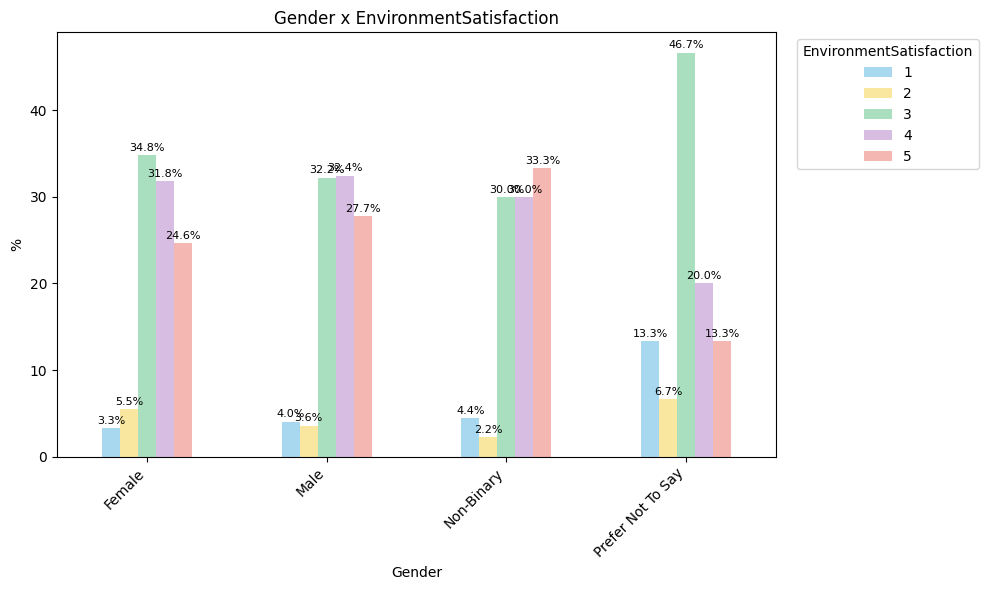

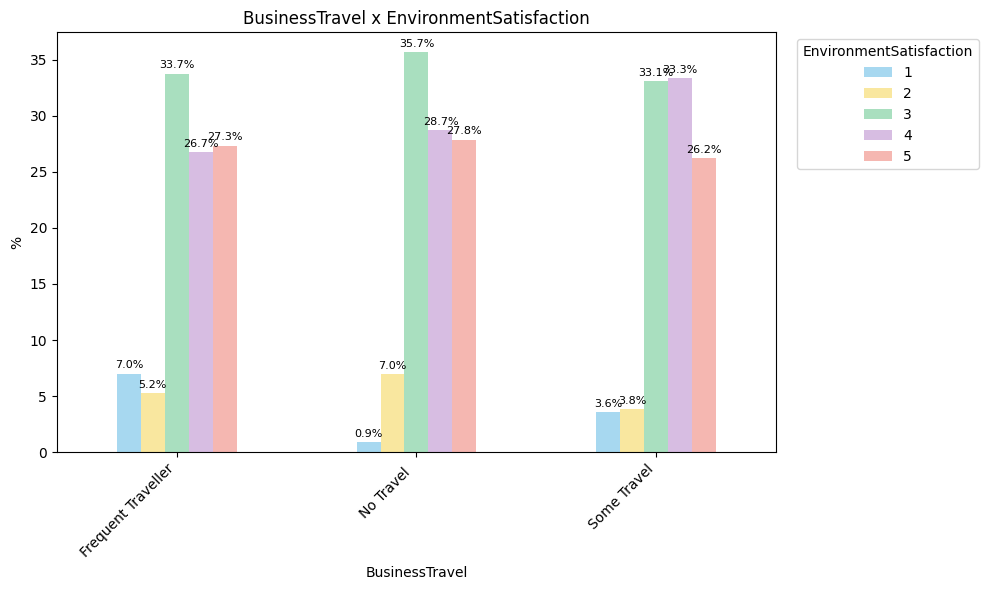

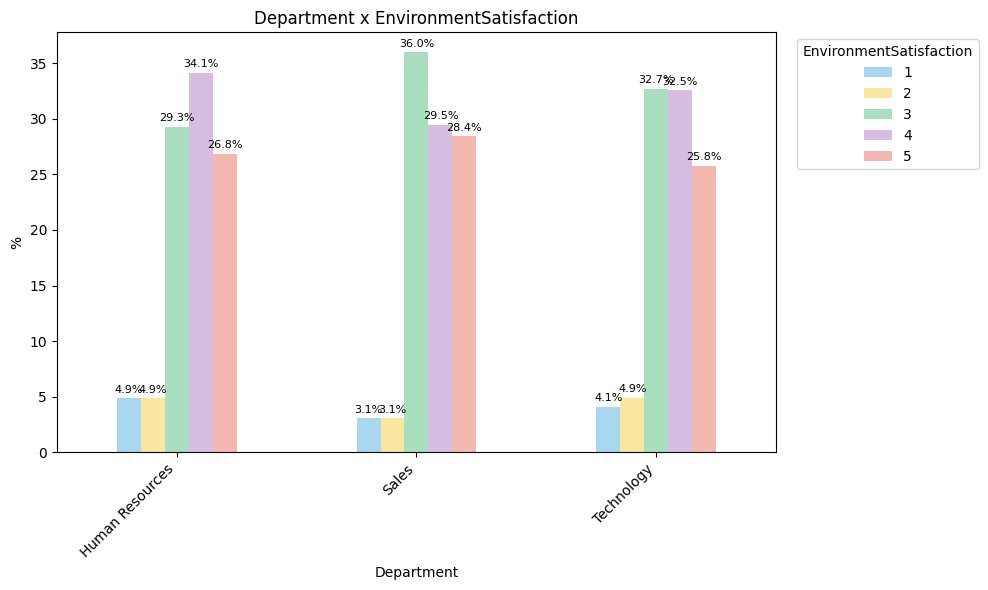

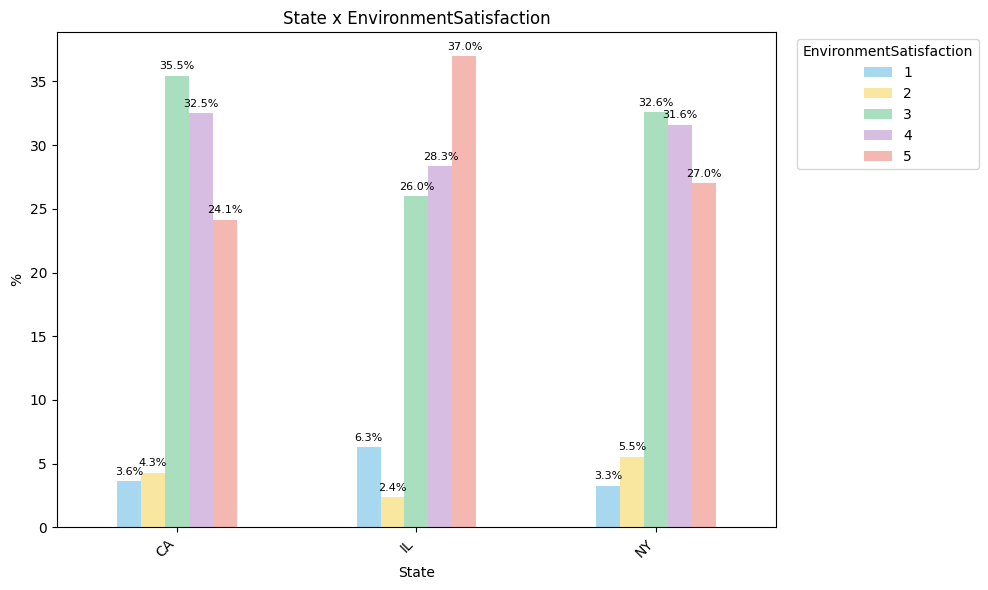

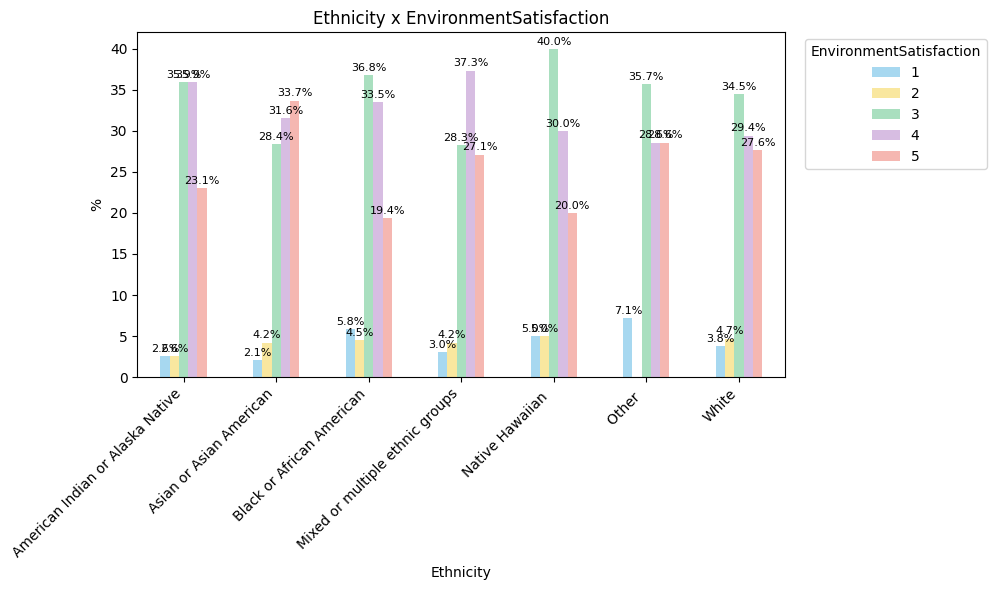

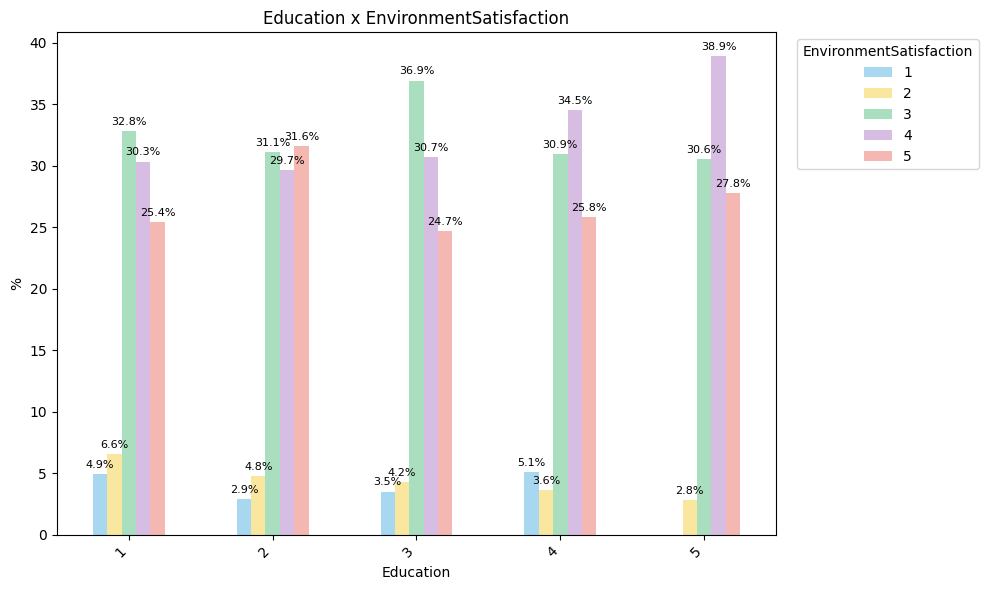

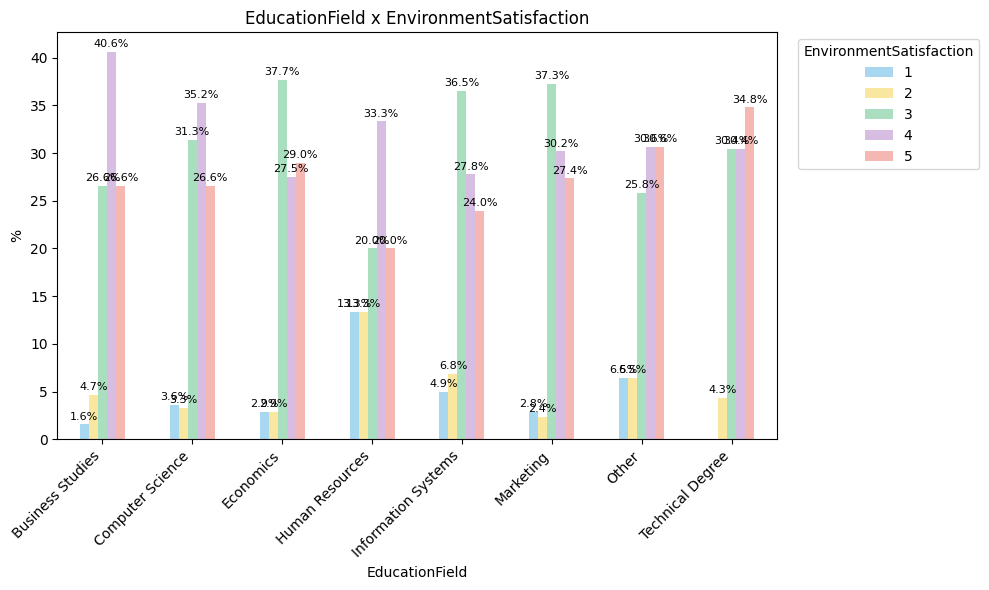

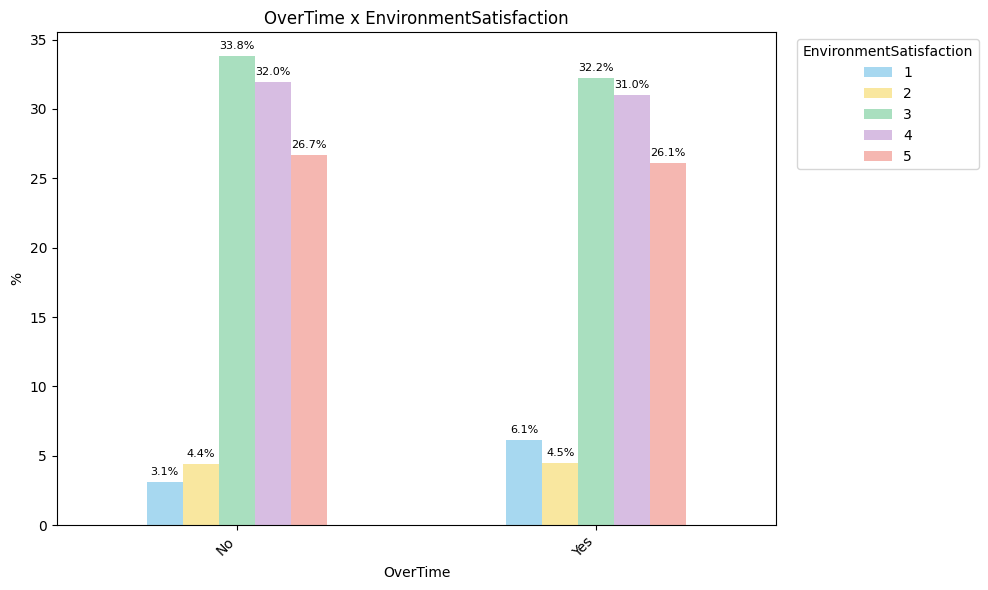

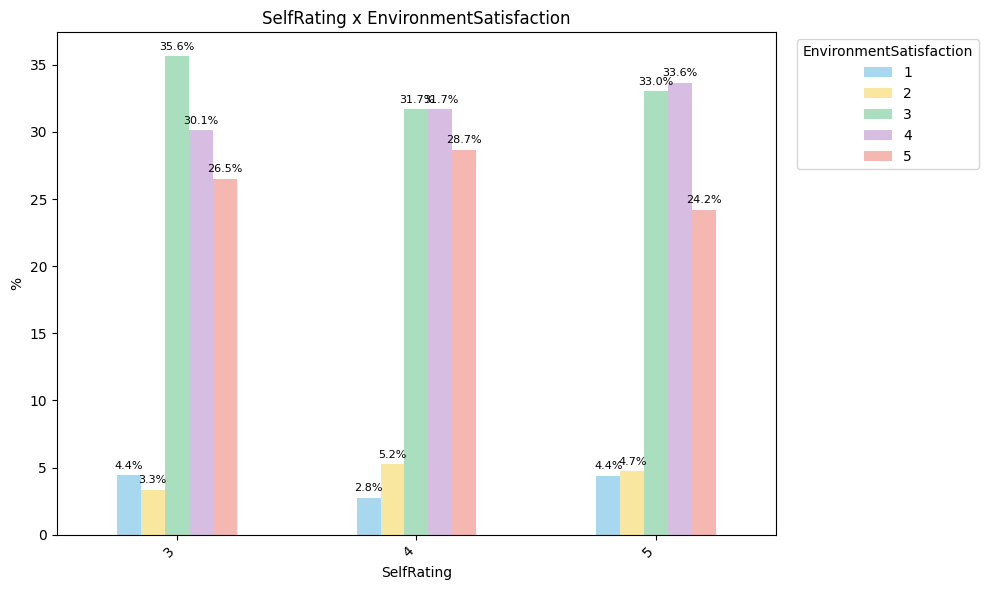

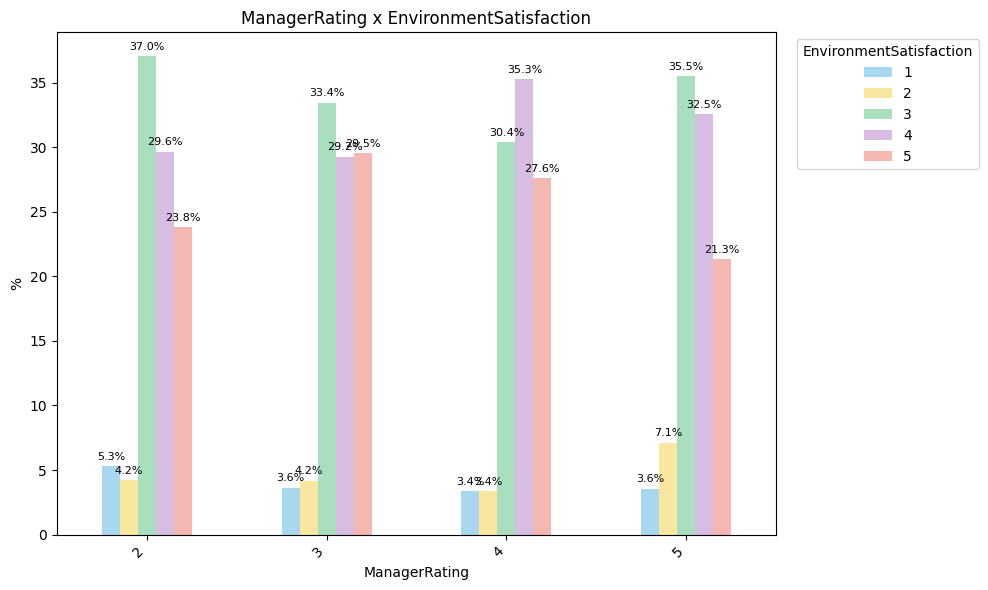

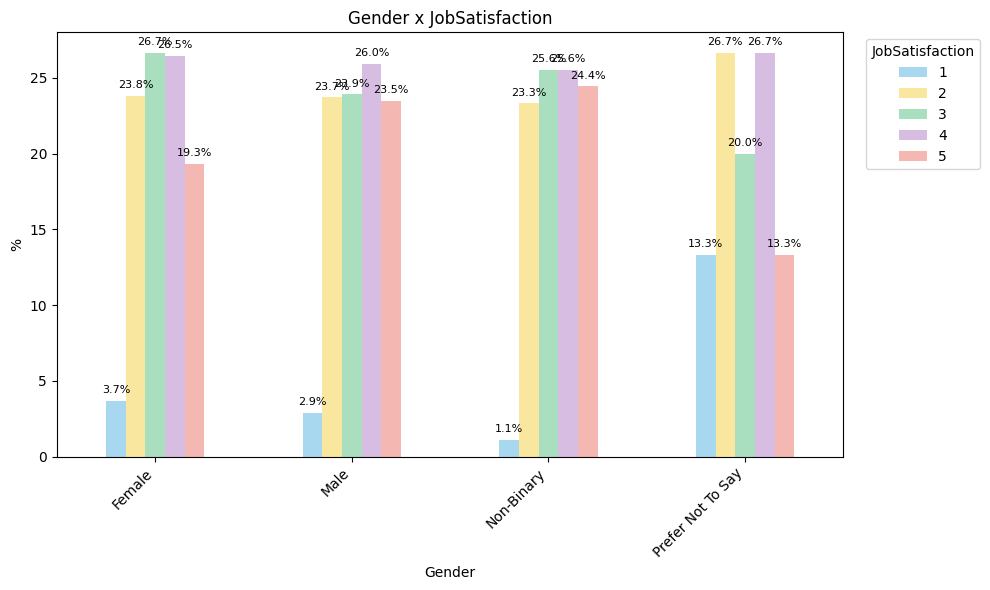

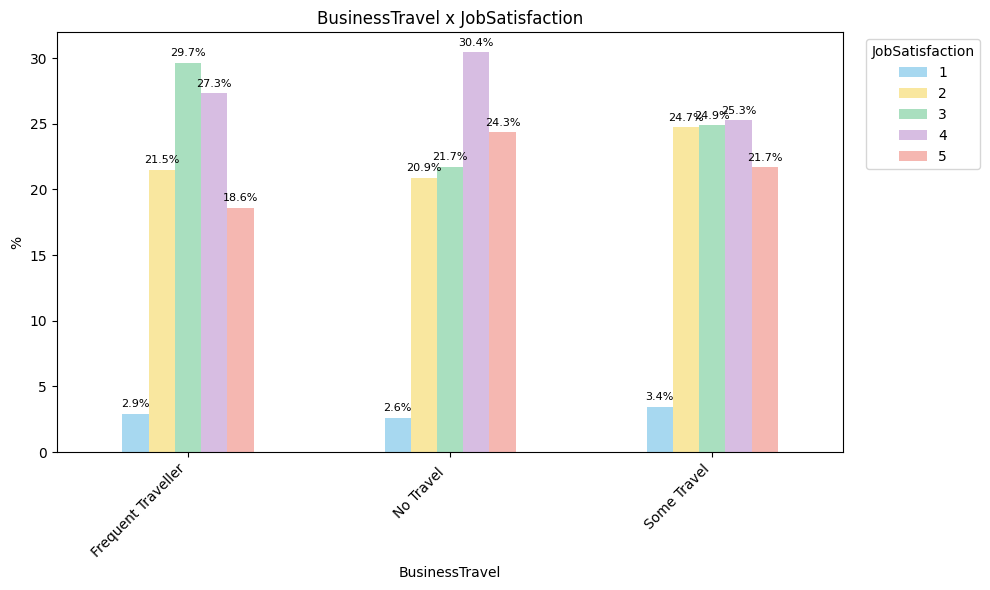

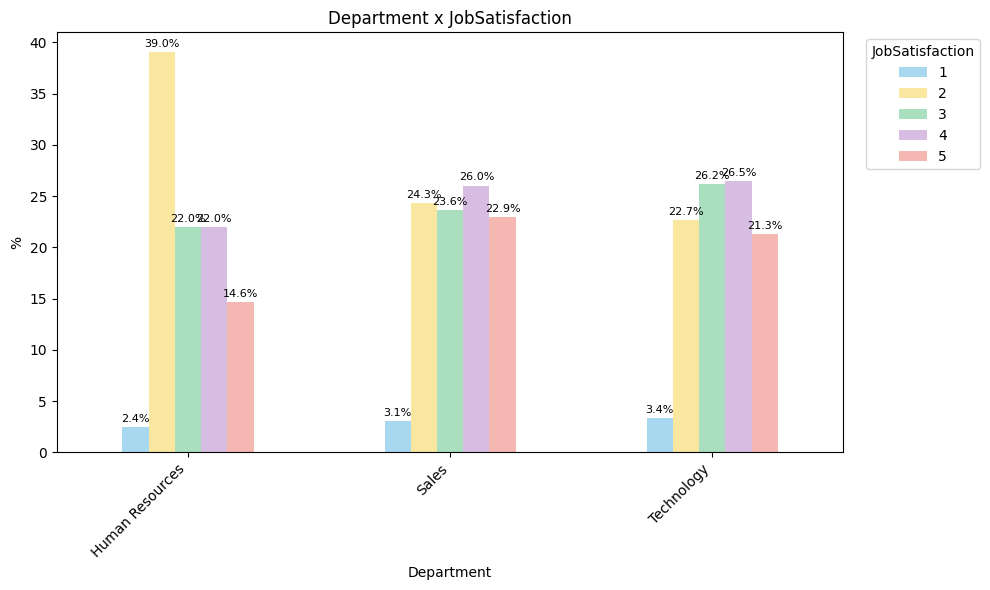

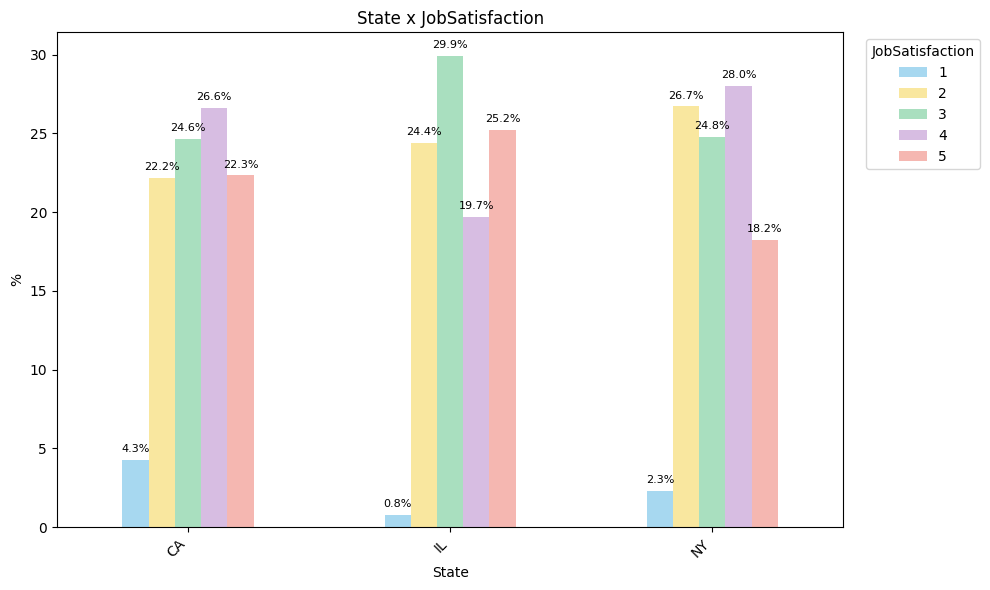

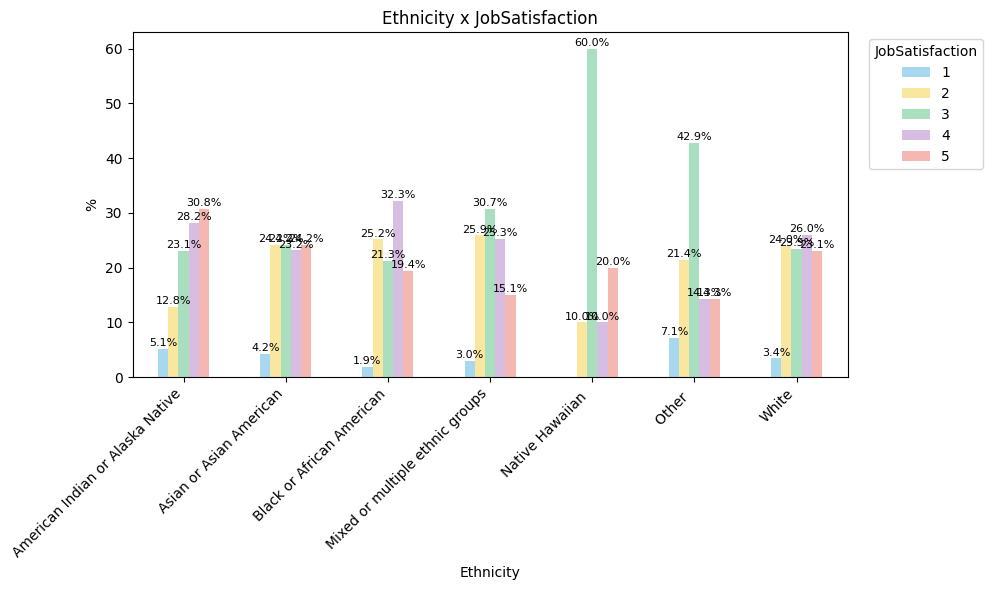

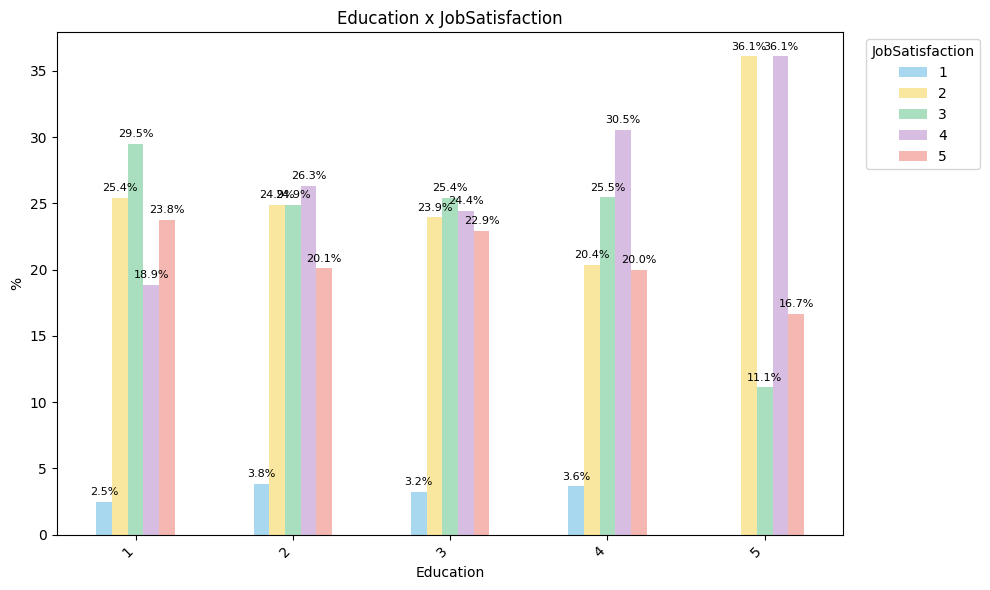

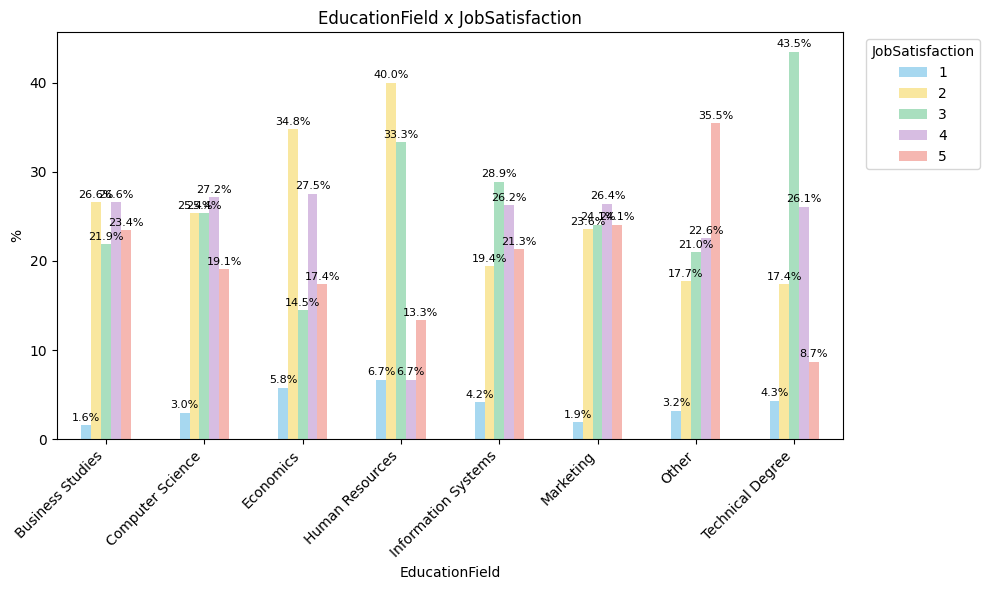

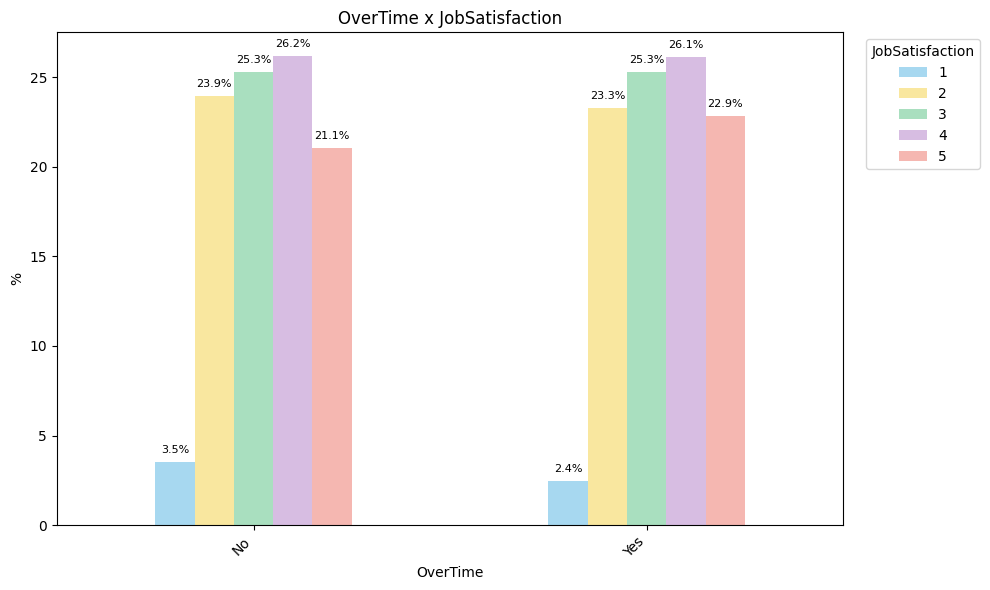

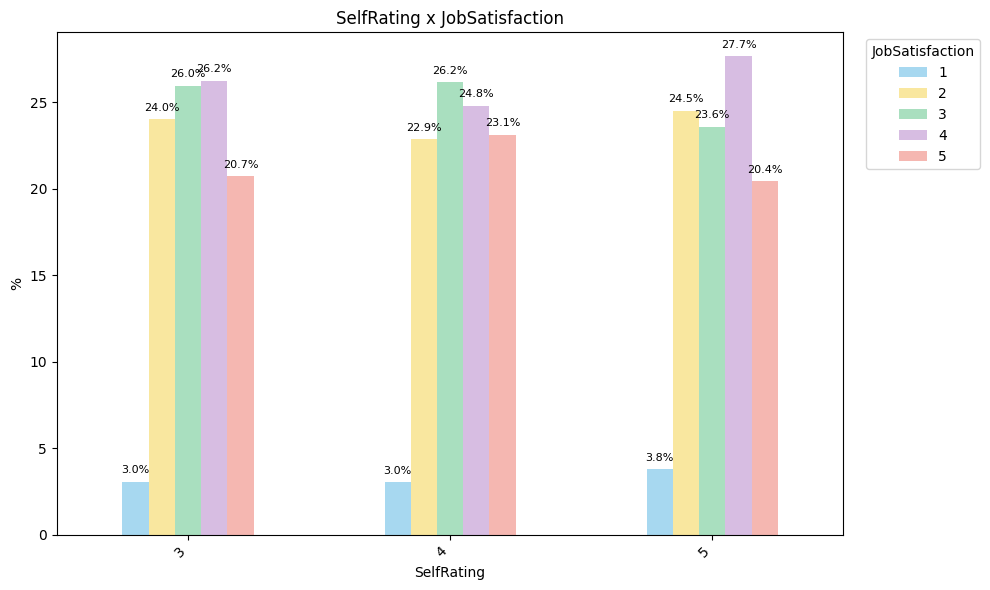

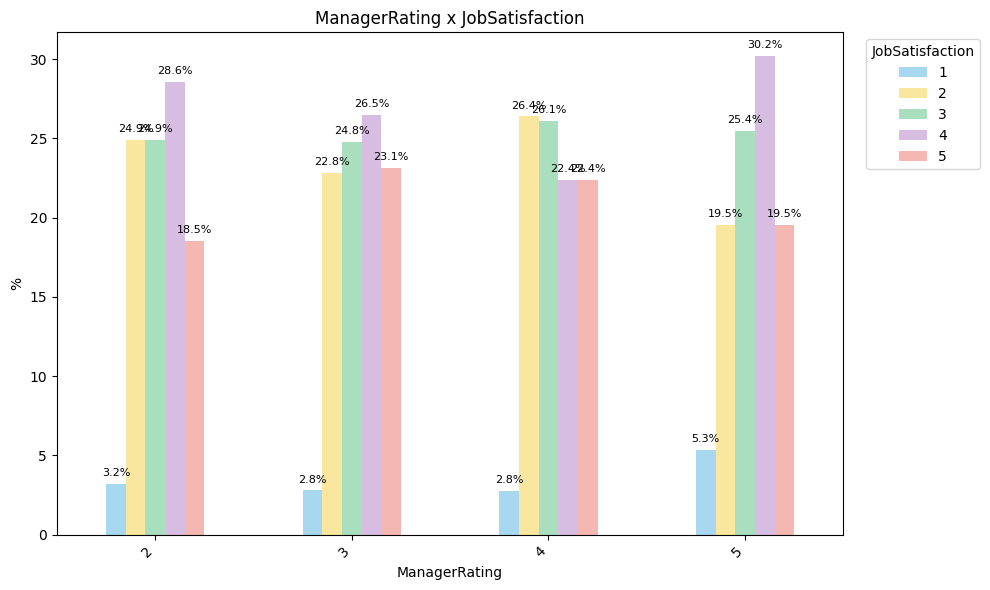

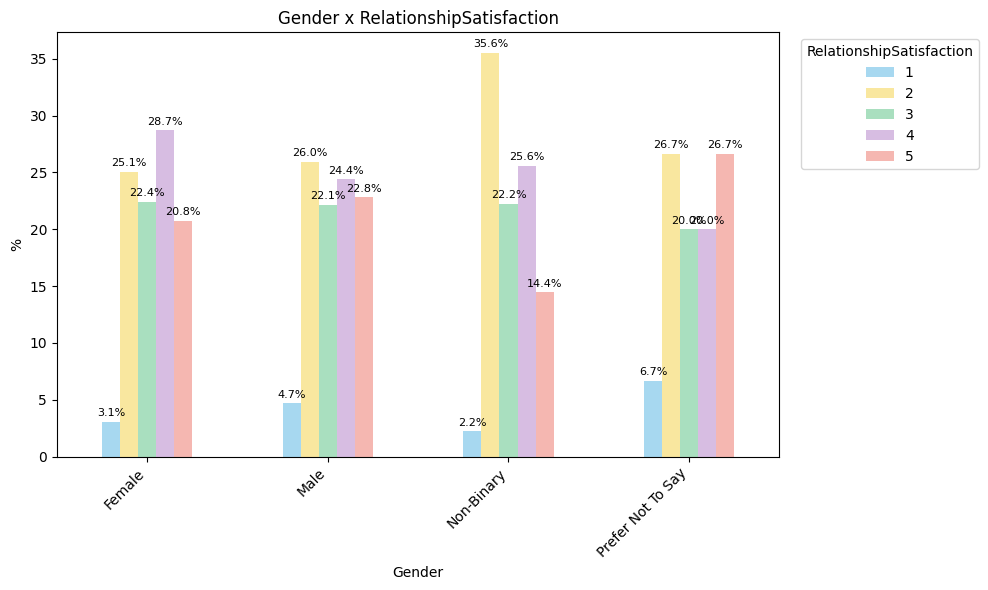

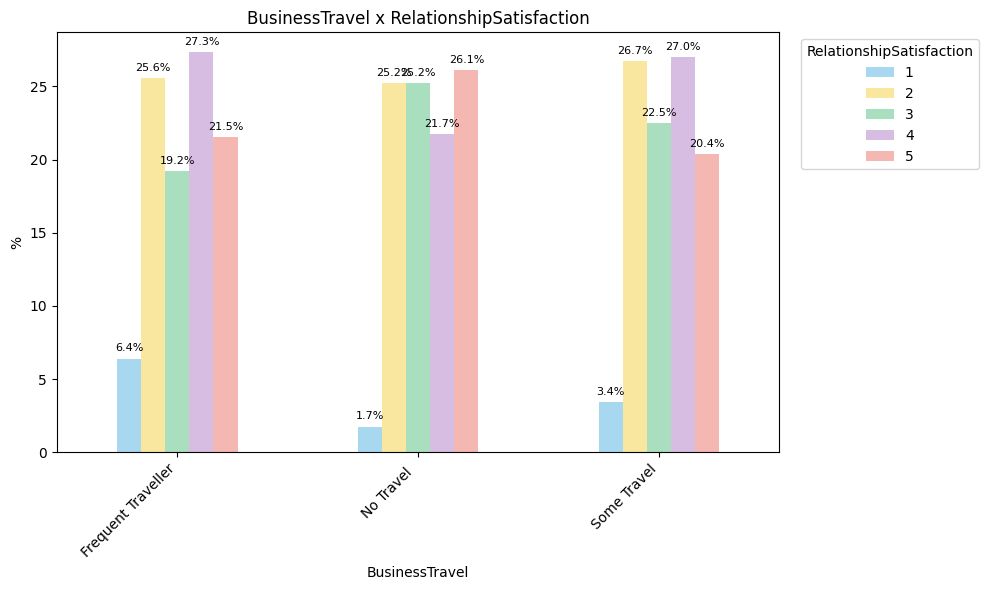

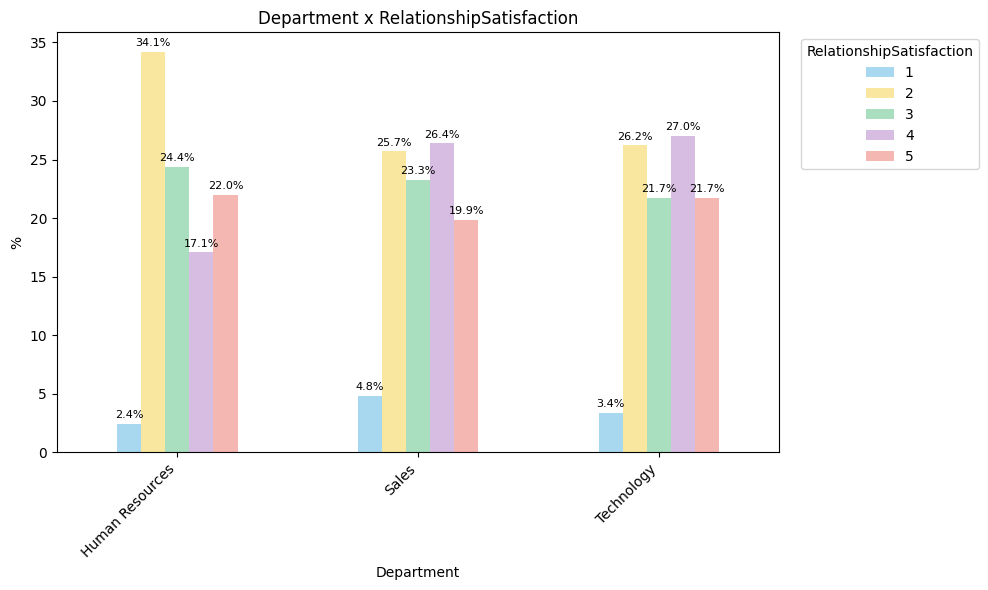

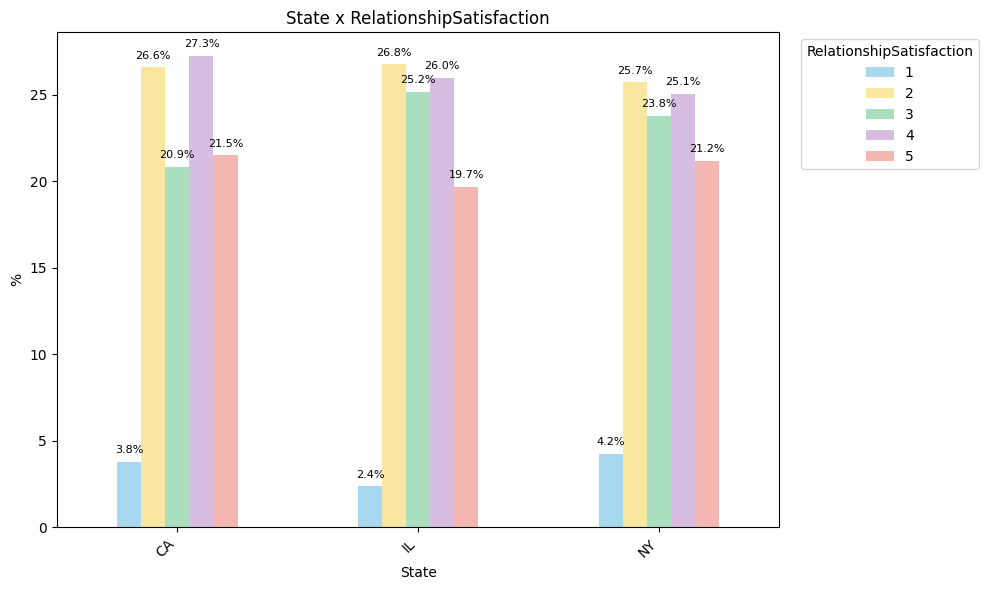

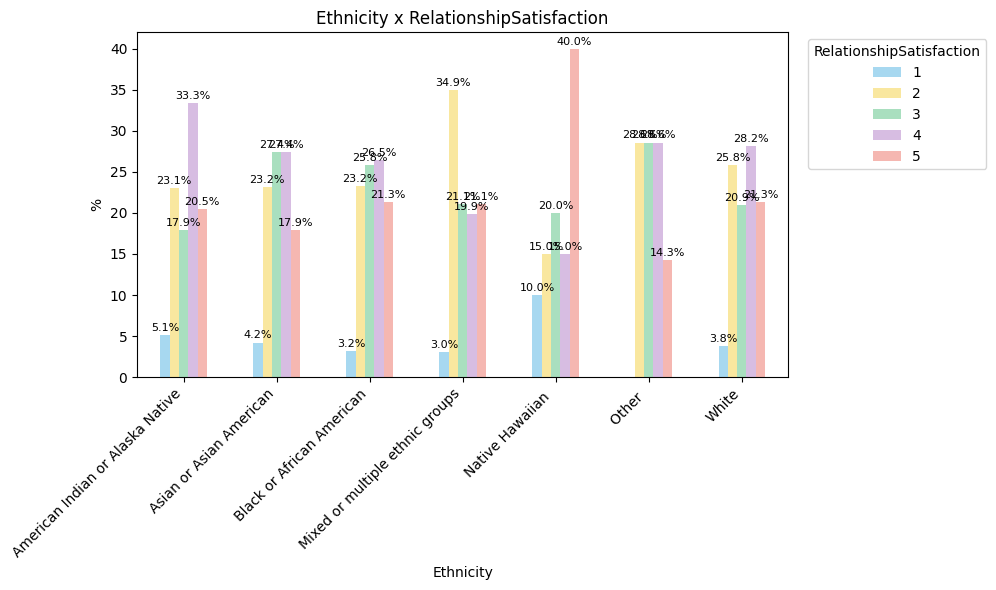

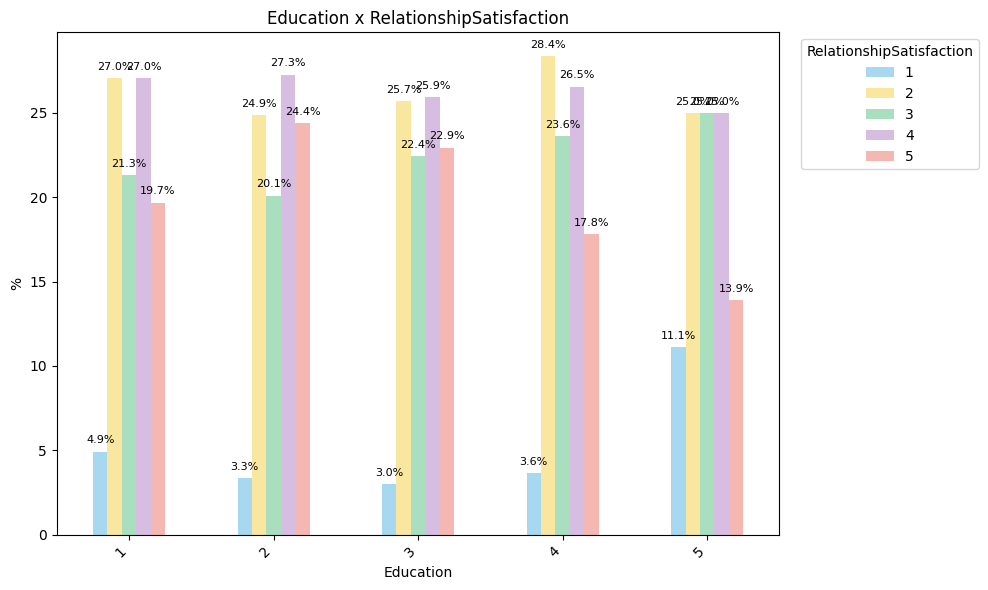

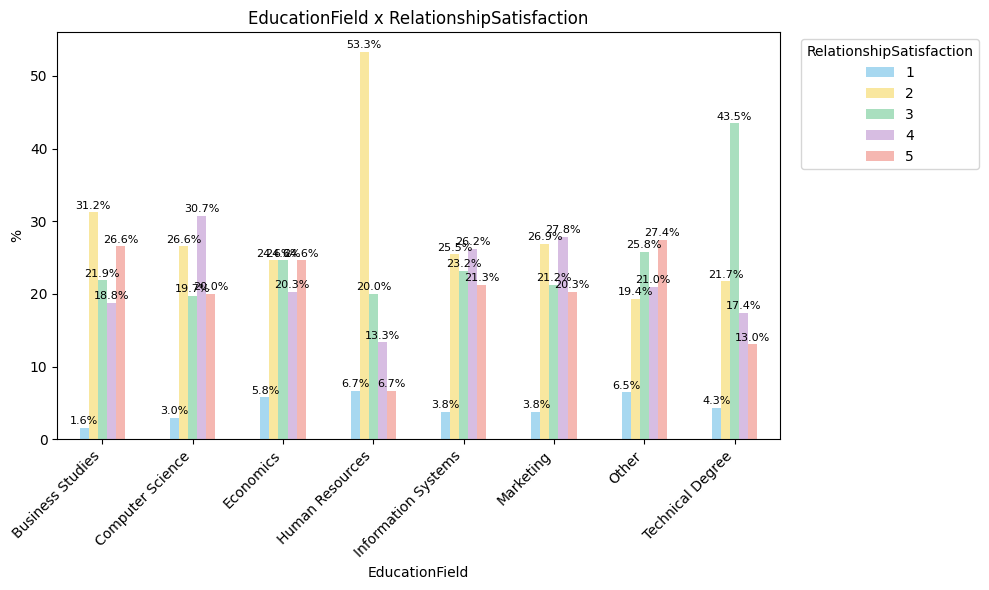

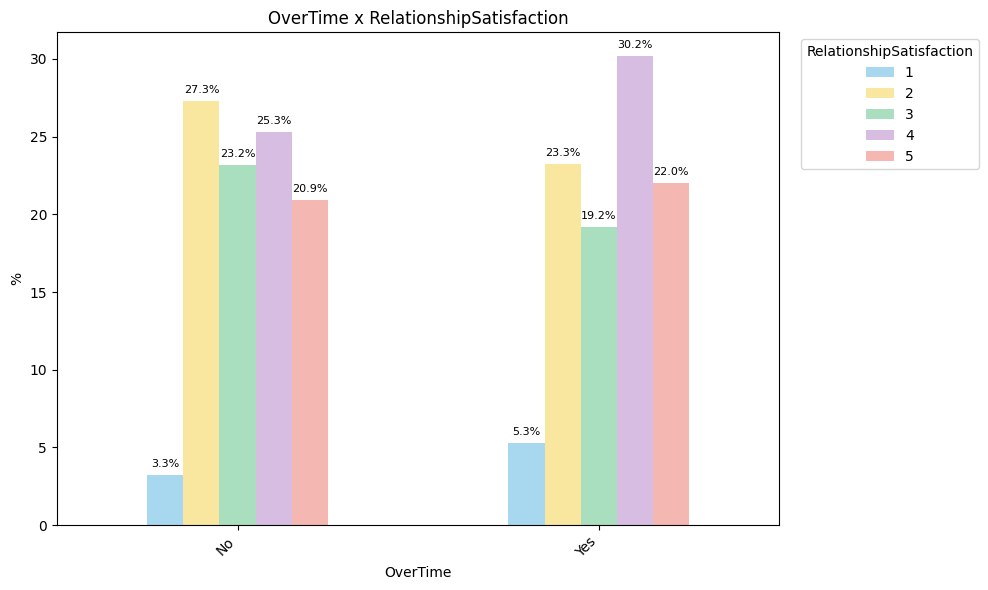

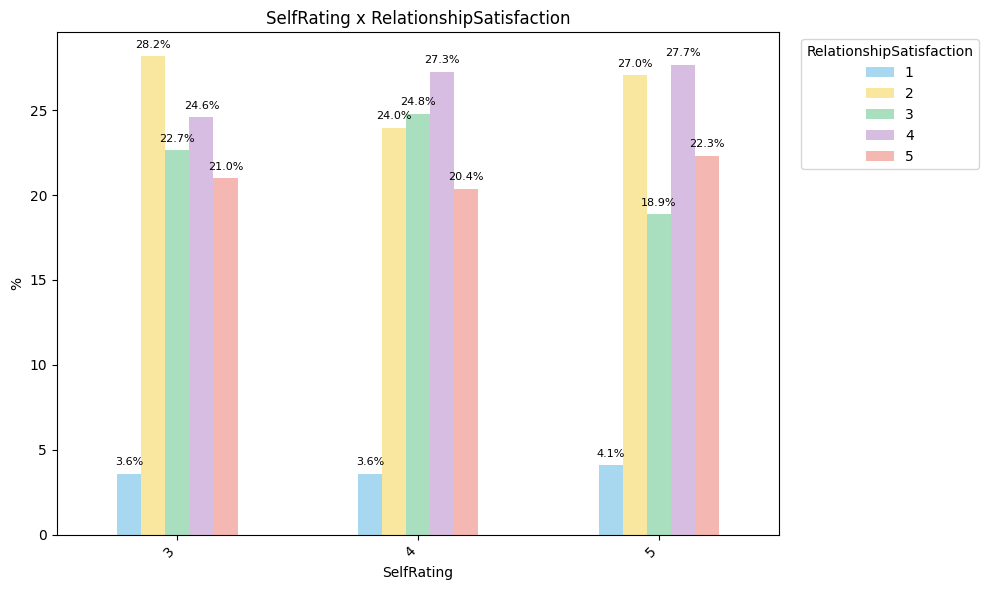

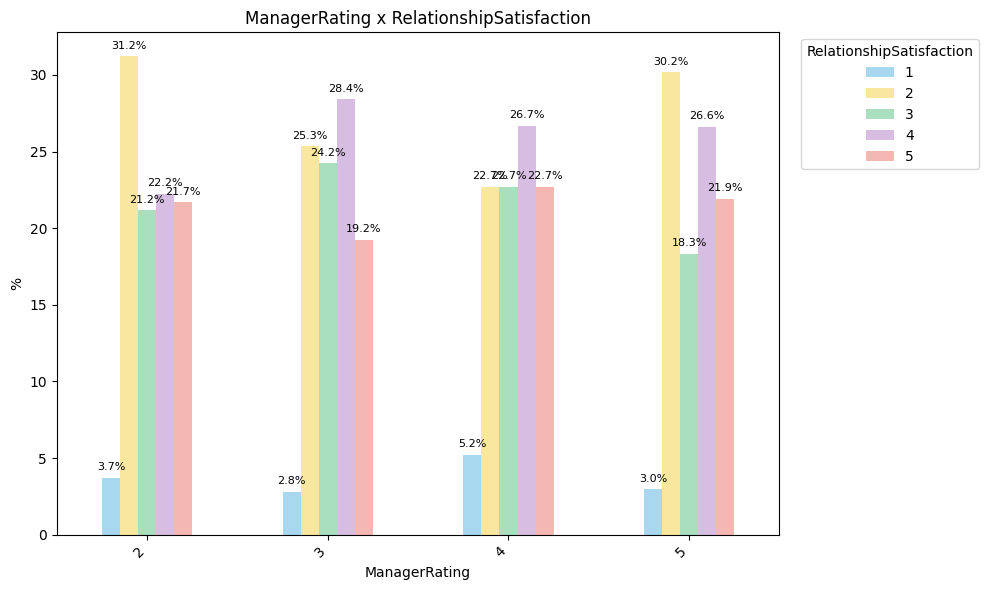

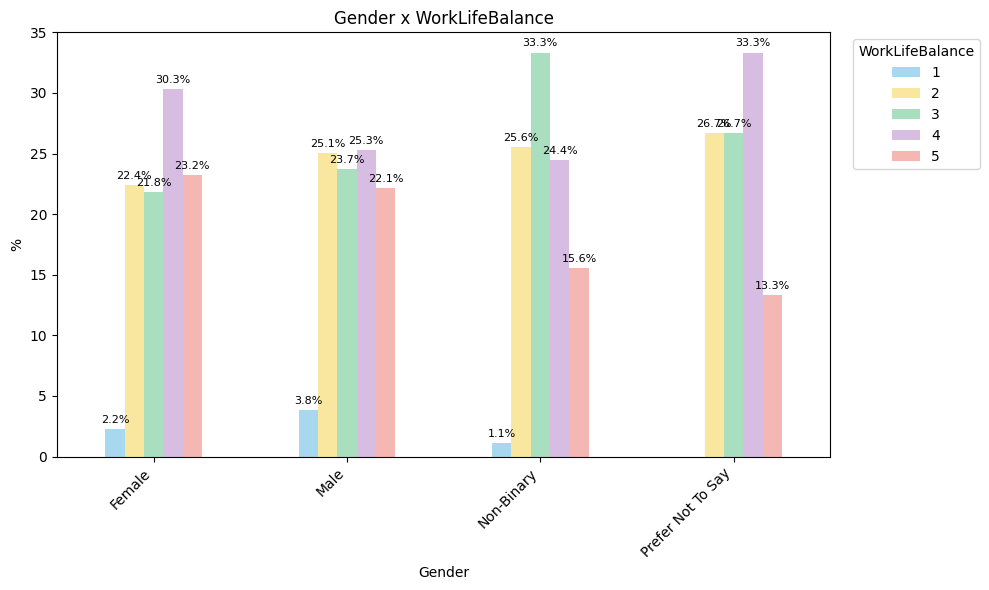

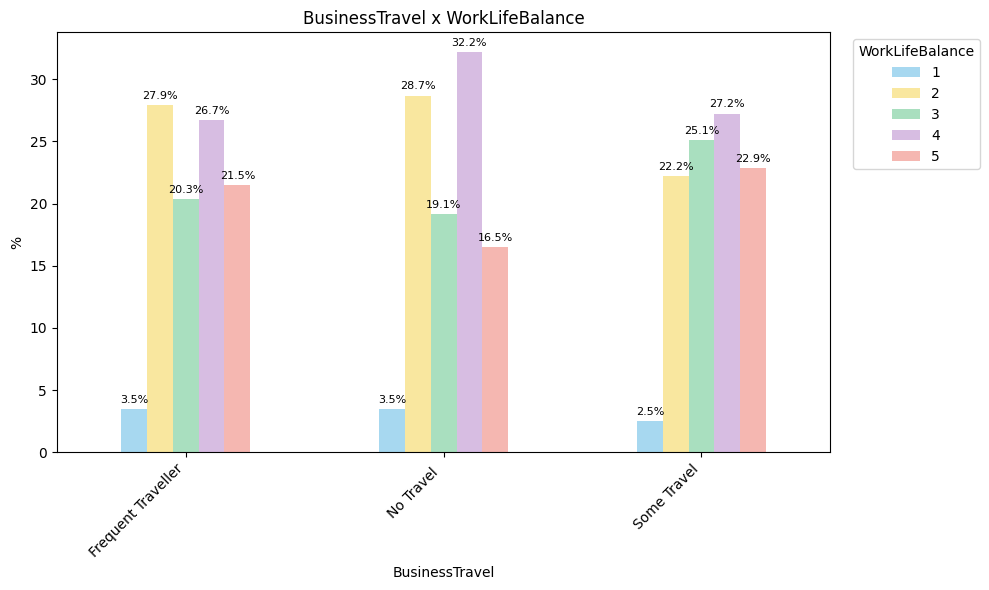

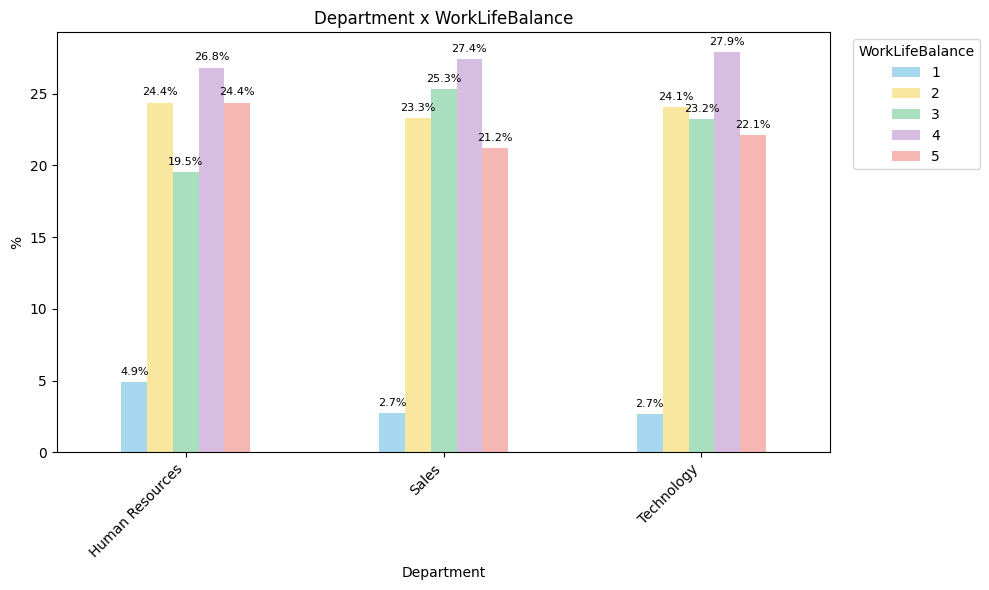

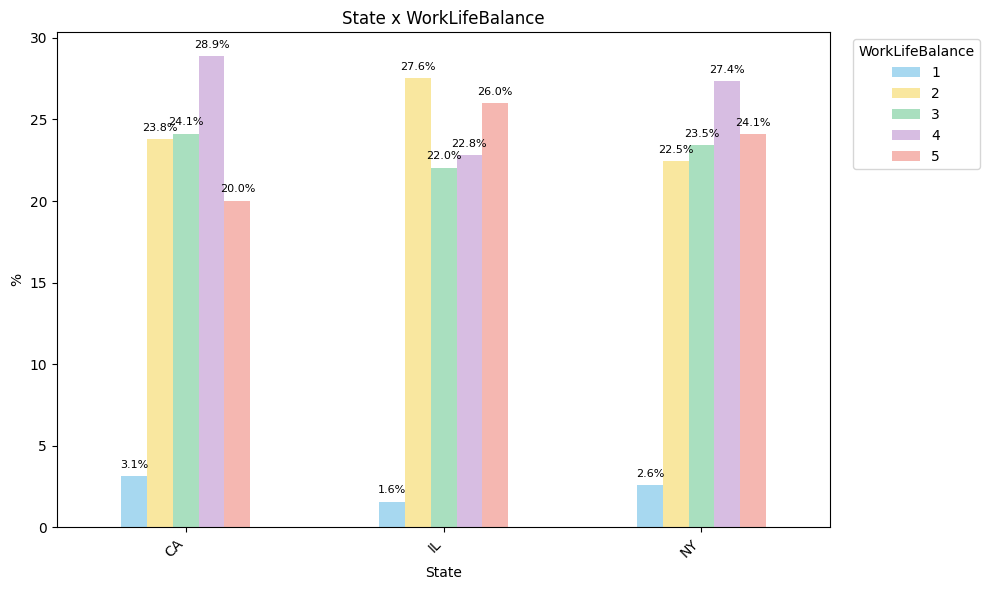

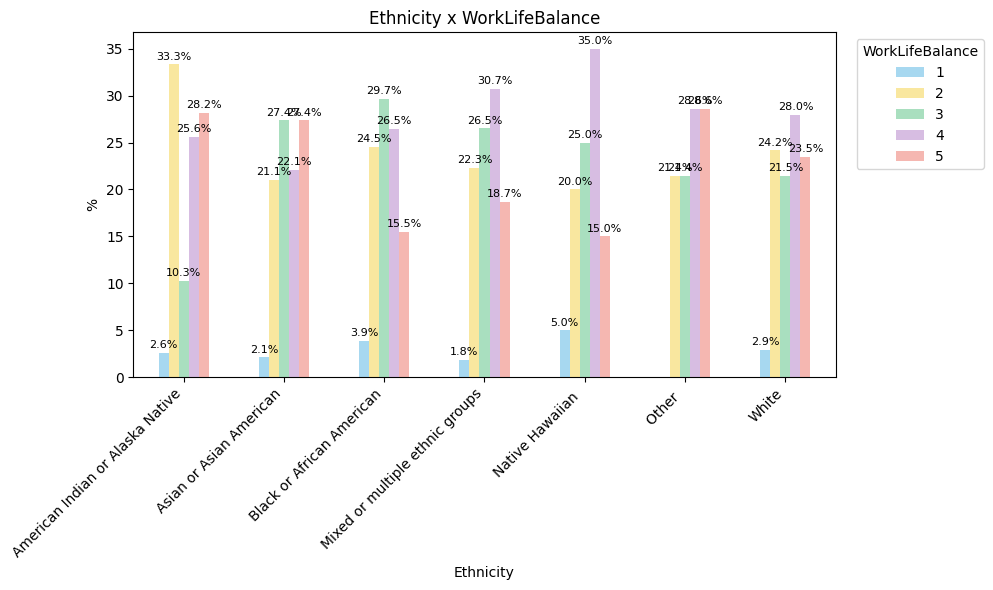

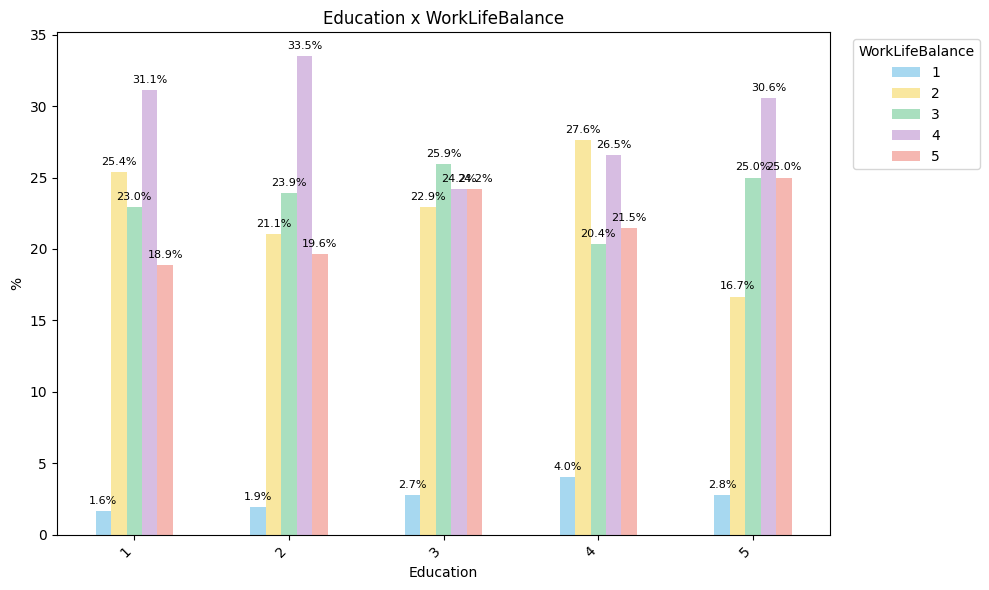

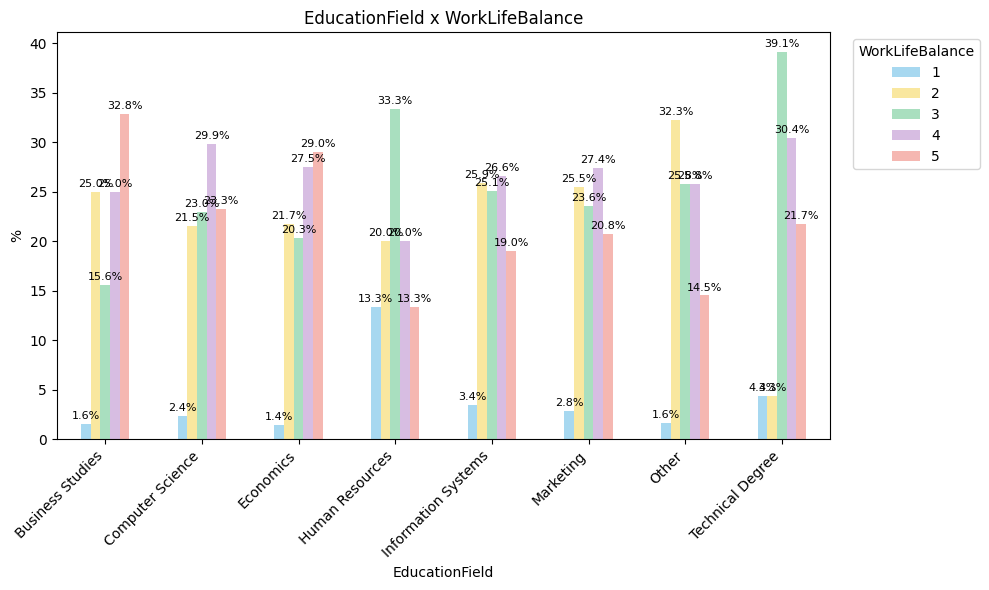

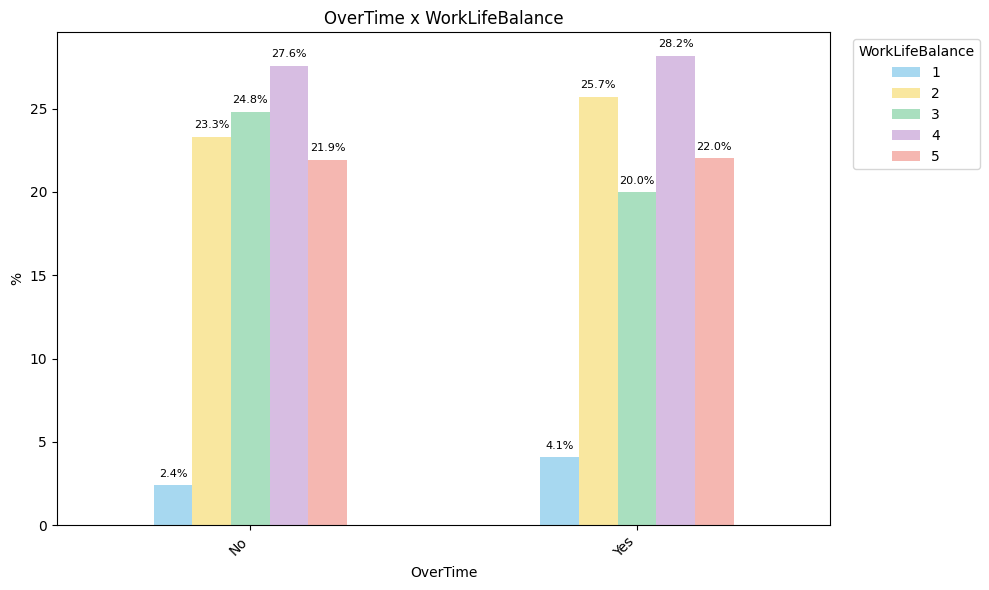

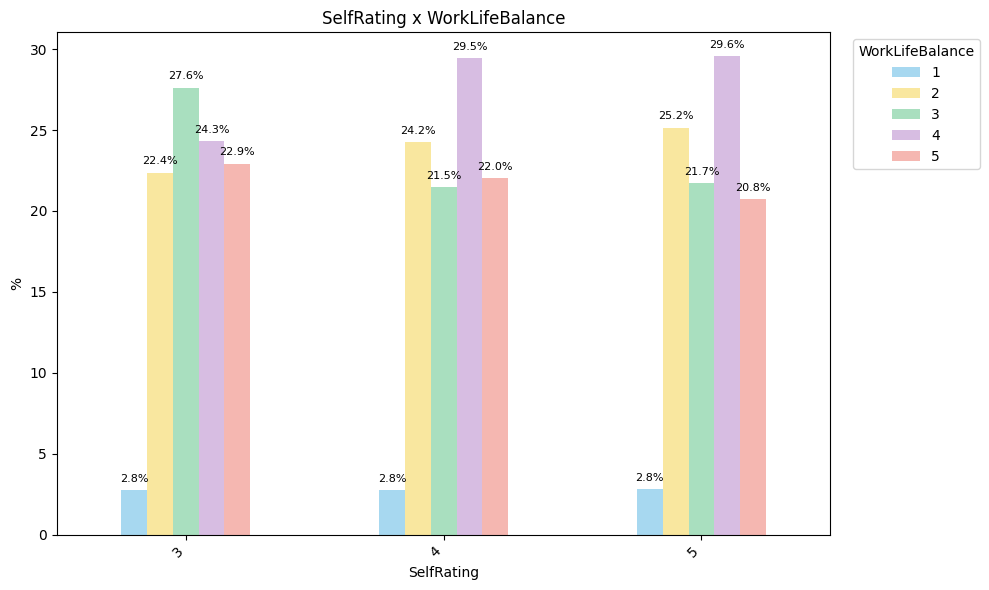

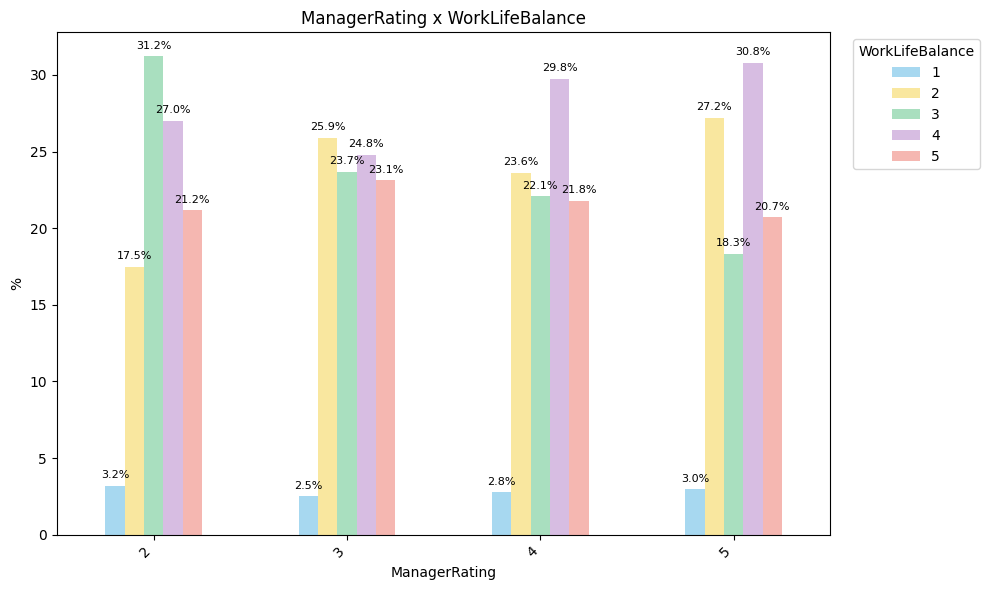

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

df = employee_review_base_atual

target = [
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'SelfRating',
    'ManagerRating'
]

for coluna_target in target:

    for coluna_quali in quali:

        tabela = pd.crosstab(
            df[coluna_quali],
            df[coluna_target],
            normalize='index'
        ) * 100

        ax = tabela.plot(
            kind='bar',
            figsize=(10, 6),
            color=['#A7D8F0',
    '#F9E79F',
    '#A9DFBF',
    '#D7BDE2',
    '#F5B7B1'
]
        )

        plt.title(f'{coluna_quali} x {coluna_target}')
        plt.ylabel('%')
        plt.xlabel(coluna_quali)

        plt.xticks(
            rotation=45,
            ha='right'
        )

        plt.legend(
            title=coluna_target,
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )

        for p in ax.patches:

            altura = p.get_height()

            if altura > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    altura + 0.5,
                    f'{altura:.1f}%',
                    ha='center',
                    fontsize=8
                )

        plt.tight_layout()

        plt.show()

        plt.close()



**Teste Qui-Quadrado de Independência**

A ideia do teste é verificar se existe associação entre duas variáveis categóricas, comparando as frequências observadas com as frequências esperadas caso elas fossem independentes.

In [24]:
from scipy.stats import chi2_contingency
import pandas as pd

df = employee_review_base_atual

target = 'JobSatisfaction'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'SelfRating',
    'ManagerRating'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    stat, p, dof, E = chi2_contingency(tabela)

    print('\n' + '=' * 70)
    print(f'{coluna} × {target}')
    print('=' * 70)

    print('\nTabela de contingência:')
    print(tabela)

    print('\nGraus de liberdade:', dof)

    print('\nFrequências esperadas:')
    print(pd.DataFrame(
        E,
        index=tabela.index,
        columns=tabela.columns
    ).round(2))

    print('\nEstatística Qui-Quadrado:', round(stat, 4))
    print('Valor-p:', round(p, 6))


Gender × JobSatisfaction

Tabela de contingência:
JobSatisfaction     1    2    3    4    5
Gender                                   
Female             18  117  131  130   95
Male               13  106  107  116  105
Non-Binary          1   21   23   23   22
Prefer Not To Say   2    4    3    4    2

Graus de liberdade: 12

Frequências esperadas:
JobSatisfaction        1       2       3       4       5
Gender                                                  
Female             16.01  116.75  124.28  128.52  105.45
Male               14.57  106.29  113.14  117.00   96.00
Non-Binary          2.93   21.40   22.78   23.56   19.33
Prefer Not To Say   0.49    3.57    3.80    3.93    3.22

Estatística Qui-Quadrado: 10.0414
Valor-p: 0.612328

BusinessTravel × JobSatisfaction

Tabela de contingência:
JobSatisfaction      1    2    3    4    5
BusinessTravel                            
Frequent Traveller   5   37   51   47   32
No Travel            3   24   25   35   28
Some Travel         26 

In [25]:
from scipy.stats import chi2_contingency
import pandas as pd

target = 'EnvironmentSatisfaction'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'SelfRating',
    'ManagerRating'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    stat, p, dof, E = chi2_contingency(tabela)

    print('\n' + '=' * 70)
    print(f'{coluna} × {target}')
    print('=' * 70)

    print('\nTabela de contingência:')
    print(tabela)

    print('\nGraus de liberdade:', dof)

    print('\nFrequências esperadas:')
    print(pd.DataFrame(
        E,
        index=tabela.index,
        columns=tabela.columns
    ).round(2))

    print('\nEstatística Qui-Quadrado:', round(stat, 4))
    print('Valor-p:', round(p, 6))


Gender × EnvironmentSatisfaction

Tabela de contingência:
EnvironmentSatisfaction   1   2    3    4    5
Gender                                        
Female                   16  27  171  156  121
Male                     18  16  144  145  124
Non-Binary                4   2   27   27   30
Prefer Not To Say         2   1    7    3    2

Graus de liberdade: 12

Frequências esperadas:
EnvironmentSatisfaction      1      2       3       4       5
Gender                                                       
Female                   18.83  21.65  164.29  155.82  130.40
Male                     17.14  19.71  149.57  141.86  118.71
Non-Binary                3.45   3.97   30.12   28.56   23.90
Prefer Not To Say         0.58   0.66    5.02    4.76    3.98

Estatística Qui-Quadrado: 13.1011
Valor-p: 0.361738

BusinessTravel × EnvironmentSatisfaction

Tabela de contingência:
EnvironmentSatisfaction   1   2    3    4    5
BusinessTravel                                
Frequent Traveller       

In [26]:
from scipy.stats import chi2_contingency
import pandas as pd

target = 'WorkLifeBalance'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'SelfRating',
    'ManagerRating'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    stat, p, dof, E = chi2_contingency(tabela)

    print('\n' + '=' * 70)
    print(f'{coluna} × {target}')
    print('=' * 70)

    print('\nTabela de contingência:')
    print(tabela)

    print('\nGraus de liberdade:', dof)

    print('\nFrequências esperadas:')
    print(pd.DataFrame(
        E,
        index=tabela.index,
        columns=tabela.columns
    ).round(2))

    print('\nEstatística Qui-Quadrado:', round(stat, 4))
    print('Valor-p:', round(p, 6))


Gender × WorkLifeBalance

Tabela de contingência:
WorkLifeBalance     1    2    3    4    5
Gender                                   
Female             11  110  107  149  114
Male               17  112  106  113   99
Non-Binary          1   23   30   22   14
Prefer Not To Say   0    4    4    5    2

Graus de liberdade: 12

Frequências esperadas:
WorkLifeBalance        1       2       3       4       5
Gender                                                  
Female             13.65  117.22  116.28  136.05  107.80
Male               12.43  106.71  105.86  123.86   98.14
Non-Binary          2.50   21.49   21.31   24.94   19.76
Prefer Not To Say   0.42    3.58    3.55    4.16    3.29

Estatística Qui-Quadrado: 13.9675
Valor-p: 0.30279

BusinessTravel × WorkLifeBalance

Tabela de contingência:
WorkLifeBalance      1    2    3    4    5
BusinessTravel                            
Frequent Traveller   6   48   35   46   37
No Travel            4   33   22   37   19
Some Travel         19  

In [27]:
from scipy.stats import chi2_contingency
import pandas as pd

target = 'RelationshipSatisfaction'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'SelfRating',
    'ManagerRating'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    stat, p, dof, E = chi2_contingency(tabela)

    print('\n' + '=' * 70)
    print(f'{coluna} × {target}')
    print('=' * 70)

    print('\nTabela de contingência:')
    print(tabela)

    print('\nGraus de liberdade:', dof)

    print('\nFrequências esperadas:')
    print(pd.DataFrame(
        E,
        index=tabela.index,
        columns=tabela.columns
    ).round(2))

    print('\nEstatística Qui-Quadrado:', round(stat, 4))
    print('Valor-p:', round(p, 6))


Gender × RelationshipSatisfaction

Tabela de contingência:
RelationshipSatisfaction   1    2    3    4    5
Gender                                          
Female                    15  123  110  141  102
Male                      21  116   99  109  102
Non-Binary                 2   32   20   23   13
Prefer Not To Say          1    4    3    3    4

Graus de liberdade: 12

Frequências esperadas:
RelationshipSatisfaction      1       2       3       4       5
Gender                                                         
Female                    18.36  129.46  109.22  129.93  104.04
Male                      16.71  117.86   99.43  118.29   94.71
Non-Binary                 3.37   23.73   20.02   23.82   19.07
Prefer Not To Say          0.56    3.95    3.34    3.97    3.18

Estatística Qui-Quadrado: 10.569
Valor-p: 0.566175

BusinessTravel × RelationshipSatisfaction

Tabela de contingência:
RelationshipSatisfaction   1    2    3    4    5
BusinessTravel                               

# **Rating**

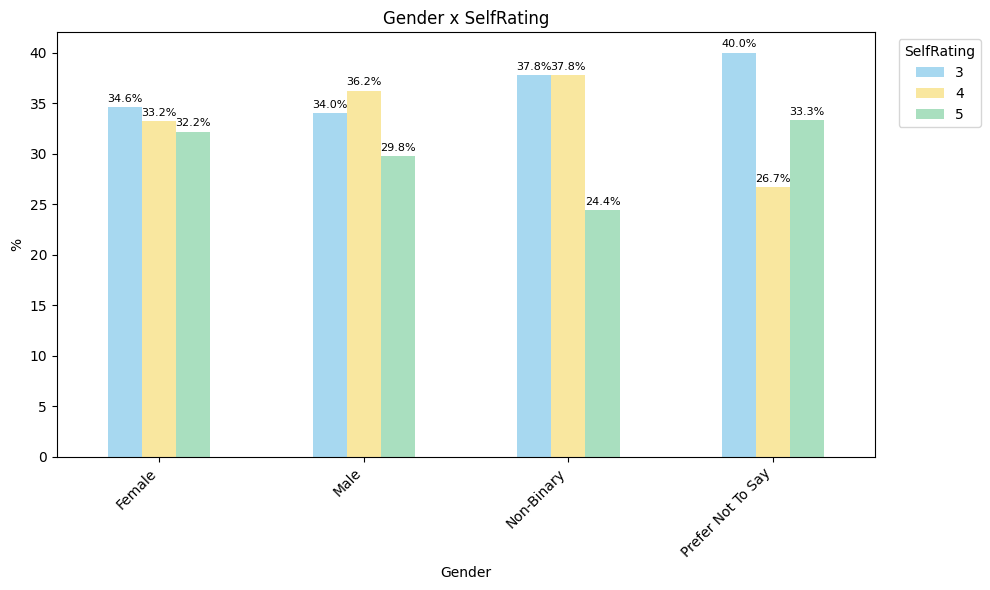

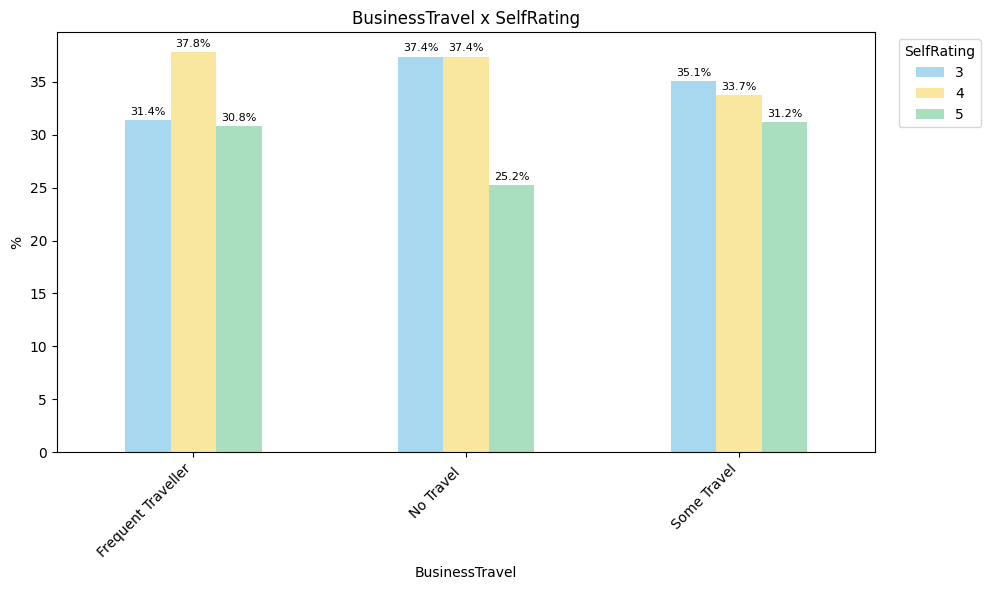

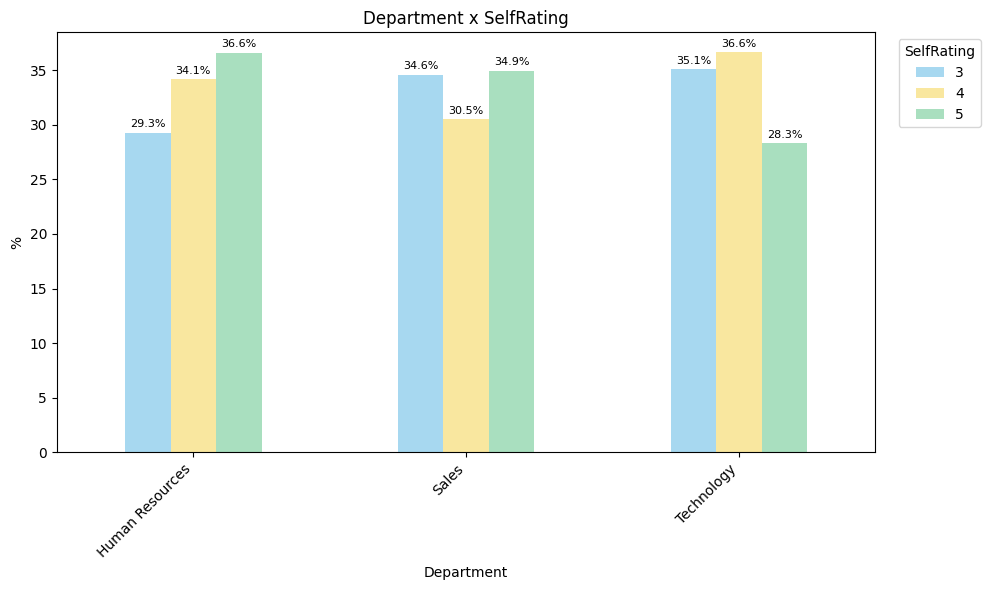

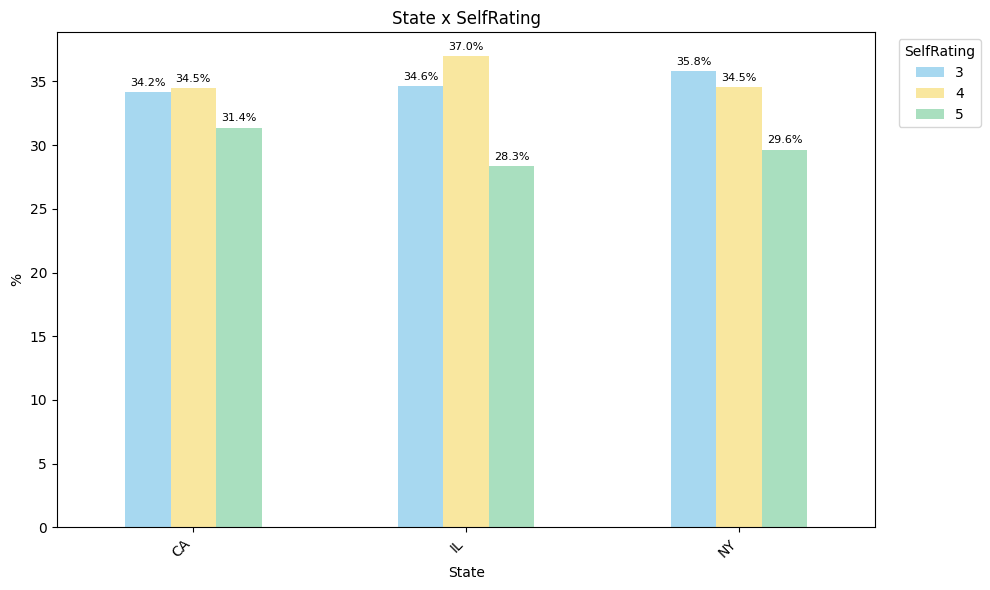

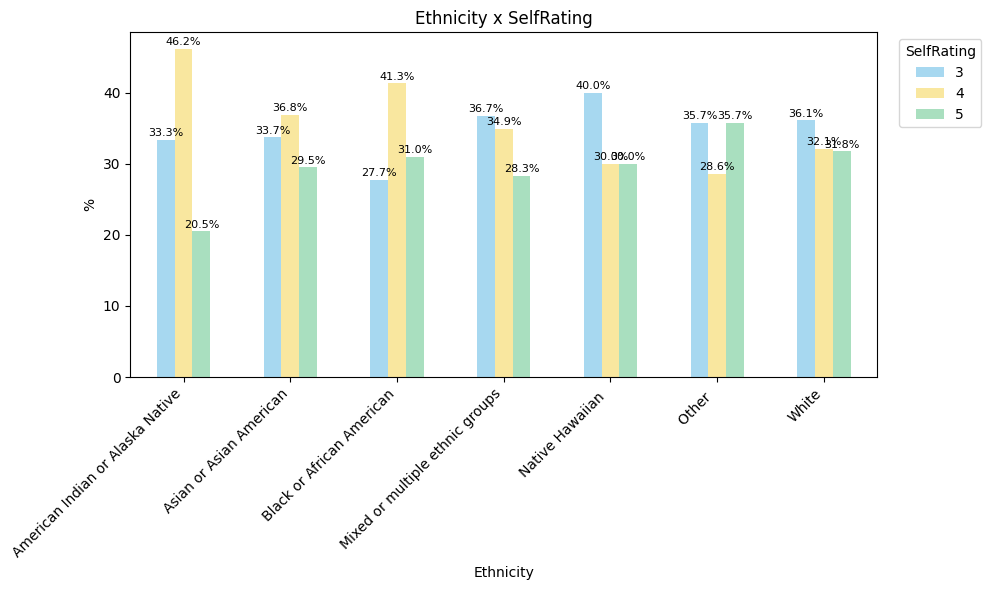

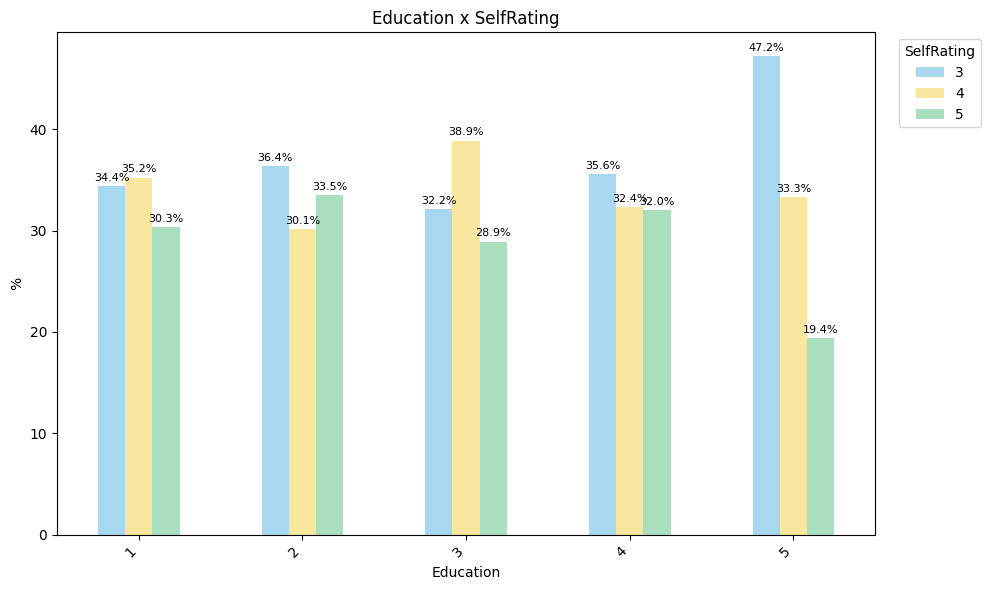

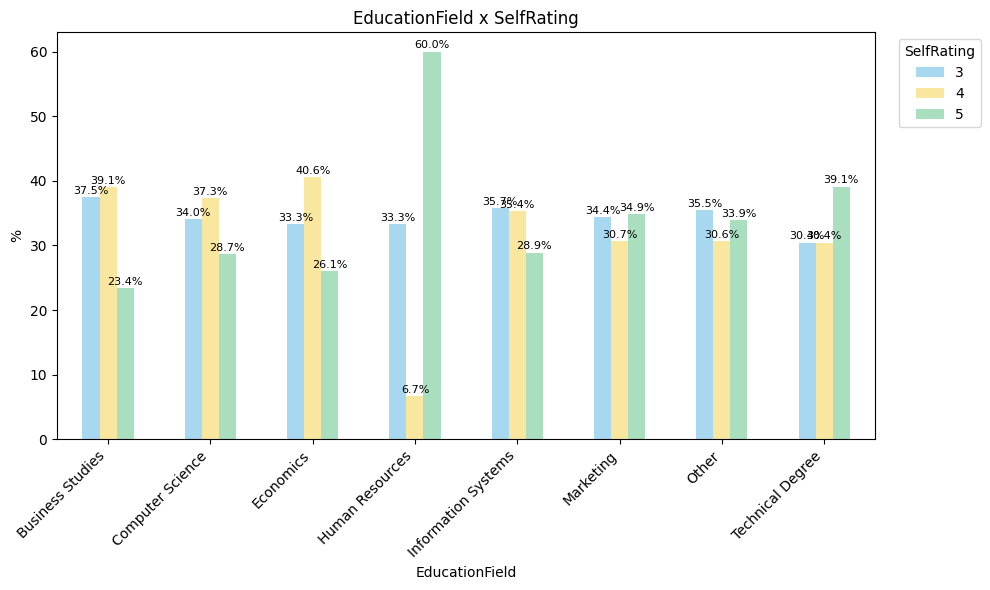

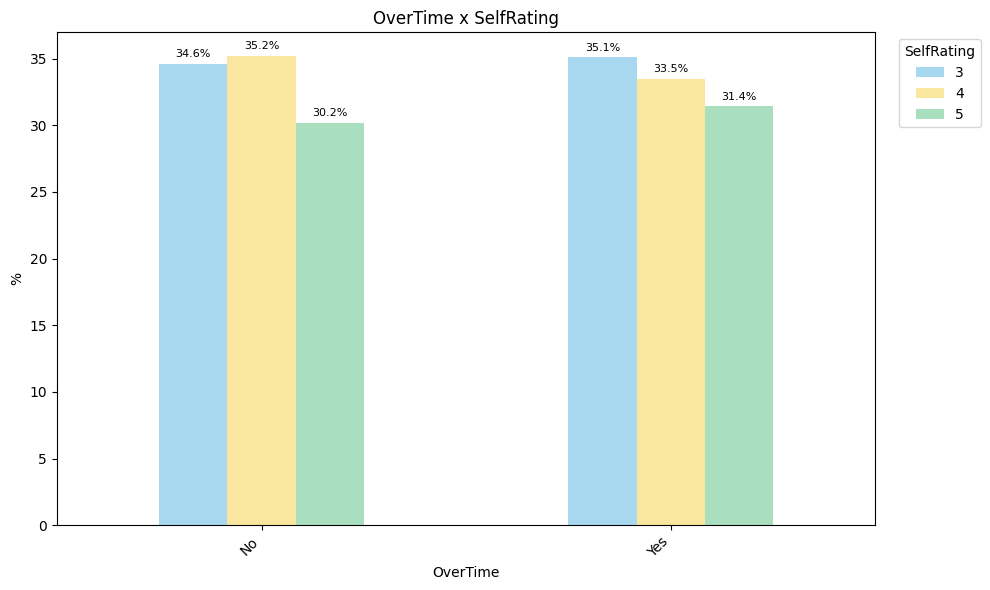

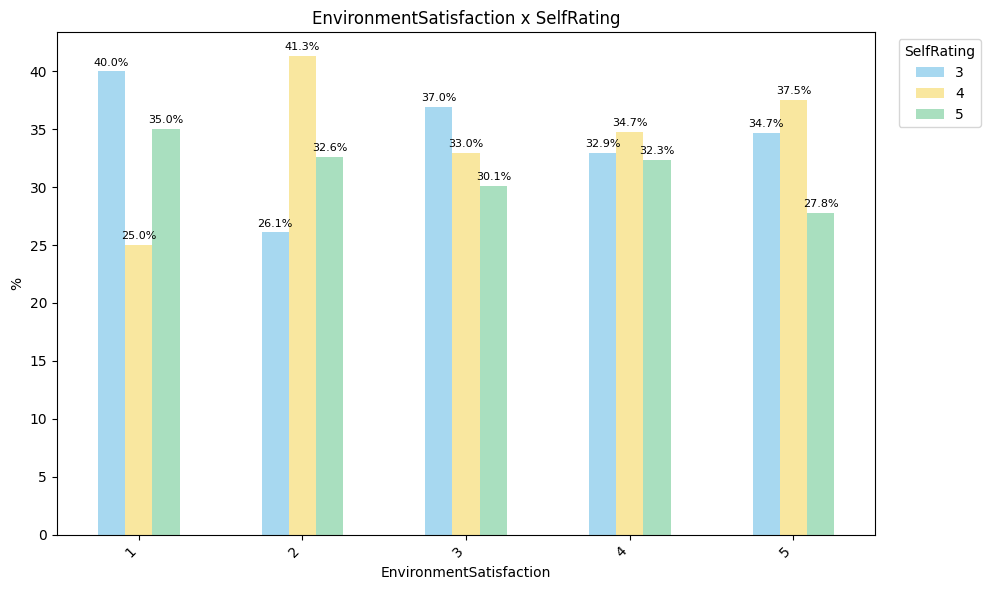

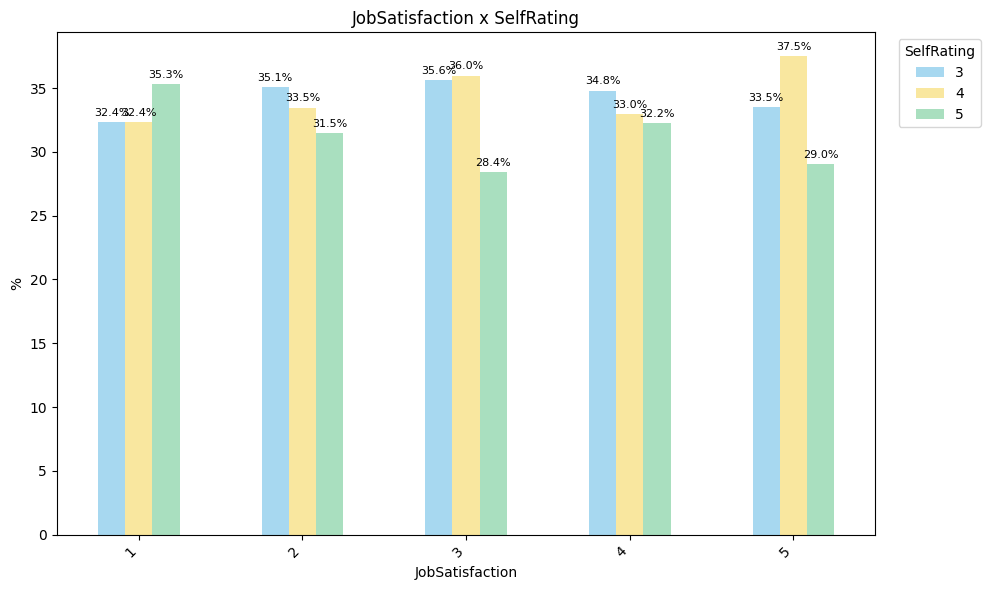

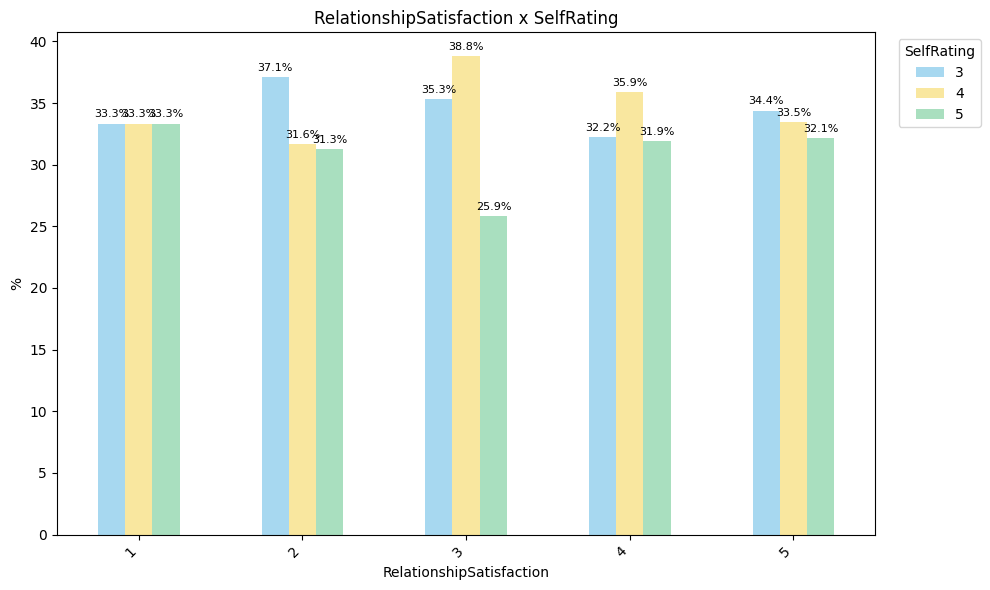

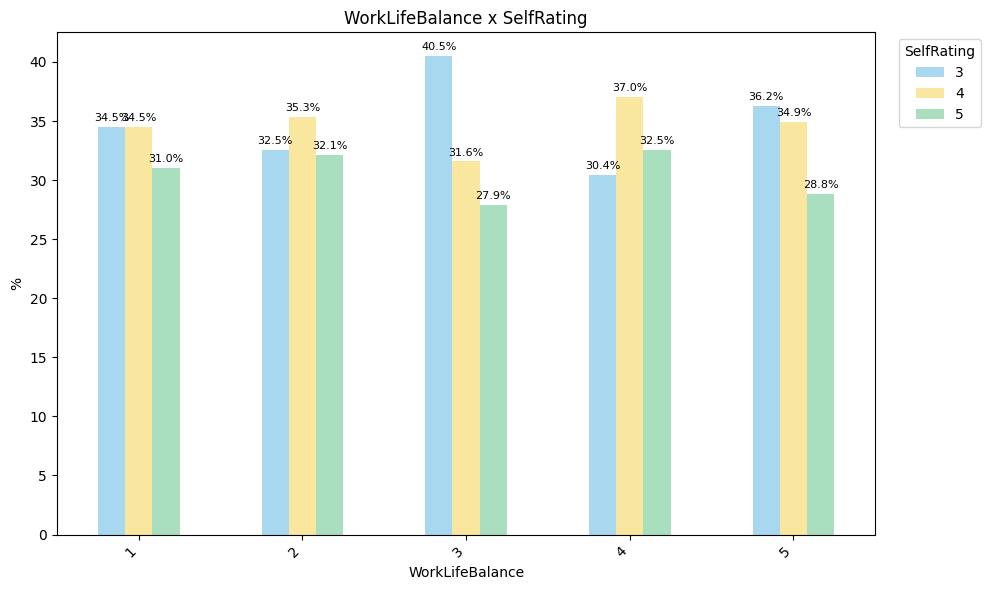

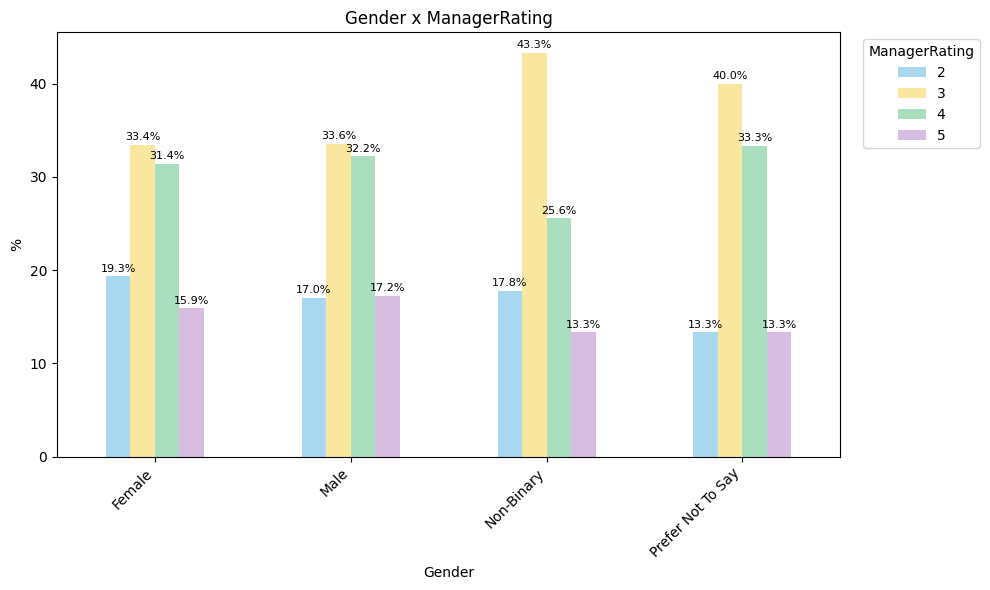

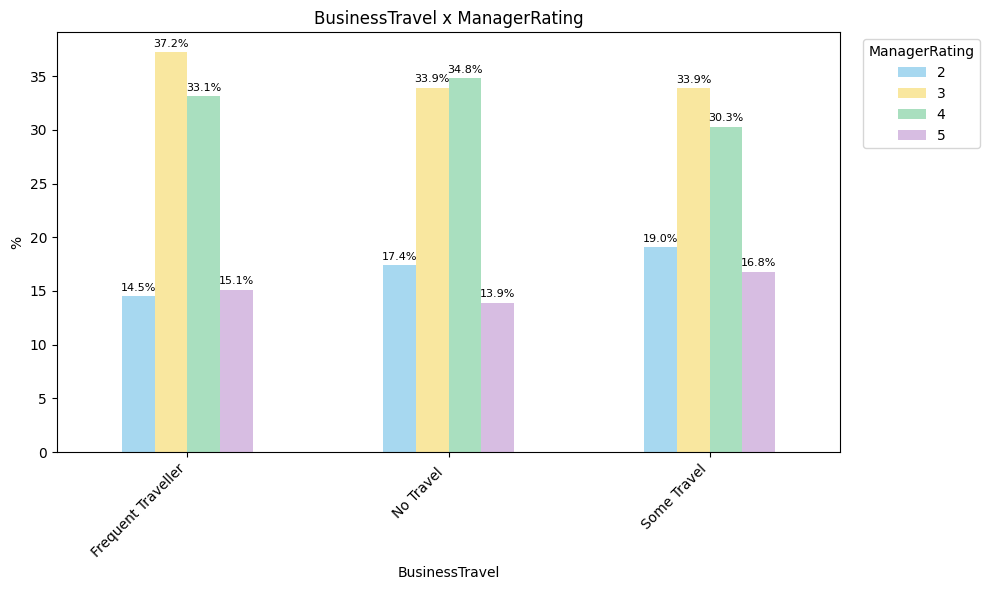

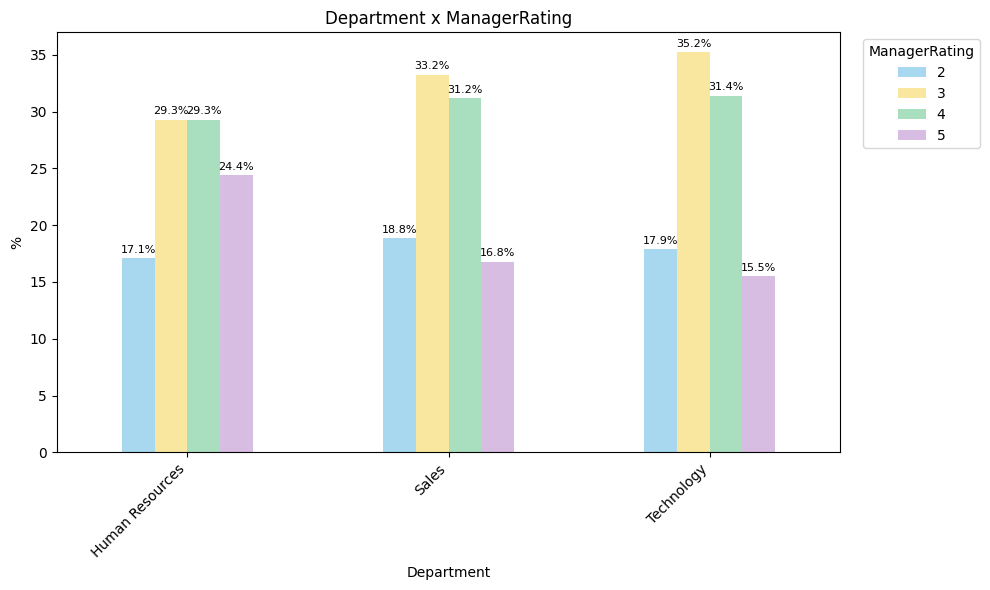

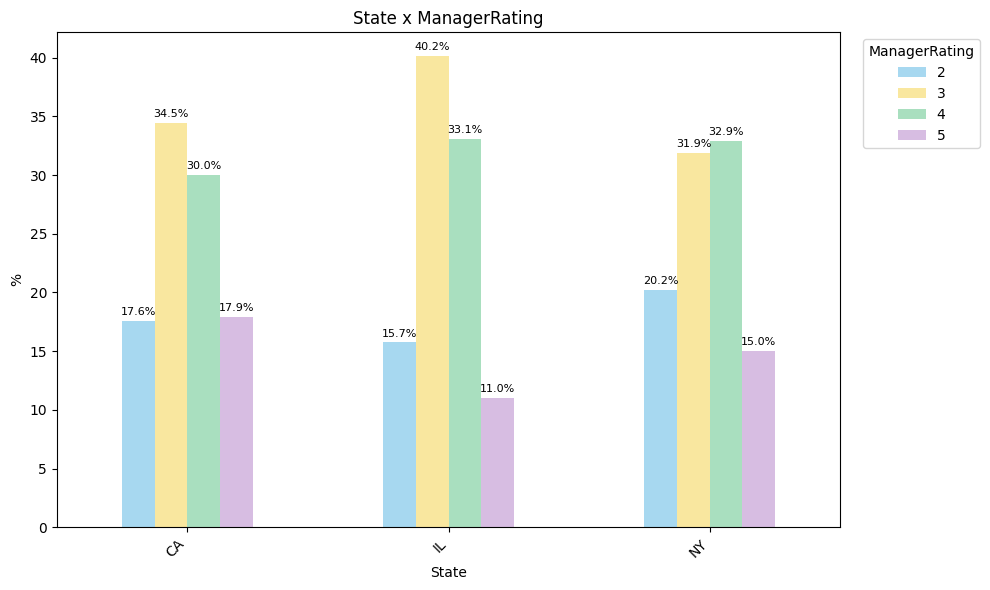

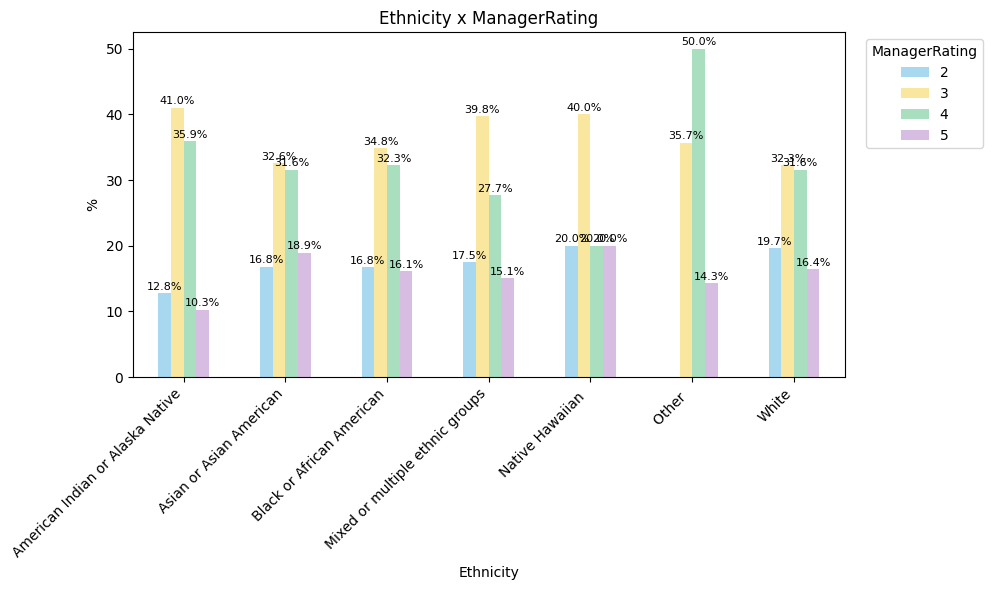

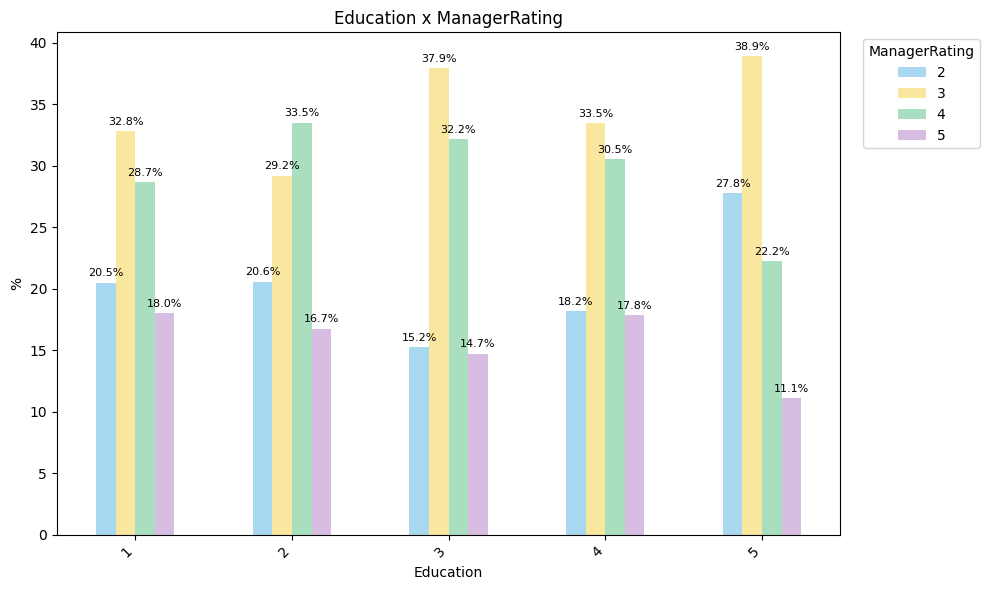

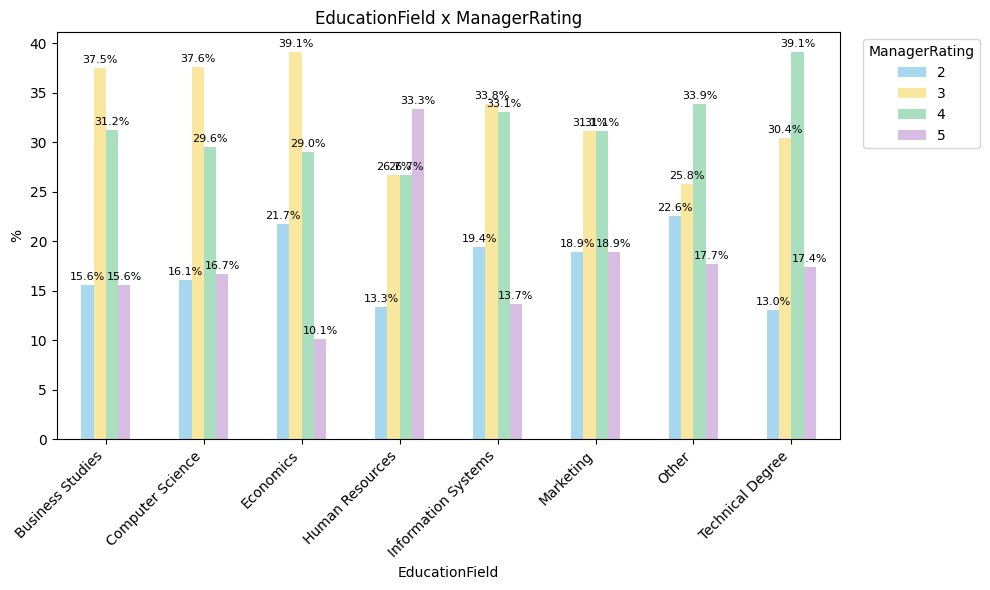

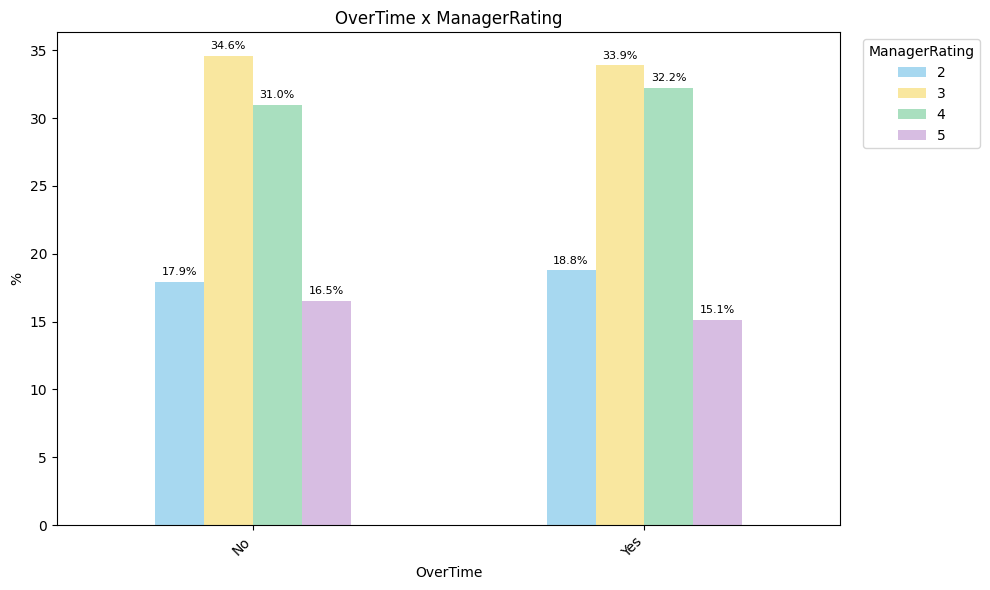

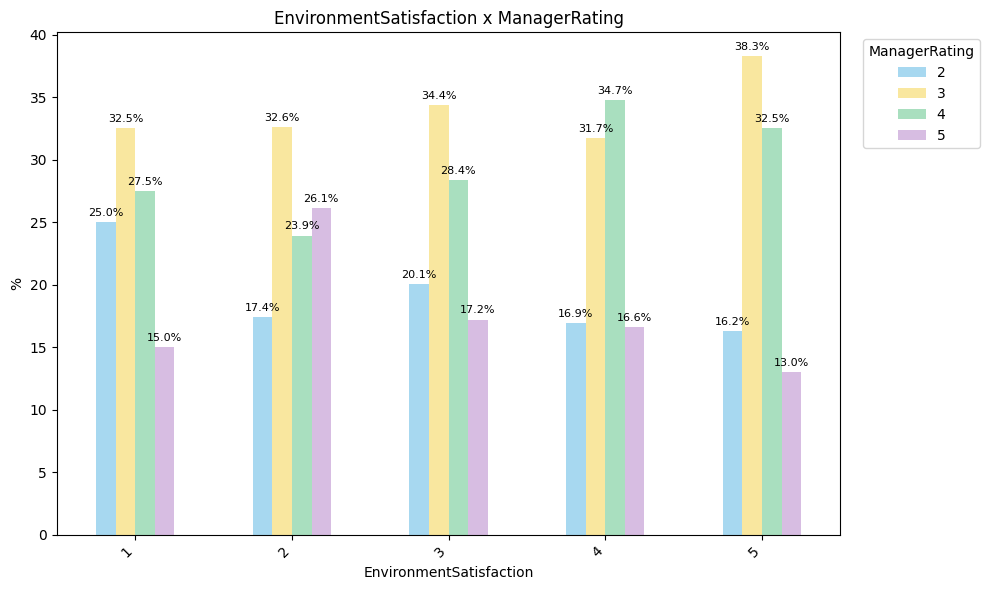

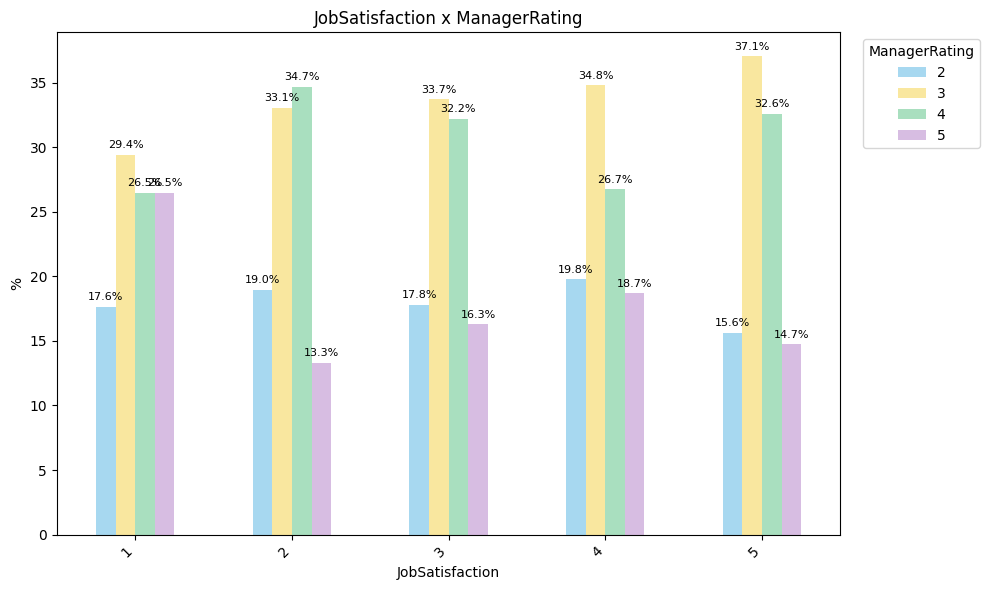

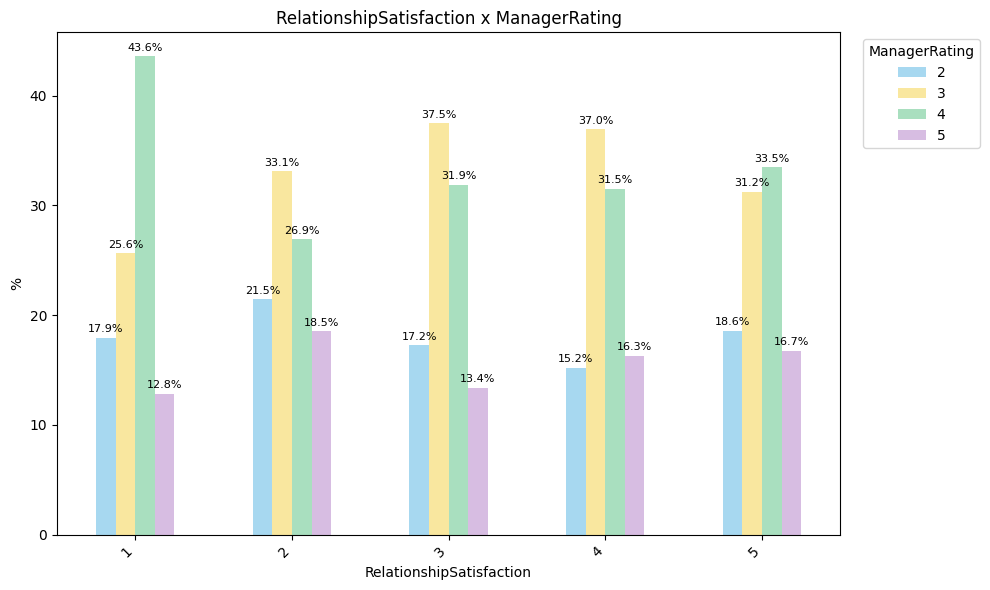

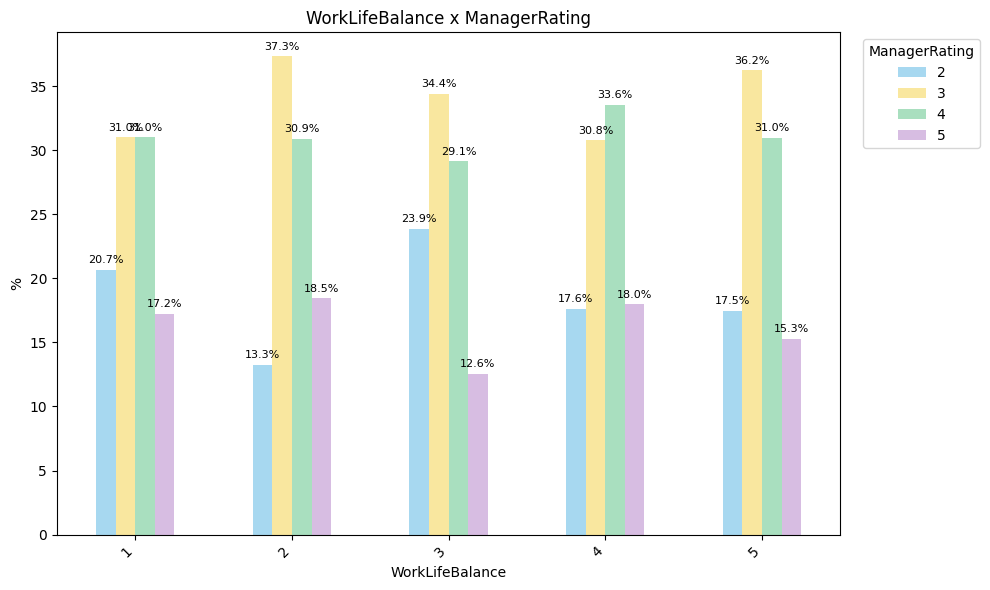

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

df = employee_review_base_atual

target = [
        'SelfRating',
    'ManagerRating'
]

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

for coluna_target in target:

    for coluna_quali in quali:

        tabela = pd.crosstab(
            df[coluna_quali],
            df[coluna_target],
            normalize='index'
        ) * 100

        ax = tabela.plot(
            kind='bar',
            figsize=(10, 6),
            color=['#A7D8F0',
    '#F9E79F',
    '#A9DFBF',
    '#D7BDE2',
    '#F5B7B1'
]
        )

        plt.title(f'{coluna_quali} x {coluna_target}')
        plt.ylabel('%')
        plt.xlabel(coluna_quali)

        plt.xticks(
            rotation=45,
            ha='right'
        )

        plt.legend(
            title=coluna_target,
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )

        for p in ax.patches:

            altura = p.get_height()

            if altura > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    altura + 0.5,
                    f'{altura:.1f}%',
                    ha='center',
                    fontsize=8
                )

        plt.tight_layout()

        plt.show()

        plt.close()



In [29]:
from scipy.stats import chi2_contingency
import pandas as pd

target = 'ManagerRating'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
     'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    stat, p, dof, E = chi2_contingency(tabela)

    print('\n' + '=' * 70)
    print(f'{coluna} × {target}')
    print('=' * 70)

    print('\nTabela de contingência:')
    print(tabela)

    print('\nGraus de liberdade:', dof)

    print('\nFrequências esperadas:')
    print(pd.DataFrame(
        E,
        index=tabela.index,
        columns=tabela.columns
    ).round(2))

    print('\nEstatística Qui-Quadrado:', round(stat, 4))
    print('Valor-p:', round(p, 6))


Gender × ManagerRating

Tabela de contingência:
ManagerRating       2    3    4   5
Gender                             
Female             95  164  154  78
Male               76  150  144  77
Non-Binary         16   39   23  12
Prefer Not To Say   2    6    5   2

Graus de liberdade: 9

Frequências esperadas:
ManagerRating          2       3       4      5
Gender                                         
Female             88.97  169.00  153.47  79.56
Male               81.00  153.86  139.71  72.43
Non-Binary         16.31   30.98   28.13  14.58
Prefer Not To Say   2.72    5.16    4.69   2.43

Estatística Qui-Quadrado: 5.3128
Valor-p: 0.806236

BusinessTravel × ManagerRating

Tabela de contingência:
ManagerRating         2    3    4    5
BusinessTravel                        
Frequent Traveller   25   64   57   26
No Travel            20   39   40   16
Some Travel         144  256  229  127

Graus de liberdade: 6

Frequências esperadas:
ManagerRating            2       3       4       

In [30]:
from scipy.stats import chi2_contingency
import pandas as pd

target = 'SelfRating'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
     'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    stat, p, dof, E = chi2_contingency(tabela)

    print('\n' + '=' * 70)
    print(f'{coluna} × {target}')
    print('=' * 70)

    print('\nTabela de contingência:')
    print(tabela)

    print('\nGraus de liberdade:', dof)

    print('\nFrequências esperadas:')
    print(pd.DataFrame(
        E,
        index=tabela.index,
        columns=tabela.columns
    ).round(2))

    print('\nEstatística Qui-Quadrado:', round(stat, 4))
    print('Valor-p:', round(p, 6))


Gender × SelfRating

Tabela de contingência:
SelfRating           3    4    5
Gender                          
Female             170  163  158
Male               152  162  133
Non-Binary          34   34   22
Prefer Not To Say    6    4    5

Graus de liberdade: 6

Frequências esperadas:
SelfRating              3       4       5
Gender                                   
Female             170.41  170.88  149.70
Male               155.14  155.57  136.29
Non-Binary          31.24   31.32   27.44
Prefer Not To Say    5.21    5.22    4.57

Estatística Qui-Quadrado: 3.2314
Valor-p: 0.779298

BusinessTravel × SelfRating

Tabela de contingência:
SelfRating            3    4    5
BusinessTravel                   
Frequent Traveller   54   65   53
No Travel            43   43   29
Some Travel         265  255  236

Graus de liberdade: 4

Frequências esperadas:
SelfRating               3       4       5
BusinessTravel                            
Frequent Traveller   59.70   59.86   52.44
No Tr

# **Atrittion**

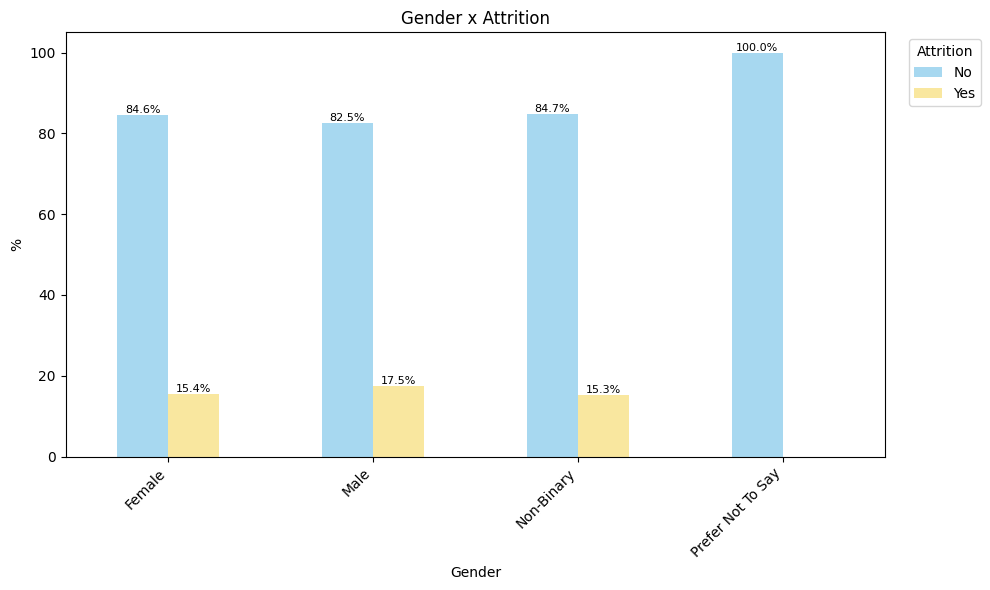

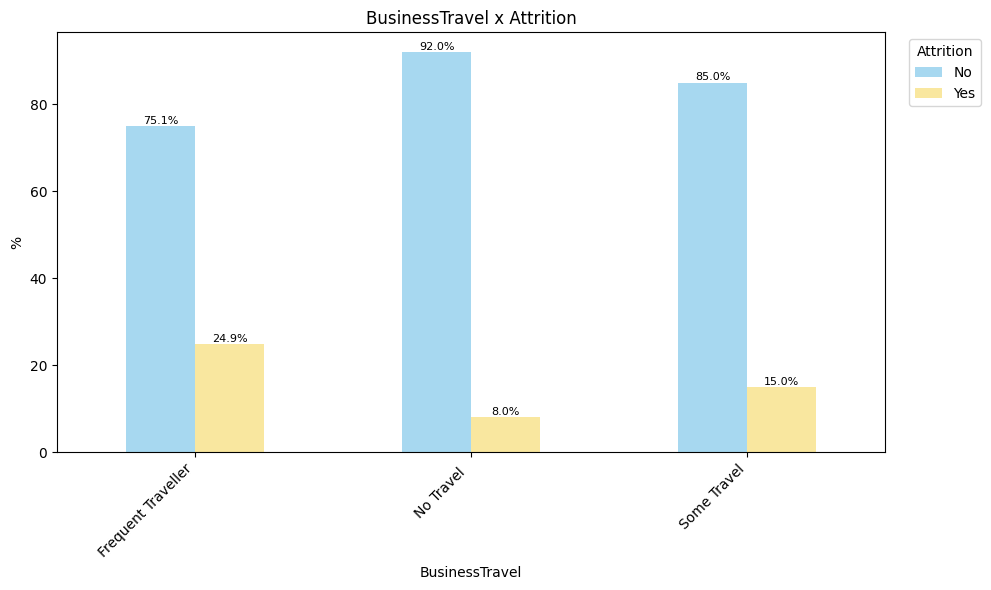

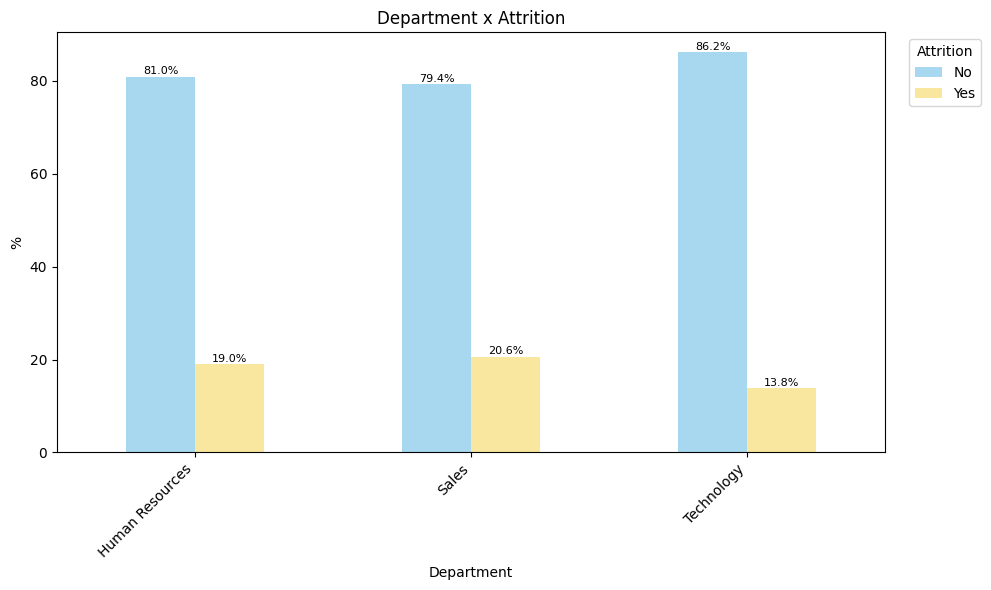

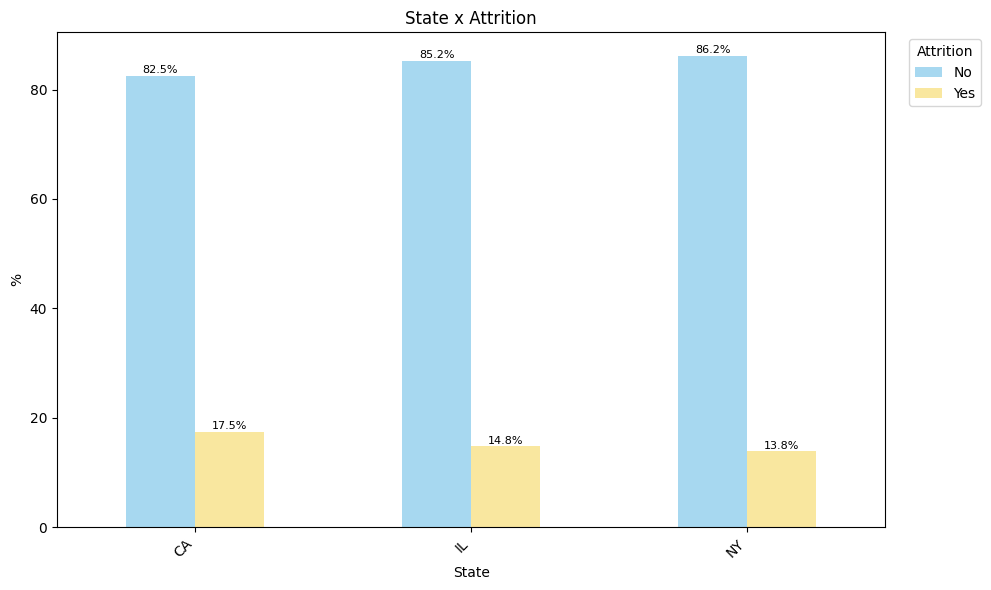

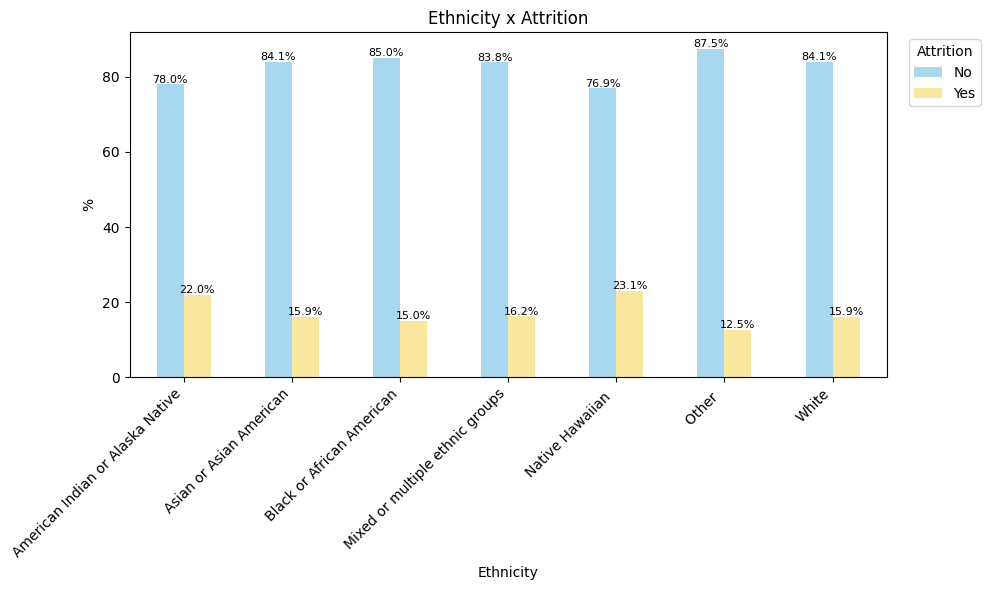

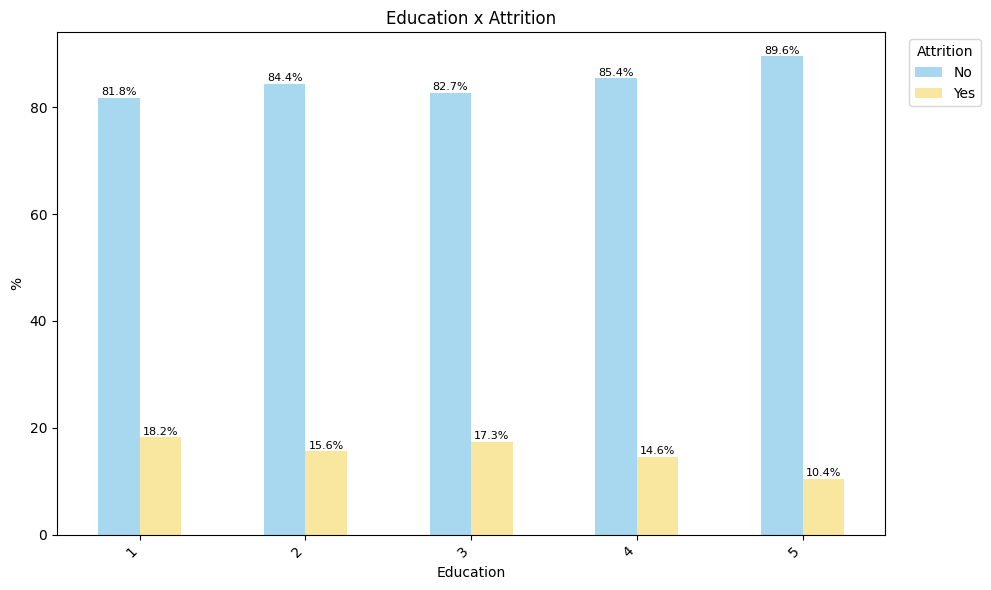

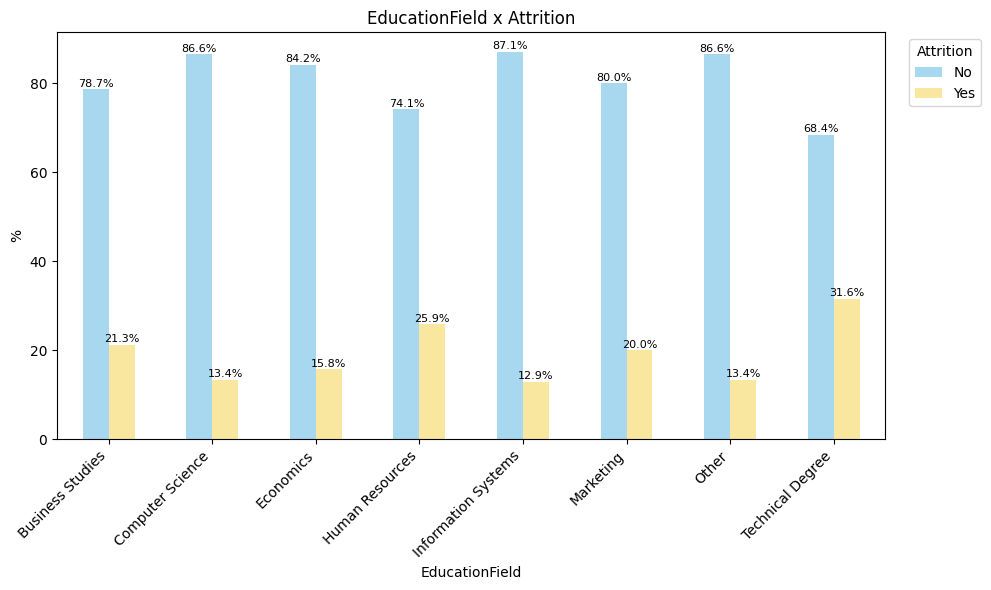

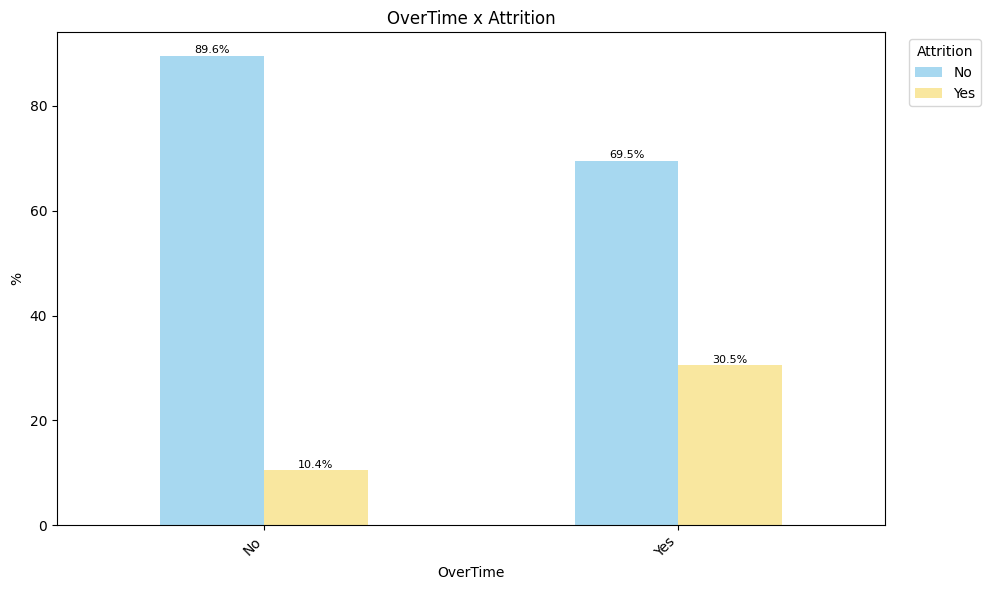

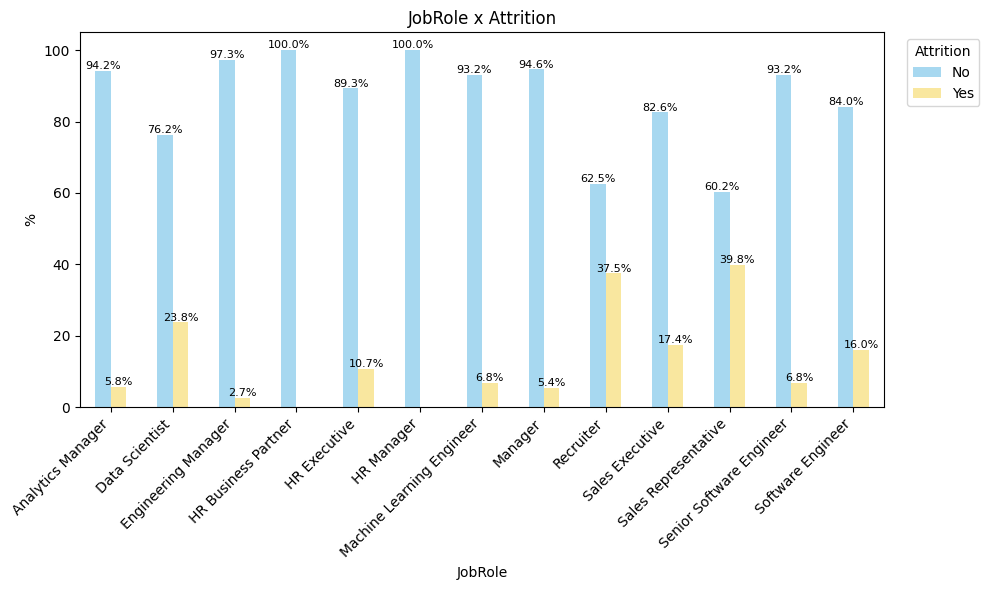

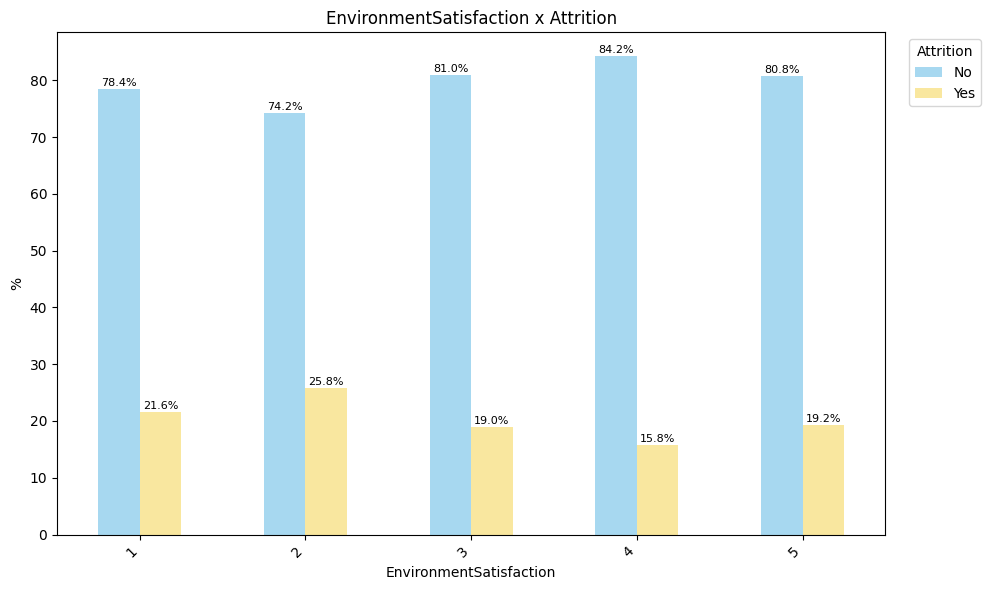

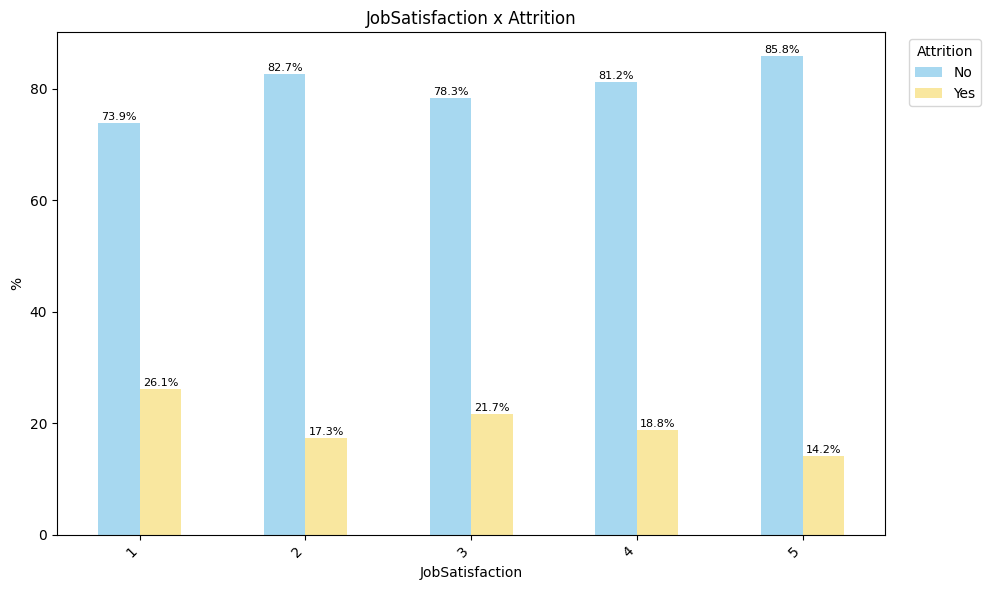

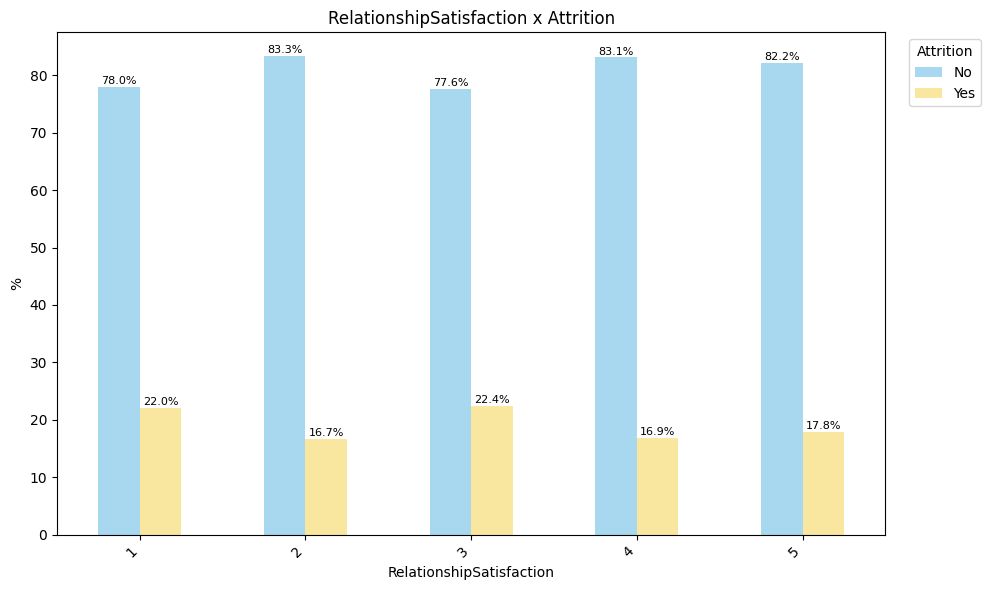

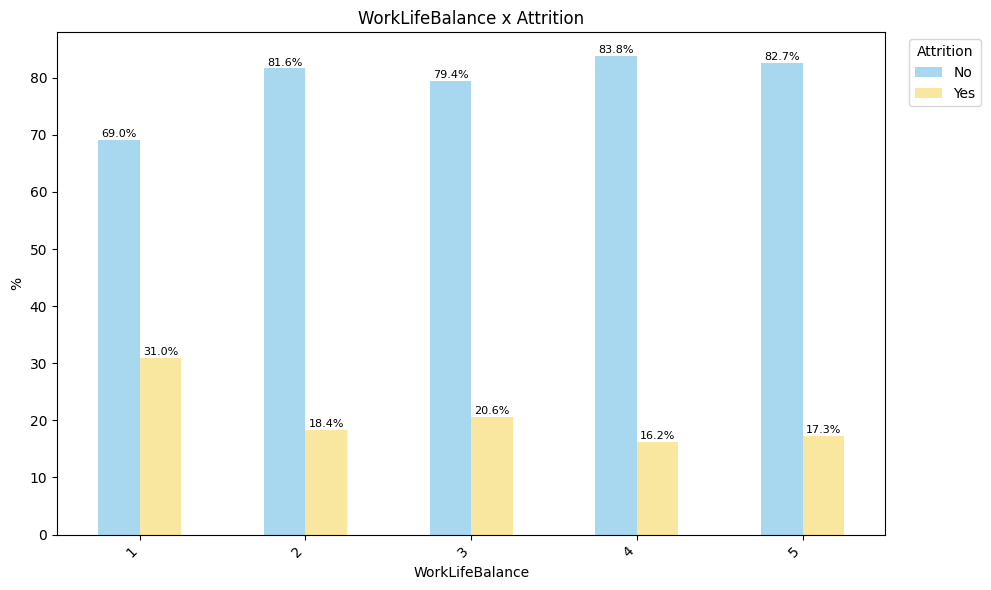

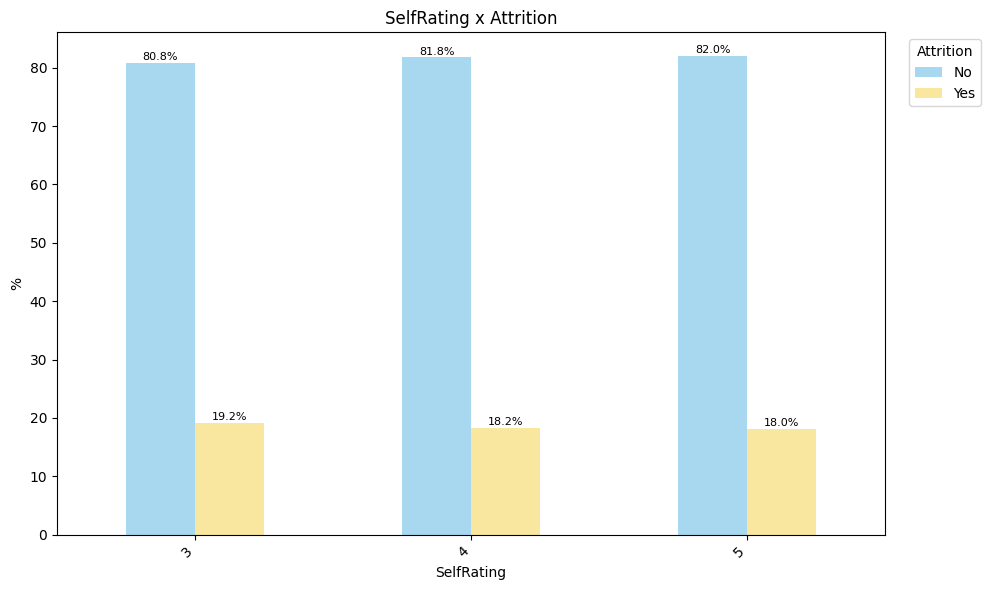

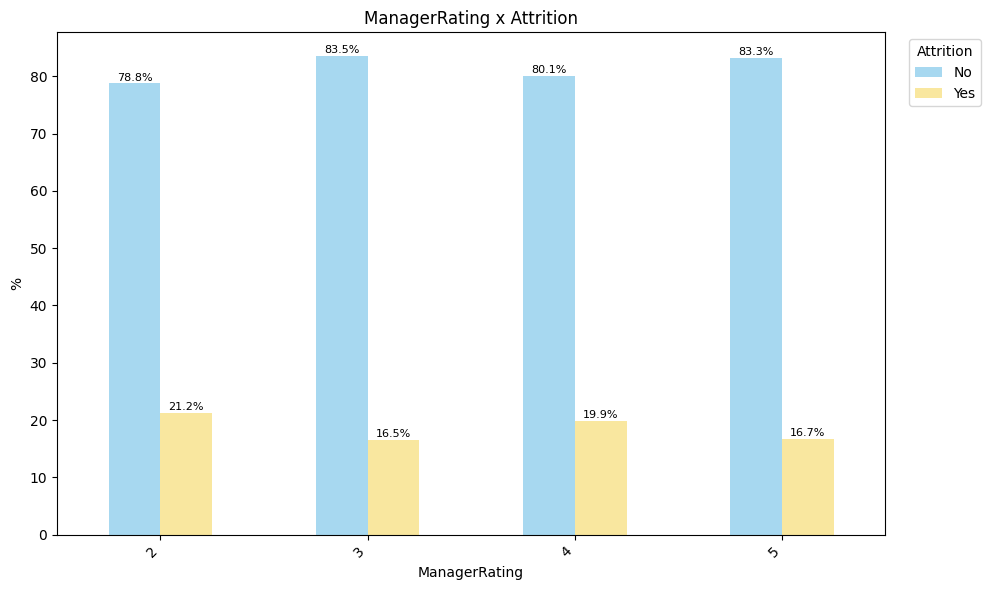

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

df = employee_review

target = ['Attrition']

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'OverTime',
    'JobRole',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'SelfRating',
    'ManagerRating'
]

for coluna_target in target:

    for coluna_quali in quali:

        tabela = pd.crosstab(
            df[coluna_quali],
            df[coluna_target],
            normalize='index'
        ) * 100

        ax = tabela.plot(
            kind='bar',
            figsize=(10, 6),
            color=['#A7D8F0',
    '#F9E79F',
    '#A9DFBF',
    '#D7BDE2',
    '#F5B7B1'
]
        )

        plt.title(f'{coluna_quali} x {coluna_target}')
        plt.ylabel('%')
        plt.xlabel(coluna_quali)

        plt.xticks(
            rotation=45,
            ha='right'
        )

        plt.legend(
            title=coluna_target,
            bbox_to_anchor=(1.02, 1),
            loc='upper left'
        )

        for p in ax.patches:

            altura = p.get_height()

            if altura > 0:
                ax.text(
                    p.get_x() + p.get_width() / 2,
                    altura + 0.5,
                    f'{altura:.1f}%',
                    ha='center',
                    fontsize=8
                )

        plt.tight_layout()

        plt.show()

        plt.close()



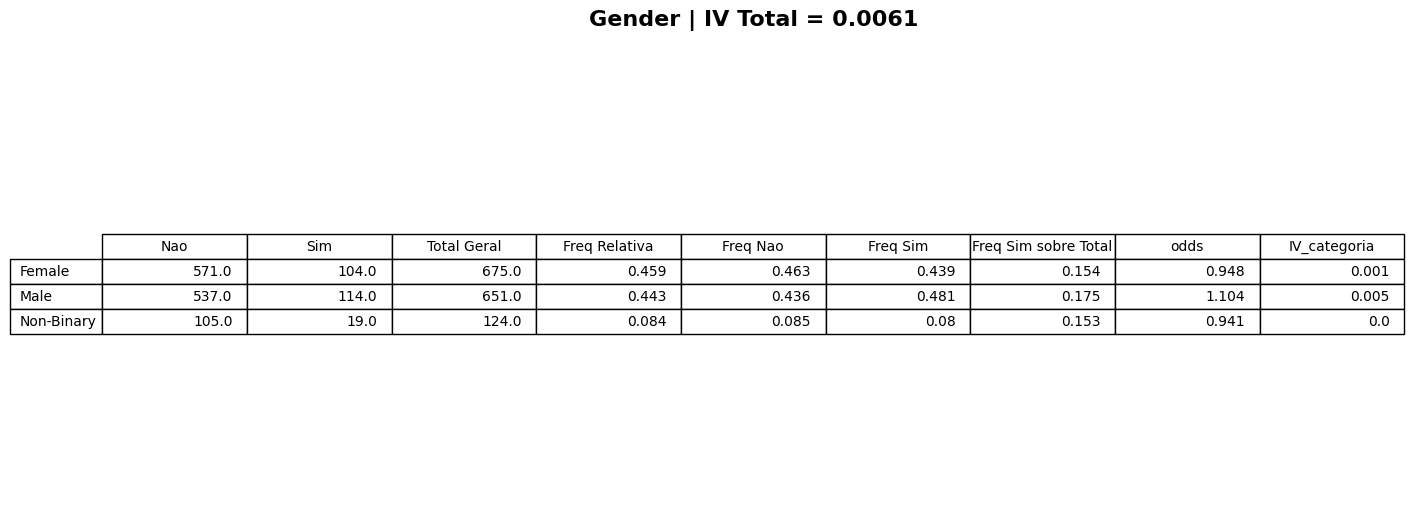

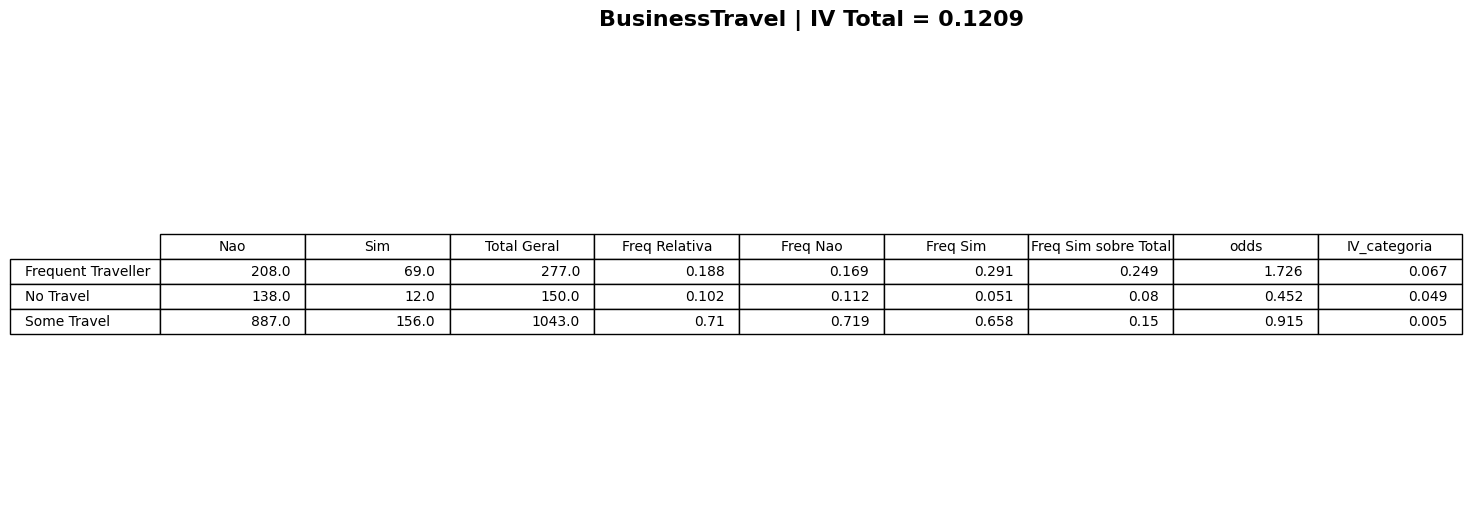

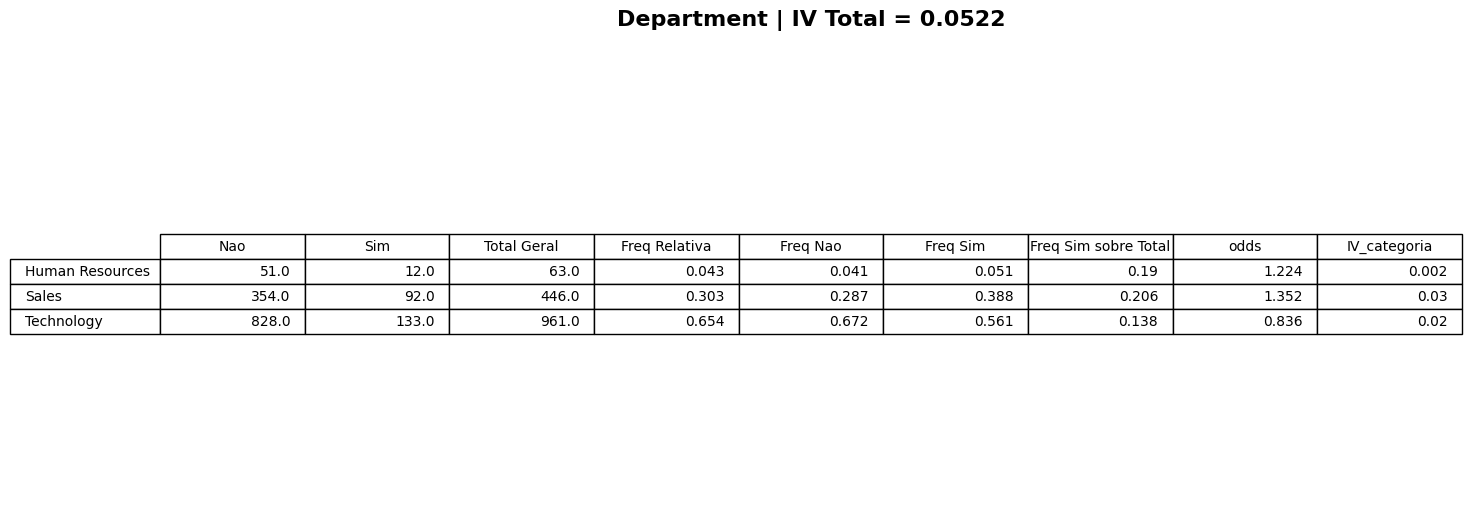

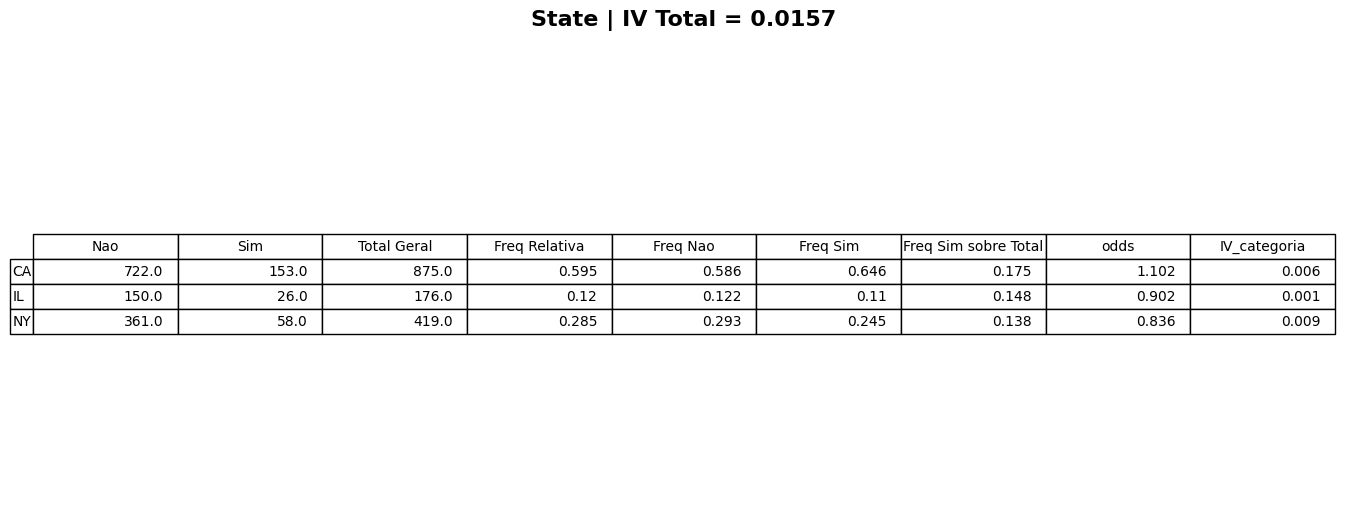

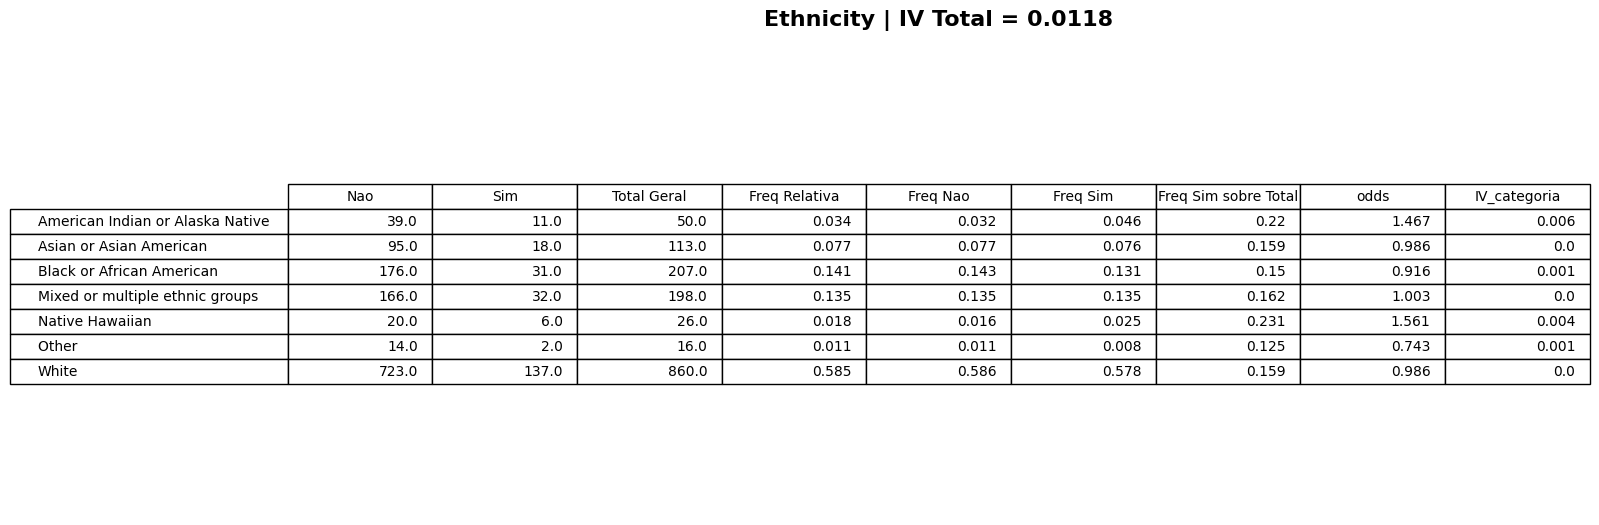

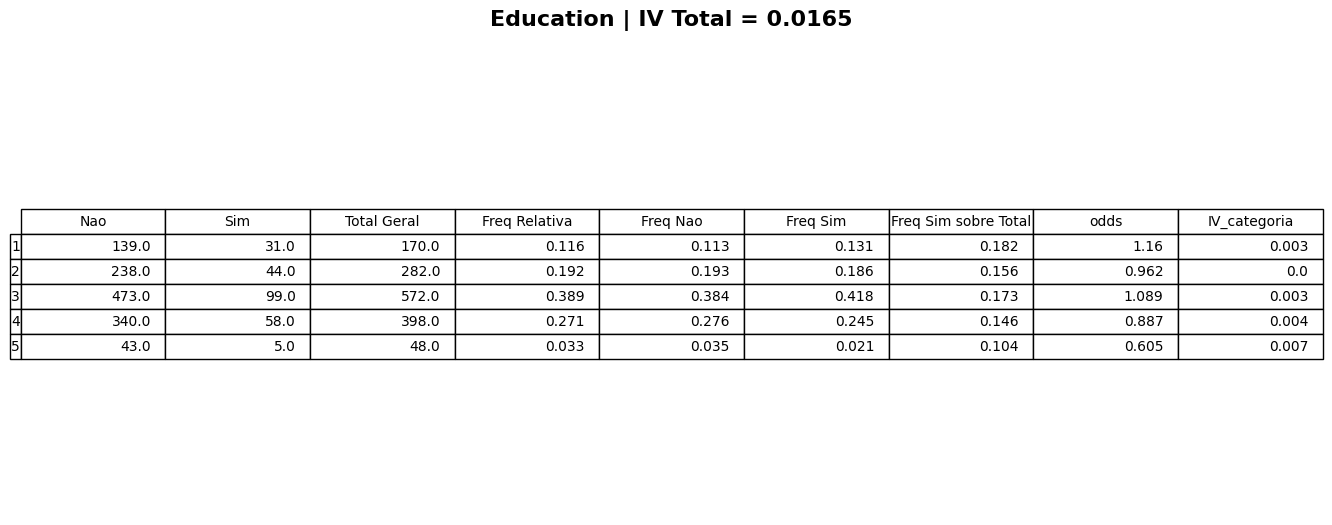

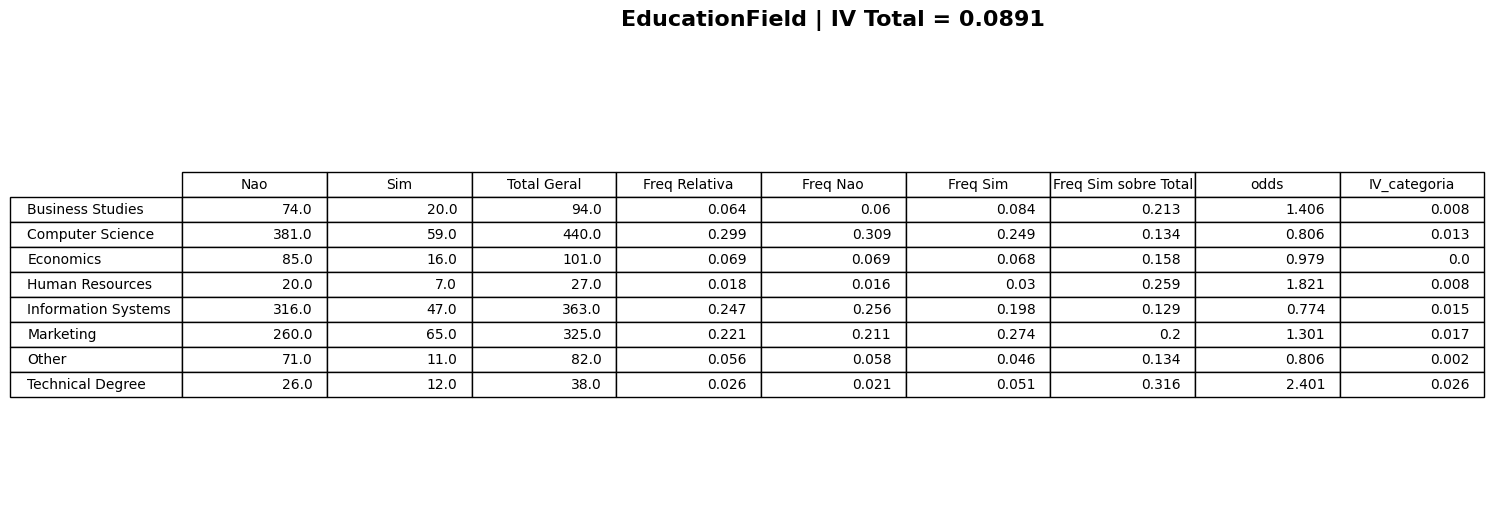

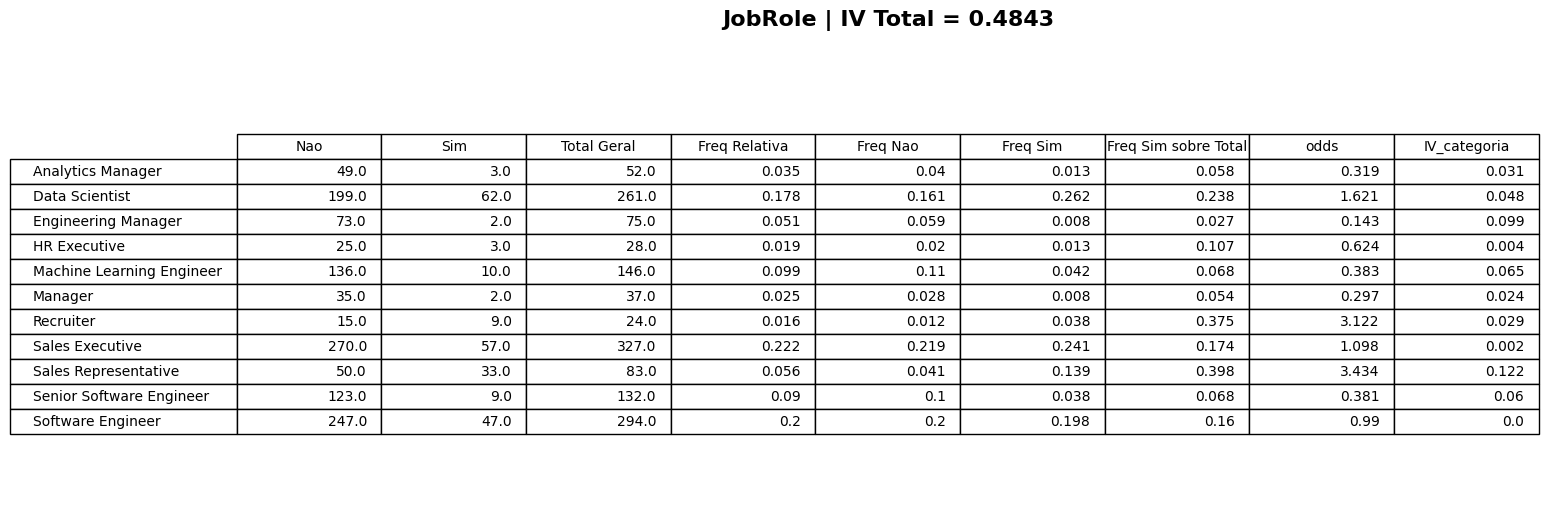

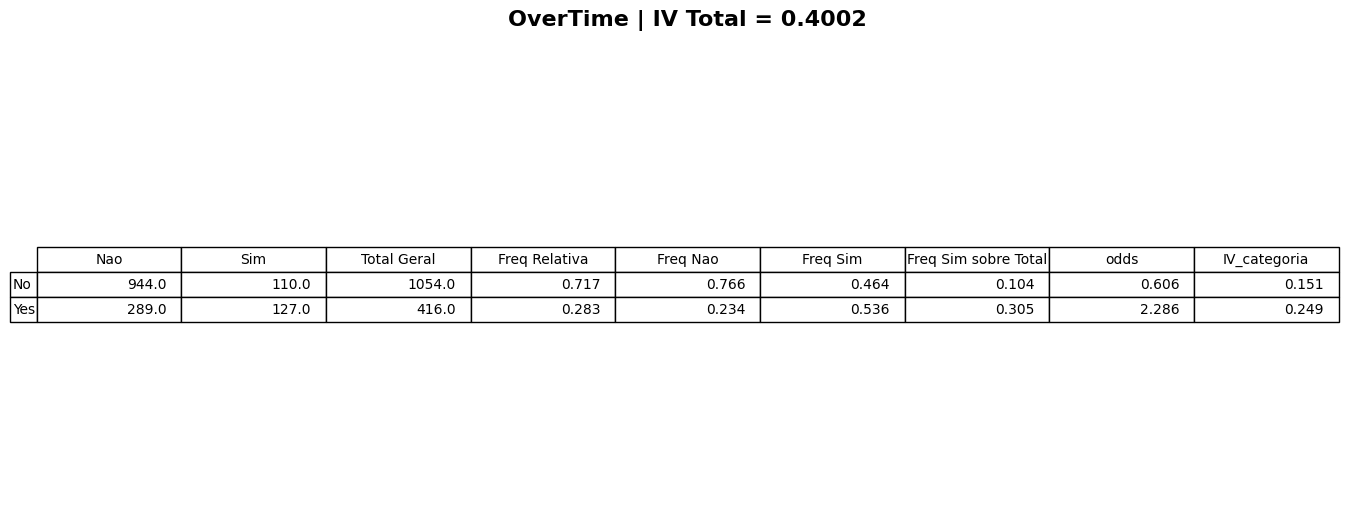

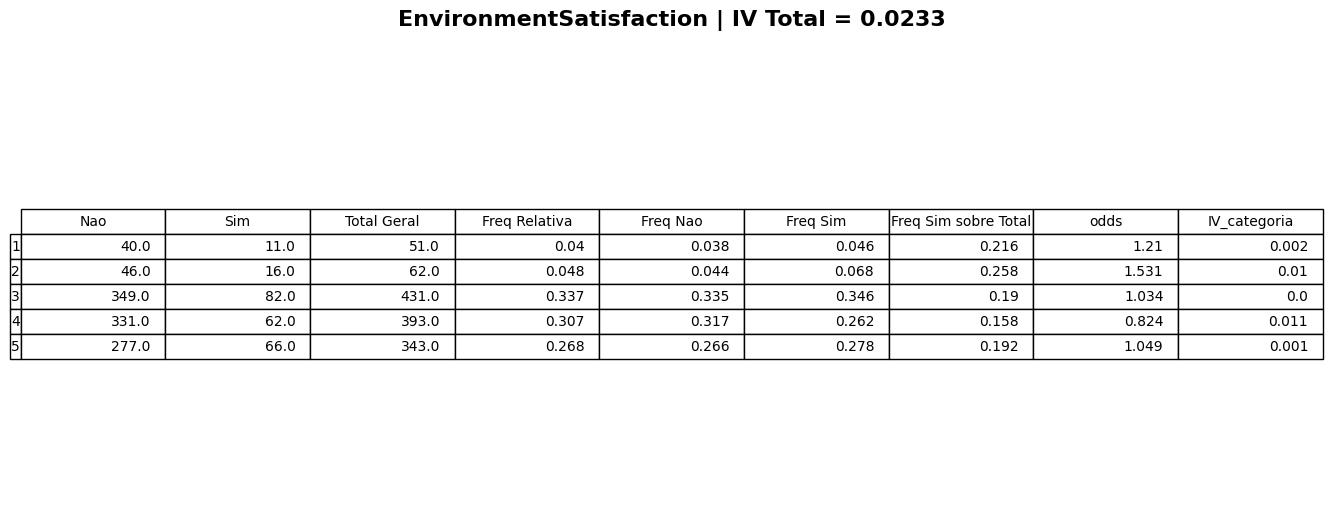

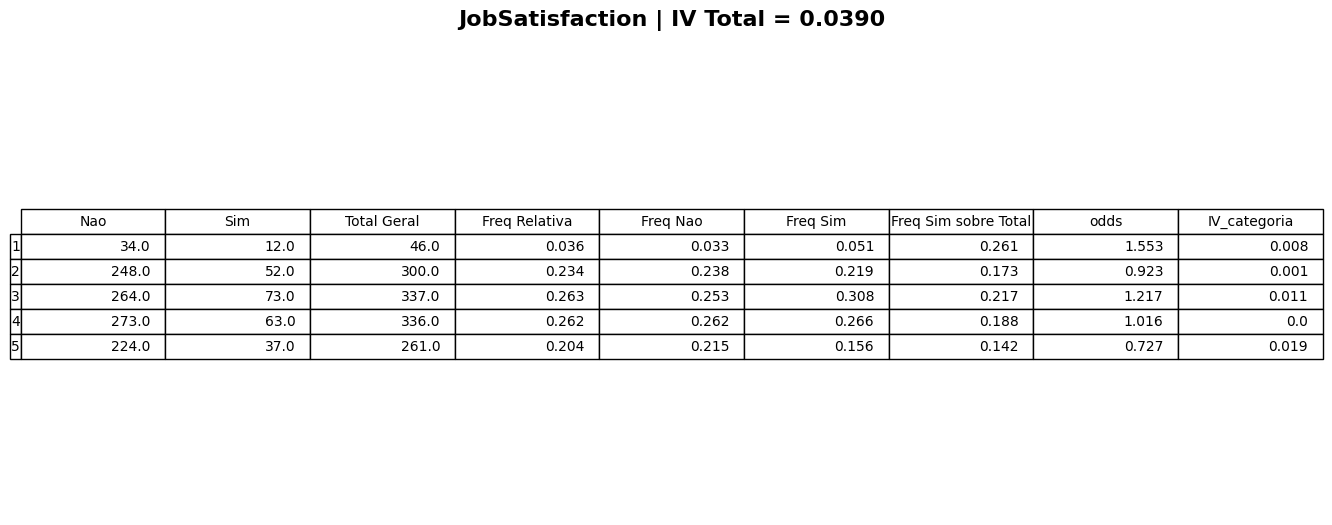

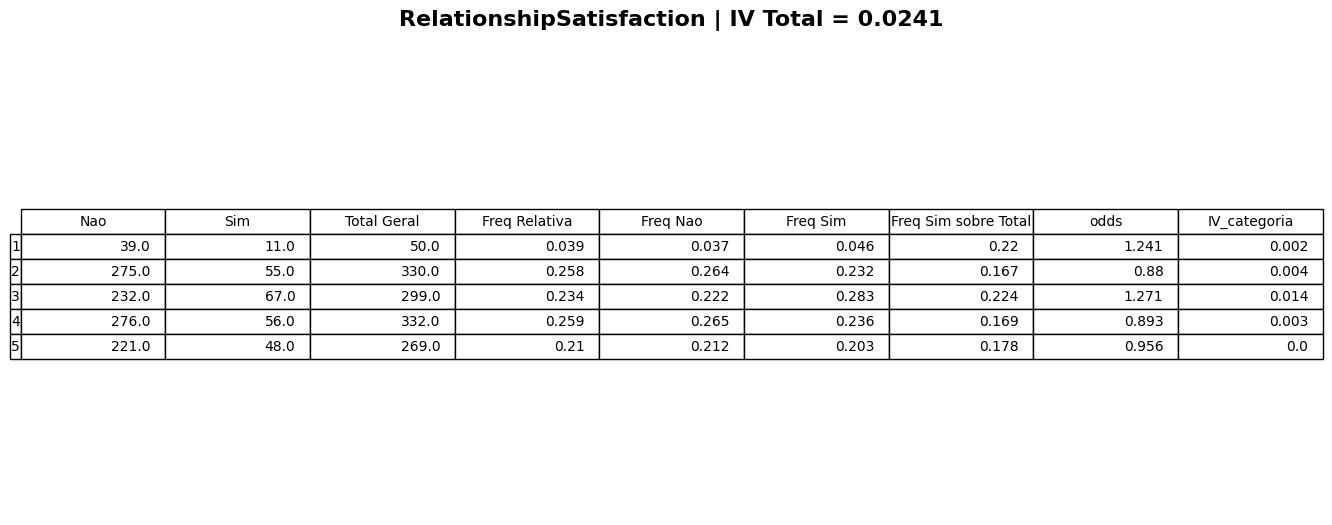

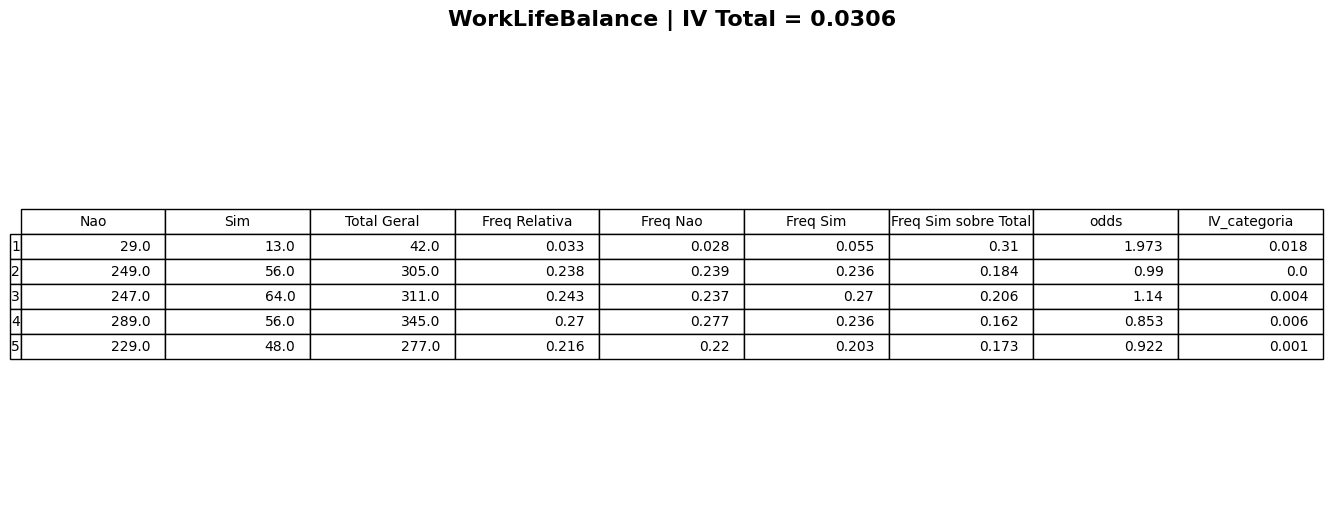

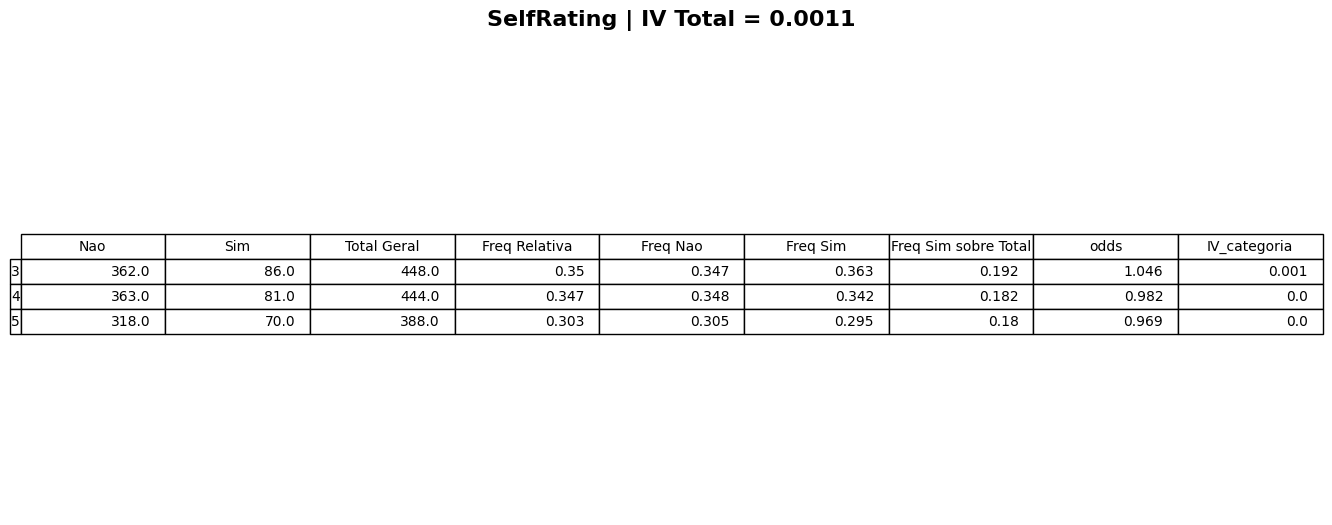

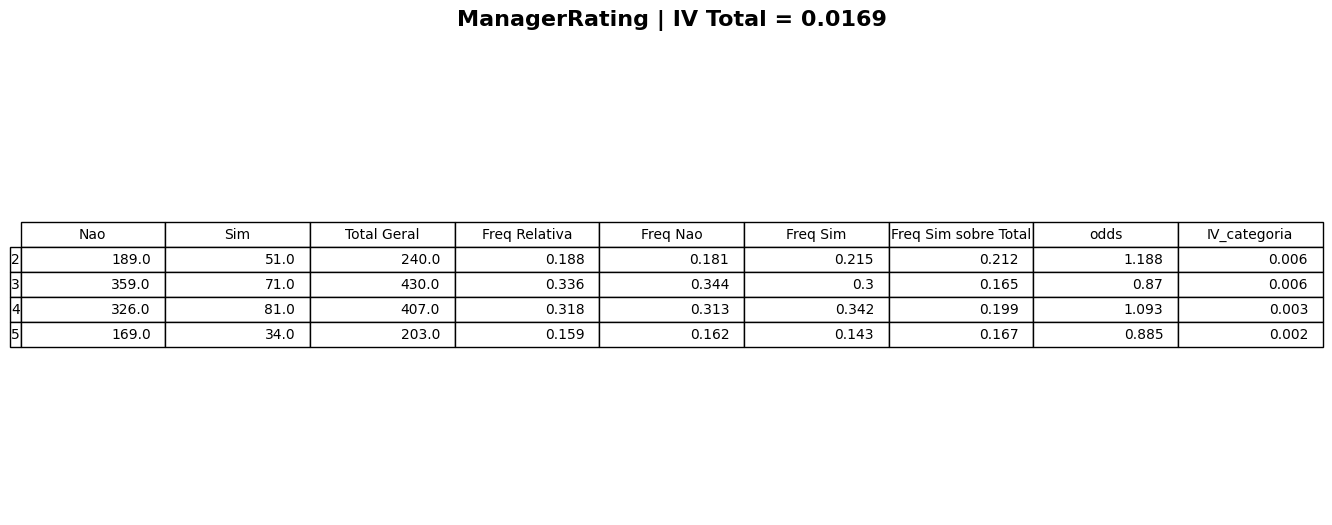

In [32]:
df = employee_review

target = 'Attrition'

quali = [
    'Gender',
    'BusinessTravel',
    'Department',
    'State',
    'Ethnicity',
    'Education',
    'EducationField',
    'JobRole',
    'OverTime',
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance',
    'SelfRating',
    'ManagerRating'
]

for coluna in quali:

    tabela = pd.crosstab(
        df[coluna],
        df[target]
    )

    tabela.columns = ['Nao', 'Sim']

    tabela['Total Geral'] = tabela['Nao'] + tabela['Sim']

    tabela['Freq Relativa'] = (
        tabela['Total Geral'] /
        tabela['Total Geral'].sum()
    )

    tabela['Freq Nao'] = (
        tabela['Nao'] /
        tabela['Nao'].sum()
    )

    tabela['Freq Sim'] = (
        tabela['Sim'] /
        tabela['Sim'].sum()
    )

    tabela['Freq Sim sobre Total'] = (
        tabela['Sim'] /
        tabela['Total Geral']
    )

    # Desconsidera categorias sem ocorrência de Nao ou Sim
    tabela = tabela[
        (tabela['Freq Nao'] > 0) &
        (tabela['Freq Sim'] > 0)
    ].copy()

    tabela['odds'] = (
        tabela['Freq Sim'] /
        tabela['Freq Nao']
    )

    tabela['IV_categoria'] = (
        (tabela['Freq Sim'] - tabela['Freq Nao']) *
        np.log(tabela['odds'])
    )

    iv_total = tabela['IV_categoria'].sum()

    tabela = tabela.round(3)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axis('off')

    ax.set_title(
        f'{coluna} | IV Total = {iv_total:.4f}',
        fontsize=16,
        fontweight='bold',
        pad=20
    )

    tabela_plot = ax.table(
        cellText=tabela.values,
        colLabels=tabela.columns,
        rowLabels=tabela.index,
        loc='center'
    )

    tabela_plot.auto_set_font_size(False)
    tabela_plot.set_fontsize(10)
    tabela_plot.scale(1.2, 1.5)

    plt.show()
    plt.close()

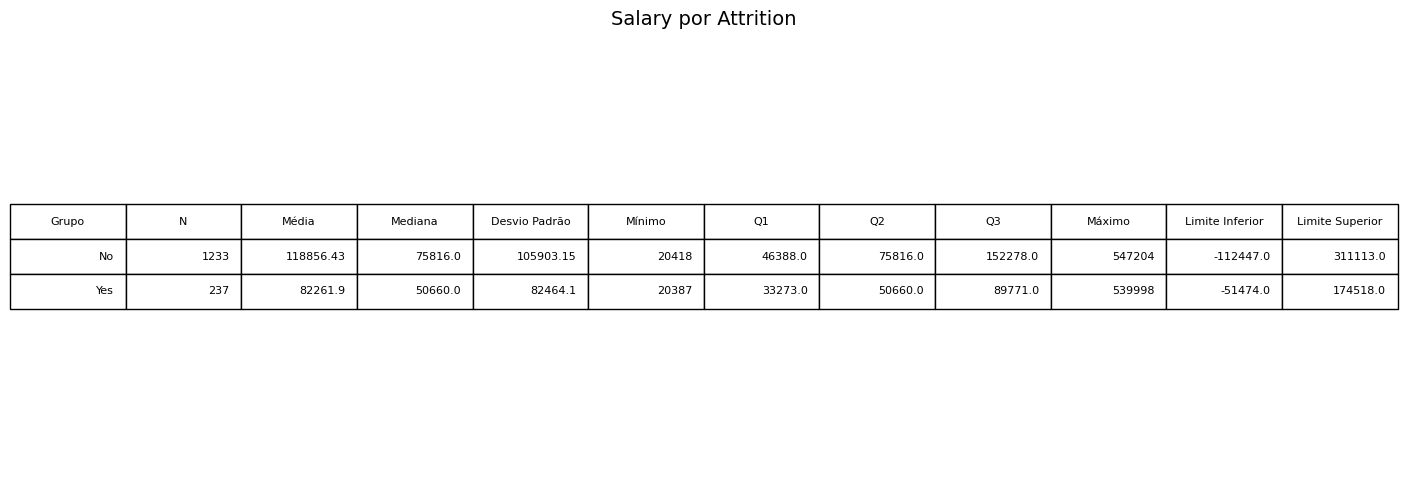

In [41]:
df = employee_review

# variável quantitativa
quanti = 'Salary'

# variáveis qualitativas
quali = [
    'Attrition'
]


for coluna_quali in quali:

    resultados = []

    for grupo in df[coluna_quali].dropna().unique():

        df_filtrado = df[df[coluna_quali] == grupo]

        resumo = eda_quanti(df_filtrado, quanti)

        resumo['Grupo'] = grupo

        resumo['N'] = len(df_filtrado)

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'N',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.sort_values(
        'Média',
        ascending=False
    )

    tabela_final = tabela_final.round(2)


    fig, ax = plt.subplots(figsize=(14, 5))

    ax.axis('off')

    plt.title(
        f'{quanti} por {coluna_quali}',
        fontsize=14
    )

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.scale(1.1, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()



In [34]:
print(employee_review.columns)

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceID', 'ReviewDate',
       'EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating'],
      dtype='object')


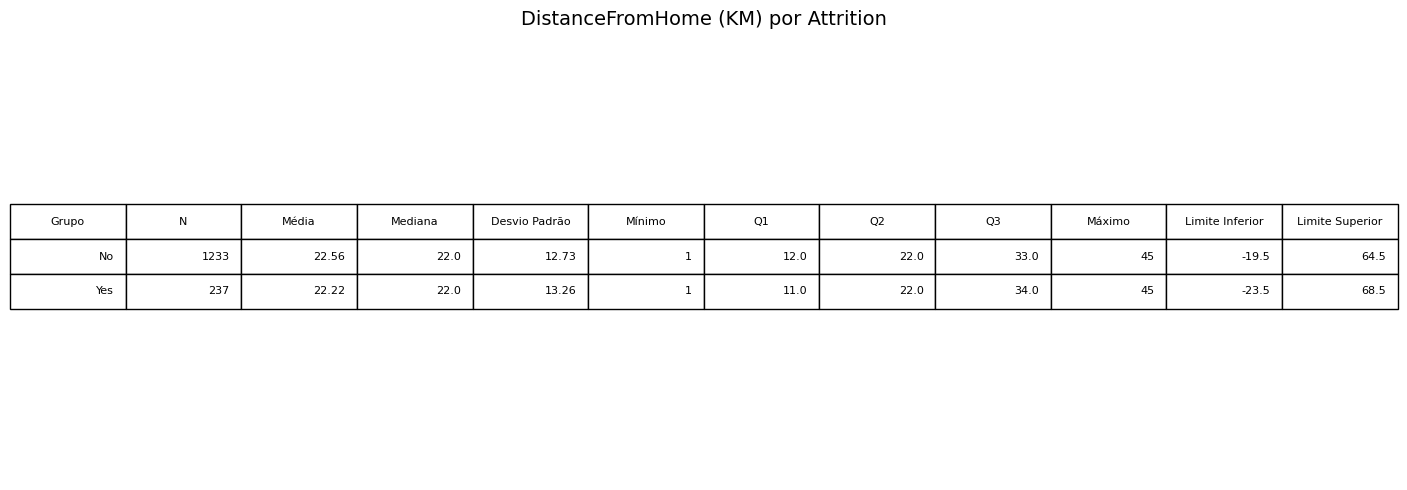

In [35]:
df = employee_review

# variável quantitativa
quanti = 'DistanceFromHome (KM)'

# variáveis qualitativas
quali = [
    'Attrition'
]

for coluna_quali in quali:

    resultados = []

    for grupo in df[coluna_quali].dropna().unique():

        df_filtrado = df[df[coluna_quali] == grupo]

        resumo = eda_quanti(df_filtrado, quanti)

        resumo['Grupo'] = grupo

        resumo['N'] = len(df_filtrado)

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'N',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.sort_values(
        'Média',
        ascending=False
    )

    tabela_final = tabela_final.round(2)


    fig, ax = plt.subplots(figsize=(14, 5))

    ax.axis('off')

    plt.title(
        f'{quanti} por {coluna_quali}',
        fontsize=14
    )

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.scale(1.1, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()


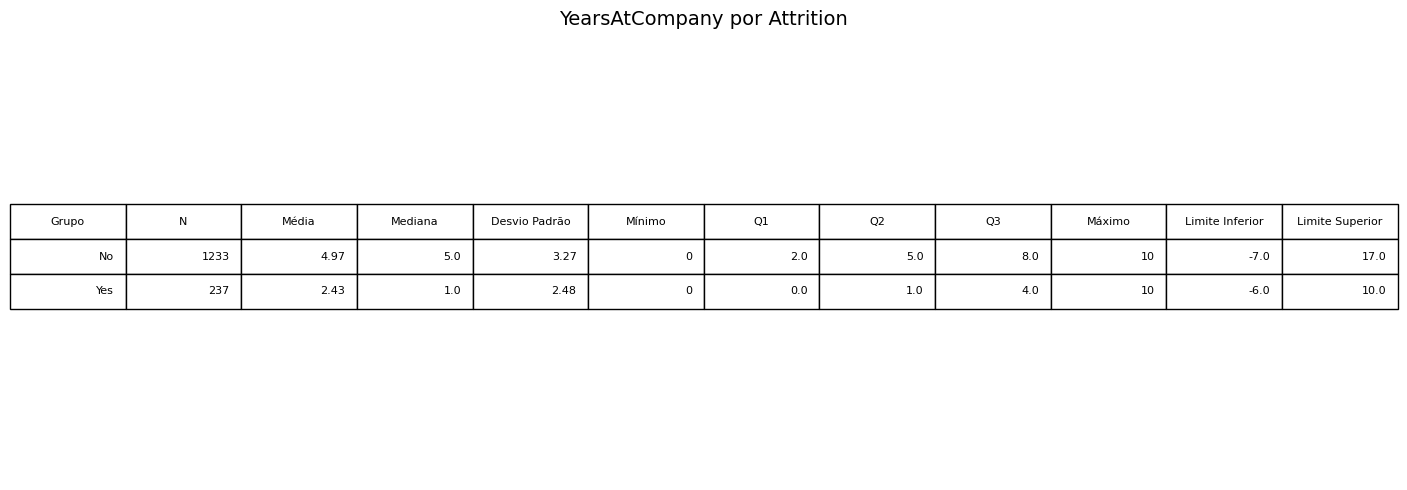

In [36]:
df = employee_review

# variável quantitativa
quanti = 'YearsAtCompany'

# variáveis qualitativas
quali = [
    'Attrition'
]

for coluna_quali in quali:

    resultados = []

    for grupo in df[coluna_quali].dropna().unique():

        df_filtrado = df[df[coluna_quali] == grupo]

        resumo = eda_quanti(df_filtrado, quanti)

        resumo['Grupo'] = grupo

        resumo['N'] = len(df_filtrado)

        resultados.append(resumo)

    tabela_final = pd.DataFrame(resultados)

    tabela_final = tabela_final[
        [
            'Grupo',
            'N',
            'Média',
            'Mediana',
            'Desvio Padrão',
            'Mínimo',
            'Q1',
            'Q2',
            'Q3',
            'Máximo',
            'Limite Inferior',
            'Limite Superior'
        ]
    ]

    tabela_final = tabela_final.sort_values(
        'Média',
        ascending=False
    )

    tabela_final = tabela_final.round(2)


    fig, ax = plt.subplots(figsize=(14, 5))

    ax.axis('off')

    plt.title(
        f'{quanti} por {coluna_quali}',
        fontsize=14
    )

    tabela = ax.table(
        cellText=tabela_final.values,
        colLabels=tabela_final.columns,
        loc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.scale(1.1, 1.8)

    plt.tight_layout()

    plt.show()

    plt.close()

In [37]:
df = employee_review

df['Salary_Faixa'] = pd.qcut(df['Salary'], 5)

taxa_attrition = (
    df.groupby('Salary_Faixa', observed=True)['Attrition']
      .value_counts(normalize=True)
      .unstack()
)

print(taxa_attrition)

Attrition                   No       Yes
Salary_Faixa                            
(20386.999, 38724.2]  0.717687  0.282313
(38724.2, 58382.8]    0.826531  0.173469
(58382.8, 90907.2]    0.846939  0.153061
(90907.2, 178544.8]   0.891156  0.108844
(178544.8, 547204.0]  0.911565  0.088435
